In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# =========================================================
# STAGE 1
# OPTION B: TRAIN 5 SEPARATE MODELS FOR C, UL, UR, LR, LL
# Same input: 5 ROI patches + square context + 37 features
# Different target each run
# =========================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------
MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37.csv")
OUT_DIR = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage1_predict_all5_separate")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

BATCH_SIZE = 8
NUM_EPOCHS = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4
TEST_SIZE = 0.2

ROI_IMG_SIZE = 96
SQUARE_IMG_SIZE = 160

ROI_ORDER = ["C", "UL", "UR", "LR", "LL"]
ROI_SIZES = {
    "C": 256,
    "UL": 128,
    "UR": 128,
    "LR": 128,
    "LL": 128,
}

ROI_COORDS = {
    "C":  (1520, 2027),
    "UL": (1020, 1372),
    "UR": (2043, 1372),
    "LR": (2030, 2722),
    "LL": (1020, 2722),
}

GROUP_COL = "session"

TARGET_MAP = {
    "C":  "lux_C",
    "UL": "lux_UL",
    "UR": "lux_UR",
    "LR": "lux_LR",
    "LL": "lux_LL",
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------
# LOAD MASTER
# ---------------------------------------------------------
df_master = pd.read_csv(MASTER_PATH)
print("Loaded master rows:", len(df_master))
print("Loaded master cols:", len(df_master.columns))

# add fixed coordinates if missing
for roi, (x, y) in ROI_COORDS.items():
    if f"x_{roi}" not in df_master.columns:
        df_master[f"x_{roi}"] = x
    if f"y_{roi}" not in df_master.columns:
        df_master[f"y_{roi}"] = y

# ---------------------------------------------------------
# TABULAR FEATURES (37)
# ---------------------------------------------------------
TABULAR_FEATURE_COLS = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std",
    "UL_mean_luma", "UR_mean_luma", "LR_mean_luma", "LL_mean_luma",
    "UL_grad_mean", "UR_grad_mean", "LR_grad_mean", "LL_grad_mean",
    "corner_mean_luma", "corner_std_luma", "corner_range_luma",
    "C_minus_corner_mean_luma", "C_over_corner_mean_luma",
    "C_minus_UL_luma", "C_minus_UR_luma", "C_minus_LR_luma", "C_minus_LL_luma",
    "square_mean_luma", "square_std_luma", "square_grad_mean", "square_grad_std",
    "square_mean_sat_proxy",
    "square_top_mean_luma", "square_bottom_mean_luma",
    "square_left_mean_luma", "square_right_mean_luma",
    "square_center_cell_mean_luma", "square_corner_cells_mean_luma",
    "square_bottom_minus_top_luma", "square_right_minus_left_luma",
    "square_center_minus_corners_luma",
    "square_grid_range_mean_luma", "square_grid_std_mean_luma",
]

available_tabular_feature_cols = [c for c in TABULAR_FEATURE_COLS if c in df_master.columns]
missing_tabular_feature_cols = [c for c in TABULAR_FEATURE_COLS if c not in df_master.columns]

print("\nAvailable tabular features:", len(available_tabular_feature_cols))
print("Missing tabular features:", len(missing_tabular_feature_cols))
if missing_tabular_feature_cols:
    print(missing_tabular_feature_cols)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def crop_patch(img, x, y, crop_size):
    half = crop_size // 2
    left = int(round(x - half))
    top = int(round(y - half))
    right = left + crop_size
    bottom = top + crop_size

    pad_left = max(0, -left)
    pad_top = max(0, -top)
    pad_right = max(0, right - img.width)
    pad_bottom = max(0, bottom - img.height)

    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(
            arr,
            ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
            mode="edge"
        )
        img = Image.fromarray(arr)
        left += pad_left
        right += pad_left
        top += pad_top
        bottom += pad_top

    return img.crop((left, top, right, bottom))

def crop_bbox(img, left, top, right, bottom):
    pad_left = max(0, -left)
    pad_top = max(0, -top)
    pad_right = max(0, right - img.width)
    pad_bottom = max(0, bottom - img.height)

    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(
            arr,
            ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
            mode="edge"
        )
        img = Image.fromarray(arr)
        left += pad_left
        right += pad_left
        top += pad_top
        bottom += pad_top

    return img.crop((left, top, right, bottom))

def get_square_bbox_from_row(row):
    lefts, rights, tops, bottoms = [], [], [], []
    for roi in ["UL", "UR", "LR", "LL"]:
        x = int(row[f"x_{roi}"])
        y = int(row[f"y_{roi}"])
        r = ROI_SIZES[roi] // 2
        lefts.append(x - r)
        rights.append(x + r)
        tops.append(y - r)
        bottoms.append(y + r)
    return int(min(lefts)), int(min(tops)), int(max(rights)), int(max(bottoms))

def pil_to_tensor(img):
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.transpose(arr, (2, 0, 1))
    return torch.tensor(arr, dtype=torch.float32)

def resize_pil(img, size):
    return img.resize((size, size))

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0)
    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "MAPE": float(mape),
    }

# ---------------------------------------------------------
# DATASET
# ---------------------------------------------------------
class HybridSquareROI5Dataset(Dataset):
    def __init__(self, df, tabular_cols, target_col, roi_order, roi_sizes,
                 roi_img_size=96, square_img_size=160):
        self.df = df.reset_index(drop=True)
        self.tabular_cols = tabular_cols
        self.target_col = target_col
        self.roi_order = roi_order
        self.roi_sizes = roi_sizes
        self.roi_img_size = roi_img_size
        self.square_img_size = square_img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"])
        img = ImageOps.exif_transpose(img).convert("RGB")

        roi_tensors = []
        for roi in self.roi_order:
            x = int(row[f"x_{roi}"])
            y = int(row[f"y_{roi}"])
            crop_size = int(self.roi_sizes[roi])
            patch = crop_patch(img, x, y, crop_size)
            patch = resize_pil(patch, self.roi_img_size)
            roi_tensors.append(pil_to_tensor(patch))

        roi_stack = torch.stack(roi_tensors, dim=0)

        left, top, right, bottom = get_square_bbox_from_row(row)
        square_patch = crop_bbox(img, left, top, right, bottom)
        square_patch = resize_pil(square_patch, self.square_img_size)
        square_tensor = pil_to_tensor(square_patch)

        tab = torch.tensor(row[self.tabular_cols].values.astype(np.float32), dtype=torch.float32)
        y = torch.tensor(float(row[self.target_col]), dtype=torch.float32)

        return {
            "roi_imgs": roi_stack,
            "square_img": square_tensor,
            "tabular": tab,
            "target": y,
            "image_path": row["image_path"],
            "filename": row["filename"],
        }

# ---------------------------------------------------------
# MODEL
# ---------------------------------------------------------
class ROIEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.fc(x)

class SquareEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.fc(x)

class TabularMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

class HybridOptionBModel(nn.Module):
    def __init__(self, n_tabular_features, roi_embed_dim=128, square_embed_dim=128, tab_embed_dim=64):
        super().__init__()
        self.roi_encoder = ROIEncoder(out_dim=roi_embed_dim)
        self.square_encoder = SquareEncoder(out_dim=square_embed_dim)
        self.tab_branch = TabularMLP(n_tabular_features, hidden_dim=128, out_dim=tab_embed_dim)

        fusion_dim = 5 * roi_embed_dim + square_embed_dim + tab_embed_dim

        self.head = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, roi_imgs, square_img, tabular):
        B, N, C, H, W = roi_imgs.shape
        roi_imgs = roi_imgs.view(B * N, C, H, W)
        roi_emb = self.roi_encoder(roi_imgs)
        roi_emb = roi_emb.view(B, N, -1).flatten(1)

        square_emb = self.square_encoder(square_img)
        tab_emb = self.tab_branch(tabular)

        fused = torch.cat([roi_emb, square_emb, tab_emb], dim=1)
        return self.head(fused).squeeze(1)

# ---------------------------------------------------------
# TRAIN / EVAL FOR ONE TARGET
# ---------------------------------------------------------
def train_and_eval_option_b_for_target(train_df, test_df, run_name, target_col, out_dir):
    run_dir = Path(out_dir) / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    usable_cols = [c for c in available_tabular_feature_cols if c in train_df.columns and c in test_df.columns]
    print(f"{run_name} | usable tabular features: {len(usable_cols)}")

    scaler = StandardScaler()
    X_train_tab = scaler.fit_transform(train_df[usable_cols].values)
    X_test_tab = scaler.transform(test_df[usable_cols].values)

    train_df_scaled = train_df.copy()
    test_df_scaled = test_df.copy()

    for i, col in enumerate(usable_cols):
        train_df_scaled[col] = X_train_tab[:, i]
        test_df_scaled[col] = X_test_tab[:, i]

    train_ds = HybridSquareROI5Dataset(
        train_df_scaled, usable_cols, target_col, ROI_ORDER, ROI_SIZES,
        roi_img_size=ROI_IMG_SIZE, square_img_size=SQUARE_IMG_SIZE
    )
    test_ds = HybridSquareROI5Dataset(
        test_df_scaled, usable_cols, target_col, ROI_ORDER, ROI_SIZES,
        roi_img_size=ROI_IMG_SIZE, square_img_size=SQUARE_IMG_SIZE
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(DEVICE == "cuda"))
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE == "cuda"))

    model = HybridOptionBModel(n_tabular_features=len(usable_cols)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.MSELoss()

    history = []
    best_mae = float("inf")
    best_state = None

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        train_losses = []

        for batch in train_loader:
            roi_imgs = batch["roi_imgs"].to(DEVICE)
            square_img = batch["square_img"].to(DEVICE)
            tabular = batch["tabular"].to(DEVICE)
            target = batch["target"].to(DEVICE)

            optimizer.zero_grad()
            pred = model(roi_imgs, square_img, tabular)
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        y_true = []
        y_pred = []

        with torch.no_grad():
            for batch in test_loader:
                roi_imgs = batch["roi_imgs"].to(DEVICE)
                square_img = batch["square_img"].to(DEVICE)
                tabular = batch["tabular"].to(DEVICE)
                target = batch["target"].cpu().numpy()
                pred = model(roi_imgs, square_img, tabular).cpu().numpy()

                y_true.extend(target.tolist())
                y_pred.extend(pred.tolist())

        metrics = evaluate_regression(np.array(y_true), np.array(y_pred))
        row = {"epoch": epoch, "train_loss": float(np.mean(train_losses)), **metrics}
        history.append(row)

        print(
            f"{run_name} | epoch {epoch:02d} | "
            f"loss={row['train_loss']:.4f} | "
            f"MAE={row['MAE']:.3f} | RMSE={row['RMSE']:.3f} | "
            f"R2={row['R2']:.4f} | MAPE={row['MAPE']:.3f}"
        )

        if row["MAE"] < best_mae:
            best_mae = row["MAE"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    history_df = pd.DataFrame(history)
    history_df.to_csv(run_dir / "training_history.csv", index=False)

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    final_rows = []

    with torch.no_grad():
        for batch in test_loader:
            roi_imgs = batch["roi_imgs"].to(DEVICE)
            square_img = batch["square_img"].to(DEVICE)
            tabular = batch["tabular"].to(DEVICE)

            preds = model(roi_imgs, square_img, tabular).cpu().numpy()

            for i in range(len(preds)):
                true_val = float(batch["target"][i].item())
                pred_val = float(preds[i])
                final_rows.append({
                    "image_path": batch["image_path"][i],
                    "filename": batch["filename"][i],
                    "target_lux": true_val,
                    "pred": pred_val,
                    "abs_err": abs(pred_val - true_val),
                    "pct_err": abs(pred_val - true_val) / max(abs(true_val), 1e-8) * 100.0,
                })

    pred_df = pd.DataFrame(final_rows)
    pred_df.to_csv(run_dir / "test_predictions.csv", index=False)

    final_metrics = evaluate_regression(pred_df["target_lux"].values, pred_df["pred"].values)
    metrics_df = pd.DataFrame([{
        "model": "Hybrid_OptionB_SeparateTargets",
        "target_roi": run_name.split("__")[-1],
        "target_col": target_col,
        "train_n": len(train_df),
        "test_n": len(test_df),
        "n_tabular_features": len(usable_cols),
        **final_metrics
    }])
    metrics_df.to_csv(run_dir / "final_metrics.csv", index=False)

    return {
        "target_roi": run_name.split("__")[-1],
        "target_col": target_col,
        "train_n": len(train_df),
        "test_n": len(test_df),
        "n_tabular_features": len(usable_cols),
        **final_metrics
    }

# ---------------------------------------------------------
# STANDARD GROUP SPLIT ON MAIN TRANSFER SURFACES
# ---------------------------------------------------------
# Restrict to white_paper + table for a cleaner first test
df_stage1 = df_master[df_master["surface_group_norm"].isin(["white_paper", "table"])].copy()

# Drop rows missing any target lux
required_targets = list(TARGET_MAP.values())
df_stage1 = df_stage1.dropna(subset=required_targets).reset_index(drop=True)

print("\nStage 1 dataframe rows:", len(df_stage1))
print(df_stage1["surface_group_norm"].value_counts(dropna=False))

X_dummy = np.zeros((len(df_stage1), 1))
y_dummy = df_stage1["lux_C"].values
groups = df_stage1[GROUP_COL].astype(str).values

splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(splitter.split(X_dummy, y_dummy, groups=groups))

train_df = df_stage1.iloc[train_idx].reset_index(drop=True)
test_df = df_stage1.iloc[test_idx].reset_index(drop=True)

print("\nTrain rows:", len(train_df))
print("Test rows:", len(test_df))

# ---------------------------------------------------------
# RUN 5 TARGETS
# ---------------------------------------------------------
results = []

for roi_name, target_col in TARGET_MAP.items():
    print("\n" + "=" * 95)
    print(f"RUNNING TARGET {roi_name} -> {target_col}")

    run_name = f"optionB_stage1_standard_split__{roi_name}"

    res = train_and_eval_option_b_for_target(
        train_df=train_df,
        test_df=test_df,
        run_name=run_name,
        target_col=target_col,
        out_dir=OUT_DIR
    )
    results.append(res)

# ---------------------------------------------------------
# SAVE SUMMARY
# ---------------------------------------------------------
results_df = pd.DataFrame(results)
results_csv = OUT_DIR / "stage1_separate_target_summary.csv"
results_df.to_csv(results_csv, index=False)

print("\nSaved summary to:", results_csv)
display(results_df.sort_values("MAE"))

Loaded master rows: 3135
Loaded master cols: 269

Available tabular features: 37
Missing tabular features: 0

Stage 1 dataframe rows: 1357
surface_group_norm
white_paper    708
table          649
Name: count, dtype: int64

Train rows: 1083
Test rows: 274

RUNNING TARGET C -> lux_C
optionB_stage1_standard_split__C | usable tabular features: 37
optionB_stage1_standard_split__C | epoch 01 | loss=140009.6200 | MAE=143.384 | RMSE=208.001 | R2=0.6826 | MAPE=23.104
optionB_stage1_standard_split__C | epoch 02 | loss=29860.2781 | MAE=119.847 | RMSE=172.099 | R2=0.7827 | MAPE=20.829
optionB_stage1_standard_split__C | epoch 03 | loss=23616.4254 | MAE=114.564 | RMSE=160.282 | R2=0.8116 | MAPE=24.260
optionB_stage1_standard_split__C | epoch 04 | loss=22094.1914 | MAE=127.853 | RMSE=175.929 | R2=0.7730 | MAPE=19.969
optionB_stage1_standard_split__C | epoch 05 | loss=21240.3689 | MAE=97.496 | RMSE=144.768 | R2=0.8463 | MAPE=16.913
optionB_stage1_standard_split__C | epoch 06 | loss=17611.2622 | MAE=95

,target_roi,target_col,train_n,test_n,n_tabular_features,MAE,RMSE,R2,MAPE
3,LR,lux_LR,1083,274,37,63.093036,92.137565,0.918194,14.081815
1,UL,lux_UL,1083,274,37,65.363660,96.825838,0.926059,11.783719
2,UR,lux_UR,1083,274,37,67.332914,100.391213,0.885432,12.477207
4,LL,lux_LL,1083,274,37,67.359205,121.933404,0.893116,11.231313
0,C,lux_C,1083,274,37,70.478067,103.781301,0.920997,11.875113


In [ ]:
# =========================================================
# STAGE 2
# OPTION B MULTI-OUTPUT MODEL
# Predict all 5 points at once: C, UL, UR, LR, LL
# =========================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------
MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37.csv")
OUT_DIR = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

BATCH_SIZE = 8
NUM_EPOCHS = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4
TEST_SIZE = 0.2

ROI_IMG_SIZE = 96
SQUARE_IMG_SIZE = 160

ROI_ORDER = ["C", "UL", "UR", "LR", "LL"]
ROI_SIZES = {
    "C": 256,
    "UL": 128,
    "UR": 128,
    "LR": 128,
    "LL": 128,
}

ROI_COORDS = {
    "C":  (1520, 2027),
    "UL": (1020, 1372),
    "UR": (2043, 1372),
    "LR": (2030, 2722),
    "LL": (1020, 2722),
}

GROUP_COL = "session"
TARGET_COLS = ["lux_C", "lux_UL", "lux_UR", "lux_LR", "lux_LL"]
TARGET_NAMES = ["C", "UL", "UR", "LR", "LL"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------
# LOAD MASTER
# ---------------------------------------------------------
df_master = pd.read_csv(MASTER_PATH)
print("Loaded master rows:", len(df_master))
print("Loaded master cols:", len(df_master.columns))

# add fixed coordinates if missing
for roi, (x, y) in ROI_COORDS.items():
    if f"x_{roi}" not in df_master.columns:
        df_master[f"x_{roi}"] = x
    if f"y_{roi}" not in df_master.columns:
        df_master[f"y_{roi}"] = y

# ---------------------------------------------------------
# TABULAR FEATURES (37)
# ---------------------------------------------------------
TABULAR_FEATURE_COLS = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std",
    "UL_mean_luma", "UR_mean_luma", "LR_mean_luma", "LL_mean_luma",
    "UL_grad_mean", "UR_grad_mean", "LR_grad_mean", "LL_grad_mean",
    "corner_mean_luma", "corner_std_luma", "corner_range_luma",
    "C_minus_corner_mean_luma", "C_over_corner_mean_luma",
    "C_minus_UL_luma", "C_minus_UR_luma", "C_minus_LR_luma", "C_minus_LL_luma",
    "square_mean_luma", "square_std_luma", "square_grad_mean", "square_grad_std",
    "square_mean_sat_proxy",
    "square_top_mean_luma", "square_bottom_mean_luma",
    "square_left_mean_luma", "square_right_mean_luma",
    "square_center_cell_mean_luma", "square_corner_cells_mean_luma",
    "square_bottom_minus_top_luma", "square_right_minus_left_luma",
    "square_center_minus_corners_luma",
    "square_grid_range_mean_luma", "square_grid_std_mean_luma",
]

available_tabular_feature_cols = [c for c in TABULAR_FEATURE_COLS if c in df_master.columns]
missing_tabular_feature_cols = [c for c in TABULAR_FEATURE_COLS if c not in df_master.columns]

print("\nAvailable tabular features:", len(available_tabular_feature_cols))
print("Missing tabular features:", len(missing_tabular_feature_cols))
if missing_tabular_feature_cols:
    print(missing_tabular_feature_cols)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def crop_patch(img, x, y, crop_size):
    half = crop_size // 2
    left = int(round(x - half))
    top = int(round(y - half))
    right = left + crop_size
    bottom = top + crop_size

    pad_left = max(0, -left)
    pad_top = max(0, -top)
    pad_right = max(0, right - img.width)
    pad_bottom = max(0, bottom - img.height)

    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(
            arr,
            ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
            mode="edge"
        )
        img = Image.fromarray(arr)
        left += pad_left
        right += pad_left
        top += pad_top
        bottom += pad_top

    return img.crop((left, top, right, bottom))

def crop_bbox(img, left, top, right, bottom):
    pad_left = max(0, -left)
    pad_top = max(0, -top)
    pad_right = max(0, right - img.width)
    pad_bottom = max(0, bottom - img.height)

    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(
            arr,
            ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
            mode="edge"
        )
        img = Image.fromarray(arr)
        left += pad_left
        right += pad_left
        top += pad_top
        bottom += pad_top

    return img.crop((left, top, right, bottom))

def get_square_bbox_from_row(row):
    lefts, rights, tops, bottoms = [], [], [], []
    for roi in ["UL", "UR", "LR", "LL"]:
        x = int(row[f"x_{roi}"])
        y = int(row[f"y_{roi}"])
        r = ROI_SIZES[roi] // 2
        lefts.append(x - r)
        rights.append(x + r)
        tops.append(y - r)
        bottoms.append(y + r)
    return int(min(lefts)), int(min(tops)), int(max(rights)), int(max(bottoms))

def pil_to_tensor(img):
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.transpose(arr, (2, 0, 1))
    return torch.tensor(arr, dtype=torch.float32)

def resize_pil(img, size):
    return img.resize((size, size))

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0)
    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "MAPE": float(mape),
    }

# ---------------------------------------------------------
# DATASET
# ---------------------------------------------------------
class HybridSquareROI5MultiOutputDataset(Dataset):
    def __init__(self, df, tabular_cols, target_cols, roi_order, roi_sizes,
                 roi_img_size=96, square_img_size=160):
        self.df = df.reset_index(drop=True)
        self.tabular_cols = tabular_cols
        self.target_cols = target_cols
        self.roi_order = roi_order
        self.roi_sizes = roi_sizes
        self.roi_img_size = roi_img_size
        self.square_img_size = square_img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"])
        img = ImageOps.exif_transpose(img).convert("RGB")

        roi_tensors = []
        for roi in self.roi_order:
            x = int(row[f"x_{roi}"])
            y = int(row[f"y_{roi}"])
            crop_size = int(self.roi_sizes[roi])
            patch = crop_patch(img, x, y, crop_size)
            patch = resize_pil(patch, self.roi_img_size)
            roi_tensors.append(pil_to_tensor(patch))

        roi_stack = torch.stack(roi_tensors, dim=0)

        left, top, right, bottom = get_square_bbox_from_row(row)
        square_patch = crop_bbox(img, left, top, right, bottom)
        square_patch = resize_pil(square_patch, self.square_img_size)
        square_tensor = pil_to_tensor(square_patch)

        tab = torch.tensor(row[self.tabular_cols].values.astype(np.float32), dtype=torch.float32)
        y = torch.tensor(row[self.target_cols].values.astype(np.float32), dtype=torch.float32)

        return {
            "roi_imgs": roi_stack,
            "square_img": square_tensor,
            "tabular": tab,
            "target": y,
            "image_path": row["image_path"],
            "filename": row["filename"],
        }

# ---------------------------------------------------------
# MODEL
# ---------------------------------------------------------
class ROIEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.fc(x)

class SquareEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.fc(x)

class TabularMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

class HybridOptionBMultiOutputModel(nn.Module):
    def __init__(self, n_tabular_features, n_outputs=5, roi_embed_dim=128, square_embed_dim=128, tab_embed_dim=64):
        super().__init__()
        self.roi_encoder = ROIEncoder(out_dim=roi_embed_dim)
        self.square_encoder = SquareEncoder(out_dim=square_embed_dim)
        self.tab_branch = TabularMLP(n_tabular_features, hidden_dim=128, out_dim=tab_embed_dim)

        fusion_dim = 5 * roi_embed_dim + square_embed_dim + tab_embed_dim

        self.head = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_outputs),
        )

    def forward(self, roi_imgs, square_img, tabular):
        B, N, C, H, W = roi_imgs.shape
        roi_imgs = roi_imgs.view(B * N, C, H, W)
        roi_emb = self.roi_encoder(roi_imgs)
        roi_emb = roi_emb.view(B, N, -1).flatten(1)

        square_emb = self.square_encoder(square_img)
        tab_emb = self.tab_branch(tabular)

        fused = torch.cat([roi_emb, square_emb, tab_emb], dim=1)
        return self.head(fused)

# ---------------------------------------------------------
# PREP DATA
# ---------------------------------------------------------
df_stage2 = df_master[df_master["surface_group_norm"].isin(["white_paper", "table"])].copy()
df_stage2 = df_stage2.dropna(subset=TARGET_COLS).reset_index(drop=True)

print("\nStage 2 dataframe rows:", len(df_stage2))
print(df_stage2["surface_group_norm"].value_counts(dropna=False))

X_dummy = np.zeros((len(df_stage2), 1))
y_dummy = df_stage2["lux_C"].values
groups = df_stage2[GROUP_COL].astype(str).values

splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(splitter.split(X_dummy, y_dummy, groups=groups))

train_df = df_stage2.iloc[train_idx].reset_index(drop=True)
test_df = df_stage2.iloc[test_idx].reset_index(drop=True)

print("\nTrain rows:", len(train_df))
print("Test rows:", len(test_df))

# ---------------------------------------------------------
# SCALE TABULAR FEATURES
# ---------------------------------------------------------
usable_cols = [c for c in available_tabular_feature_cols if c in train_df.columns and c in test_df.columns]
print("\nUsable tabular features:", len(usable_cols))

scaler = StandardScaler()
X_train_tab = scaler.fit_transform(train_df[usable_cols].values)
X_test_tab = scaler.transform(test_df[usable_cols].values)

train_df_scaled = train_df.copy()
test_df_scaled = test_df.copy()

for i, col in enumerate(usable_cols):
    train_df_scaled[col] = X_train_tab[:, i]
    test_df_scaled[col] = X_test_tab[:, i]

# ---------------------------------------------------------
# DATALOADERS
# ---------------------------------------------------------
train_ds = HybridSquareROI5MultiOutputDataset(
    train_df_scaled, usable_cols, TARGET_COLS, ROI_ORDER, ROI_SIZES,
    roi_img_size=ROI_IMG_SIZE, square_img_size=SQUARE_IMG_SIZE
)
test_ds = HybridSquareROI5MultiOutputDataset(
    test_df_scaled, usable_cols, TARGET_COLS, ROI_ORDER, ROI_SIZES,
    roi_img_size=ROI_IMG_SIZE, square_img_size=SQUARE_IMG_SIZE
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(DEVICE == "cuda"))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE == "cuda"))

# ---------------------------------------------------------
# TRAIN
# ---------------------------------------------------------
model = HybridOptionBMultiOutputModel(
    n_tabular_features=len(usable_cols),
    n_outputs=len(TARGET_COLS)
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

history = []
best_mean_mae = float("inf")
best_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_losses = []

    for batch in train_loader:
        roi_imgs = batch["roi_imgs"].to(DEVICE)
        square_img = batch["square_img"].to(DEVICE)
        tabular = batch["tabular"].to(DEVICE)
        target = batch["target"].to(DEVICE)

        optimizer.zero_grad()
        pred = model(roi_imgs, square_img, tabular)
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in test_loader:
            roi_imgs = batch["roi_imgs"].to(DEVICE)
            square_img = batch["square_img"].to(DEVICE)
            tabular = batch["tabular"].to(DEVICE)

            pred = model(roi_imgs, square_img, tabular).cpu().numpy()
            target = batch["target"].cpu().numpy()

            y_true.append(target)
            y_pred.append(pred)

    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)

    per_target_metrics = {}
    mae_list = []

    for i, name in enumerate(TARGET_NAMES):
        m = regression_metrics(y_true[:, i], y_pred[:, i])
        per_target_metrics[name] = m
        mae_list.append(m["MAE"])

    mean_mae = float(np.mean(mae_list))

    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "mean_MAE": mean_mae,
    }
    for name in TARGET_NAMES:
        row[f"{name}_MAE"] = per_target_metrics[name]["MAE"]
        row[f"{name}_RMSE"] = per_target_metrics[name]["RMSE"]
        row[f"{name}_R2"] = per_target_metrics[name]["R2"]
        row[f"{name}_MAPE"] = per_target_metrics[name]["MAPE"]

    history.append(row)

    print(
        f"epoch {epoch:02d} | loss={row['train_loss']:.4f} | mean_MAE={row['mean_MAE']:.3f} | "
        + " | ".join([f"{name}_MAE={row[f'{name}_MAE']:.2f}" for name in TARGET_NAMES])
    )

    if mean_mae < best_mean_mae:
        best_mean_mae = mean_mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

history_df = pd.DataFrame(history)
history_df.to_csv(OUT_DIR / "training_history_multioutput.csv", index=False)

# ---------------------------------------------------------
# FINAL EVAL WITH BEST MODEL
# ---------------------------------------------------------
if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
final_rows = []

with torch.no_grad():
    for batch in test_loader:
        roi_imgs = batch["roi_imgs"].to(DEVICE)
        square_img = batch["square_img"].to(DEVICE)
        tabular = batch["tabular"].to(DEVICE)

        preds = model(roi_imgs, square_img, tabular).cpu().numpy()
        targets = batch["target"].cpu().numpy()

        for i in range(len(preds)):
            row = {
                "image_path": batch["image_path"][i],
                "filename": batch["filename"][i],
            }
            for j, name in enumerate(TARGET_NAMES):
                row[f"true_{name}"] = float(targets[i, j])
                row[f"pred_{name}"] = float(preds[i, j])
                row[f"abs_err_{name}"] = abs(float(preds[i, j]) - float(targets[i, j]))
            final_rows.append(row)

pred_df = pd.DataFrame(final_rows)
pred_df.to_csv(OUT_DIR / "test_predictions_multioutput.csv", index=False)

# ---------------------------------------------------------
# FINAL SUMMARY
# ---------------------------------------------------------
summary_rows = []
for j, name in enumerate(TARGET_NAMES):
    m = regression_metrics(pred_df[f"true_{name}"].values, pred_df[f"pred_{name}"].values)
    summary_rows.append({
        "target_roi": name,
        "train_n": len(train_df),
        "test_n": len(test_df),
        "n_tabular_features": len(usable_cols),
        **m
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / "multioutput_summary_by_target.csv", index=False)

overall_row = pd.DataFrame([{
    "model": "Hybrid_OptionB_MultiOutput",
    "train_n": len(train_df),
    "test_n": len(test_df),
    "n_tabular_features": len(usable_cols),
    "mean_MAE": float(summary_df["MAE"].mean()),
    "mean_RMSE": float(summary_df["RMSE"].mean()),
    "mean_R2": float(summary_df["R2"].mean()),
    "mean_MAPE": float(summary_df["MAPE"].mean()),
}])
overall_row.to_csv(OUT_DIR / "multioutput_overall_summary.csv", index=False)

print("\nSaved target-wise summary to:", OUT_DIR / "multioutput_summary_by_target.csv")
print("Saved overall summary to:", OUT_DIR / "multioutput_overall_summary.csv")

display(summary_df.sort_values("MAE"))
display(overall_row)

Loaded master rows: 3135
Loaded master cols: 269

Available tabular features: 37
Missing tabular features: 0

Stage 2 dataframe rows: 1357
surface_group_norm
white_paper    708
table          649
Name: count, dtype: int64

Train rows: 1083
Test rows: 274

Usable tabular features: 37
epoch 01 | loss=102075.0149 | mean_MAE=150.836 | C_MAE=148.03 | UL_MAE=143.66 | UR_MAE=150.19 | LR_MAE=155.04 | LL_MAE=157.27
epoch 02 | loss=30068.0141 | mean_MAE=150.188 | C_MAE=156.07 | UL_MAE=131.04 | UR_MAE=128.21 | LR_MAE=159.34 | LL_MAE=176.29
epoch 03 | loss=28262.0420 | mean_MAE=127.106 | C_MAE=107.32 | UL_MAE=130.65 | UR_MAE=142.54 | LR_MAE=131.67 | LL_MAE=123.35
epoch 04 | loss=26978.7392 | mean_MAE=116.133 | C_MAE=100.29 | UL_MAE=121.30 | UR_MAE=115.83 | LR_MAE=120.29 | LL_MAE=122.95
epoch 05 | loss=25332.3376 | mean_MAE=116.706 | C_MAE=102.98 | UL_MAE=118.83 | UR_MAE=113.10 | LR_MAE=118.55 | LL_MAE=130.07
epoch 06 | loss=24035.1668 | mean_MAE=102.372 | C_MAE=84.00 | UL_MAE=111.14 | UR_MAE=104.9

,target_roi,train_n,test_n,n_tabular_features,MAE,RMSE,R2,MAPE
0,C,1083,274,37,57.339925,86.773314,0.944769,9.563893
3,LR,1083,274,37,71.691969,110.397242,0.882556,11.303236
1,UL,1083,274,37,75.027331,111.518930,0.901915,12.601012
2,UR,1083,274,37,97.836019,135.939659,0.789931,15.802105
4,LL,1083,274,37,98.434958,147.836114,0.842881,16.486405


,model,train_n,test_n,n_tabular_features,mean_MAE,mean_RMSE,mean_R2,mean_MAPE
0,Hybrid_OptionB_MultiOutput,1083,274,37,80.06604,118.493052,0.872411,13.15133


In [ ]:
# =========================================================
# STAGE 3
# OPTION B SHARED BACKBONE + 5 SEPARATE OUTPUT HEADS
# Predict all 5 points at once
# =========================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------
MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37.csv")
OUT_DIR = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# OPTIONAL: put a checkpoint path here later if you want warm start
PRETRAINED_SINGLE_TARGET_CKPT = None
# example:
# PRETRAINED_SINGLE_TARGET_CKPT = Path("/content/drive/MyDrive/.../best_center_model.pt")

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

BATCH_SIZE = 8
NUM_EPOCHS = 20
LR = 5e-4
WEIGHT_DECAY = 1e-4
TEST_SIZE = 0.2

ROI_IMG_SIZE = 96
SQUARE_IMG_SIZE = 160

ROI_ORDER = ["C", "UL", "UR", "LR", "LL"]
ROI_SIZES = {
    "C": 256,
    "UL": 128,
    "UR": 128,
    "LR": 128,
    "LL": 128,
}

ROI_COORDS = {
    "C":  (1520, 2027),
    "UL": (1020, 1372),
    "UR": (2043, 1372),
    "LR": (2030, 2722),
    "LL": (1020, 2722),
}

GROUP_COL = "session"
TARGET_COLS = ["lux_C", "lux_UL", "lux_UR", "lux_LR", "lux_LL"]
TARGET_NAMES = ["C", "UL", "UR", "LR", "LL"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------
# LOAD MASTER
# ---------------------------------------------------------
df_master = pd.read_csv(MASTER_PATH)
print("Loaded master rows:", len(df_master))
print("Loaded master cols:", len(df_master.columns))

for roi, (x, y) in ROI_COORDS.items():
    if f"x_{roi}" not in df_master.columns:
        df_master[f"x_{roi}"] = x
    if f"y_{roi}" not in df_master.columns:
        df_master[f"y_{roi}"] = y

# ---------------------------------------------------------
# TABULAR FEATURES
# ---------------------------------------------------------
TABULAR_FEATURE_COLS = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std",
    "UL_mean_luma", "UR_mean_luma", "LR_mean_luma", "LL_mean_luma",
    "UL_grad_mean", "UR_grad_mean", "LR_grad_mean", "LL_grad_mean",
    "corner_mean_luma", "corner_std_luma", "corner_range_luma",
    "C_minus_corner_mean_luma", "C_over_corner_mean_luma",
    "C_minus_UL_luma", "C_minus_UR_luma", "C_minus_LR_luma", "C_minus_LL_luma",
    "square_mean_luma", "square_std_luma", "square_grad_mean", "square_grad_std",
    "square_mean_sat_proxy",
    "square_top_mean_luma", "square_bottom_mean_luma",
    "square_left_mean_luma", "square_right_mean_luma",
    "square_center_cell_mean_luma", "square_corner_cells_mean_luma",
    "square_bottom_minus_top_luma", "square_right_minus_left_luma",
    "square_center_minus_corners_luma",
    "square_grid_range_mean_luma", "square_grid_std_mean_luma",
]

available_tabular_feature_cols = [c for c in TABULAR_FEATURE_COLS if c in df_master.columns]
print("\nAvailable tabular features:", len(available_tabular_feature_cols))

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def crop_patch(img, x, y, crop_size):
    half = crop_size // 2
    left = int(round(x - half))
    top = int(round(y - half))
    right = left + crop_size
    bottom = top + crop_size

    pad_left = max(0, -left)
    pad_top = max(0, -top)
    pad_right = max(0, right - img.width)
    pad_bottom = max(0, bottom - img.height)

    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(
            arr,
            ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
            mode="edge"
        )
        img = Image.fromarray(arr)
        left += pad_left
        right += pad_left
        top += pad_top
        bottom += pad_top

    return img.crop((left, top, right, bottom))

def crop_bbox(img, left, top, right, bottom):
    pad_left = max(0, -left)
    pad_top = max(0, -top)
    pad_right = max(0, right - img.width)
    pad_bottom = max(0, bottom - img.height)

    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(
            arr,
            ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
            mode="edge"
        )
        img = Image.fromarray(arr)
        left += pad_left
        right += pad_left
        top += pad_top
        bottom += pad_top

    return img.crop((left, top, right, bottom))

def get_square_bbox_from_row(row):
    lefts, rights, tops, bottoms = [], [], [], []
    for roi in ["UL", "UR", "LR", "LL"]:
        x = int(row[f"x_{roi}"])
        y = int(row[f"y_{roi}"])
        r = ROI_SIZES[roi] // 2
        lefts.append(x - r)
        rights.append(x + r)
        tops.append(y - r)
        bottoms.append(y + r)
    return int(min(lefts)), int(min(tops)), int(max(rights)), int(max(bottoms))

def pil_to_tensor(img):
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.transpose(arr, (2, 0, 1))
    return torch.tensor(arr, dtype=torch.float32)

def resize_pil(img, size):
    return img.resize((size, size))

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0)
    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "MAPE": float(mape),
    }

# ---------------------------------------------------------
# DATASET
# ---------------------------------------------------------
class HybridSquareROI5MultiOutputDataset(Dataset):
    def __init__(self, df, tabular_cols, target_cols, roi_order, roi_sizes,
                 roi_img_size=96, square_img_size=160):
        self.df = df.reset_index(drop=True)
        self.tabular_cols = tabular_cols
        self.target_cols = target_cols
        self.roi_order = roi_order
        self.roi_sizes = roi_sizes
        self.roi_img_size = roi_img_size
        self.square_img_size = square_img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"])
        img = ImageOps.exif_transpose(img).convert("RGB")

        roi_tensors = []
        for roi in self.roi_order:
            x = int(row[f"x_{roi}"])
            y = int(row[f"y_{roi}"])
            crop_size = int(self.roi_sizes[roi])
            patch = crop_patch(img, x, y, crop_size)
            patch = resize_pil(patch, self.roi_img_size)
            roi_tensors.append(pil_to_tensor(patch))

        roi_stack = torch.stack(roi_tensors, dim=0)

        left, top, right, bottom = get_square_bbox_from_row(row)
        square_patch = crop_bbox(img, left, top, right, bottom)
        square_patch = resize_pil(square_patch, self.square_img_size)
        square_tensor = pil_to_tensor(square_patch)

        tab = torch.tensor(row[self.tabular_cols].values.astype(np.float32), dtype=torch.float32)
        y = torch.tensor(row[self.target_cols].values.astype(np.float32), dtype=torch.float32)

        return {
            "roi_imgs": roi_stack,
            "square_img": square_tensor,
            "tabular": tab,
            "target": y,
            "image_path": row["image_path"],
            "filename": row["filename"],
        }

# ---------------------------------------------------------
# MODEL COMPONENTS
# ---------------------------------------------------------
class ROIEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.fc(x)

class SquareEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.fc(x)

class TabularMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

class SmallHead(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

class HybridOptionBSharedBackboneSeparateHeads(nn.Module):
    def __init__(self, n_tabular_features, roi_embed_dim=128, square_embed_dim=128, tab_embed_dim=64):
        super().__init__()
        self.roi_encoder = ROIEncoder(out_dim=roi_embed_dim)
        self.square_encoder = SquareEncoder(out_dim=square_embed_dim)
        self.tab_branch = TabularMLP(n_tabular_features, hidden_dim=128, out_dim=tab_embed_dim)

        fusion_dim = 5 * roi_embed_dim + square_embed_dim + tab_embed_dim

        self.shared_fusion = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(),
        )

        self.head_C = SmallHead(128)
        self.head_UL = SmallHead(128)
        self.head_UR = SmallHead(128)
        self.head_LR = SmallHead(128)
        self.head_LL = SmallHead(128)

    def forward(self, roi_imgs, square_img, tabular):
        B, N, C, H, W = roi_imgs.shape
        roi_imgs = roi_imgs.view(B * N, C, H, W)
        roi_emb = self.roi_encoder(roi_imgs)
        roi_emb = roi_emb.view(B, N, -1).flatten(1)

        square_emb = self.square_encoder(square_img)
        tab_emb = self.tab_branch(tabular)

        fused = torch.cat([roi_emb, square_emb, tab_emb], dim=1)
        shared = self.shared_fusion(fused)

        out_C = self.head_C(shared)
        out_UL = self.head_UL(shared)
        out_UR = self.head_UR(shared)
        out_LR = self.head_LR(shared)
        out_LL = self.head_LL(shared)

        out = torch.cat([out_C, out_UL, out_UR, out_LR, out_LL], dim=1)
        return out

# ---------------------------------------------------------
# OPTIONAL WARM START
# ---------------------------------------------------------
def maybe_load_pretrained_backbone(model, ckpt_path):
    if ckpt_path is None:
        print("No pretrained checkpoint used.")
        return model

    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        print(f"Checkpoint not found: {ckpt_path}")
        return model

    state = torch.load(ckpt_path, map_location="cpu")

    if "model_state_dict" in state:
        state = state["model_state_dict"]

    loaded = []
    skipped = []

    for k, v in state.items():
        if k.startswith("roi_encoder.") and k in model.state_dict():
            model.state_dict()[k].copy_(v)
            loaded.append(k)
        elif k.startswith("square_encoder.") and k in model.state_dict():
            model.state_dict()[k].copy_(v)
            loaded.append(k)
        elif k.startswith("tab_branch.") and k in model.state_dict():
            model.state_dict()[k].copy_(v)
            loaded.append(k)
        else:
            skipped.append(k)

    print(f"Warm-start loaded params: {len(loaded)}")
    print(f"Skipped params: {len(skipped)}")
    return model

# ---------------------------------------------------------
# PREP DATA
# ---------------------------------------------------------
df_stage3 = df_master[df_master["surface_group_norm"].isin(["white_paper", "table"])].copy()
df_stage3 = df_stage3.dropna(subset=TARGET_COLS).reset_index(drop=True)

print("\nStage 3 dataframe rows:", len(df_stage3))
print(df_stage3["surface_group_norm"].value_counts(dropna=False))

X_dummy = np.zeros((len(df_stage3), 1))
y_dummy = df_stage3["lux_C"].values
groups = df_stage3[GROUP_COL].astype(str).values

splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(splitter.split(X_dummy, y_dummy, groups=groups))

train_df = df_stage3.iloc[train_idx].reset_index(drop=True)
test_df = df_stage3.iloc[test_idx].reset_index(drop=True)

print("\nTrain rows:", len(train_df))
print("Test rows:", len(test_df))

usable_cols = [c for c in available_tabular_feature_cols if c in train_df.columns and c in test_df.columns]
print("\nUsable tabular features:", len(usable_cols))

scaler = StandardScaler()
X_train_tab = scaler.fit_transform(train_df[usable_cols].values)
X_test_tab = scaler.transform(test_df[usable_cols].values)

train_df_scaled = train_df.copy()
test_df_scaled = test_df.copy()

for i, col in enumerate(usable_cols):
    train_df_scaled[col] = X_train_tab[:, i]
    test_df_scaled[col] = X_test_tab[:, i]

train_ds = HybridSquareROI5MultiOutputDataset(
    train_df_scaled, usable_cols, TARGET_COLS, ROI_ORDER, ROI_SIZES,
    roi_img_size=ROI_IMG_SIZE, square_img_size=SQUARE_IMG_SIZE
)
test_ds = HybridSquareROI5MultiOutputDataset(
    test_df_scaled, usable_cols, TARGET_COLS, ROI_ORDER, ROI_SIZES,
    roi_img_size=ROI_IMG_SIZE, square_img_size=SQUARE_IMG_SIZE
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(DEVICE == "cuda"))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE == "cuda"))

# ---------------------------------------------------------
# TRAIN
# ---------------------------------------------------------
model = HybridOptionBSharedBackboneSeparateHeads(
    n_tabular_features=len(usable_cols)
).to(DEVICE)

model = maybe_load_pretrained_backbone(model, PRETRAINED_SINGLE_TARGET_CKPT)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

history = []
best_mean_mae = float("inf")
best_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_losses = []

    for batch in train_loader:
        roi_imgs = batch["roi_imgs"].to(DEVICE)
        square_img = batch["square_img"].to(DEVICE)
        tabular = batch["tabular"].to(DEVICE)
        target = batch["target"].to(DEVICE)

        optimizer.zero_grad()
        pred = model(roi_imgs, square_img, tabular)
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in test_loader:
            roi_imgs = batch["roi_imgs"].to(DEVICE)
            square_img = batch["square_img"].to(DEVICE)
            tabular = batch["tabular"].to(DEVICE)

            pred = model(roi_imgs, square_img, tabular).cpu().numpy()
            target = batch["target"].cpu().numpy()

            y_true.append(target)
            y_pred.append(pred)

    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)

    per_target_metrics = {}
    mae_list = []

    for i, name in enumerate(TARGET_NAMES):
        m = regression_metrics(y_true[:, i], y_pred[:, i])
        per_target_metrics[name] = m
        mae_list.append(m["MAE"])

    mean_mae = float(np.mean(mae_list))

    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "mean_MAE": mean_mae,
    }
    for name in TARGET_NAMES:
        row[f"{name}_MAE"] = per_target_metrics[name]["MAE"]
        row[f"{name}_RMSE"] = per_target_metrics[name]["RMSE"]
        row[f"{name}_R2"] = per_target_metrics[name]["R2"]
        row[f"{name}_MAPE"] = per_target_metrics[name]["MAPE"]

    history.append(row)

    print(
        f"epoch {epoch:02d} | loss={row['train_loss']:.4f} | mean_MAE={row['mean_MAE']:.3f} | "
        + " | ".join([f"{name}_MAE={row[f'{name}_MAE']:.2f}" for name in TARGET_NAMES])
    )

    if mean_mae < best_mean_mae:
        best_mean_mae = mean_mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

history_df = pd.DataFrame(history)
history_df.to_csv(OUT_DIR / "training_history_stage3.csv", index=False)

# ---------------------------------------------------------
# FINAL EVAL WITH BEST MODEL
# ---------------------------------------------------------
if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
final_rows = []

with torch.no_grad():
    for batch in test_loader:
        roi_imgs = batch["roi_imgs"].to(DEVICE)
        square_img = batch["square_img"].to(DEVICE)
        tabular = batch["tabular"].to(DEVICE)

        preds = model(roi_imgs, square_img, tabular).cpu().numpy()
        targets = batch["target"].cpu().numpy()

        for i in range(len(preds)):
            row = {
                "image_path": batch["image_path"][i],
                "filename": batch["filename"][i],
            }
            for j, name in enumerate(TARGET_NAMES):
                row[f"true_{name}"] = float(targets[i, j])
                row[f"pred_{name}"] = float(preds[i, j])
                row[f"abs_err_{name}"] = abs(float(preds[i, j]) - float(targets[i, j]))
            final_rows.append(row)

pred_df = pd.DataFrame(final_rows)
pred_df.to_csv(OUT_DIR / "test_predictions_stage3.csv", index=False)

summary_rows = []
for j, name in enumerate(TARGET_NAMES):
    m = regression_metrics(pred_df[f"true_{name}"].values, pred_df[f"pred_{name}"].values)
    summary_rows.append({
        "target_roi": name,
        "train_n": len(train_df),
        "test_n": len(test_df),
        "n_tabular_features": len(usable_cols),
        **m
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / "stage3_summary_by_target.csv", index=False)

overall_row = pd.DataFrame([{
    "model": "Hybrid_OptionB_SharedBackbone_SeparateHeads",
    "train_n": len(train_df),
    "test_n": len(test_df),
    "n_tabular_features": len(usable_cols),
    "mean_MAE": float(summary_df["MAE"].mean()),
    "mean_RMSE": float(summary_df["RMSE"].mean()),
    "mean_R2": float(summary_df["R2"].mean()),
    "mean_MAPE": float(summary_df["MAPE"].mean()),
}])
overall_row.to_csv(OUT_DIR / "stage3_overall_summary.csv", index=False)

print("\nSaved target-wise summary to:", OUT_DIR / "stage3_summary_by_target.csv")
print("Saved overall summary to:", OUT_DIR / "stage3_overall_summary.csv")

display(summary_df.sort_values("MAE"))
display(overall_row)

Loaded master rows: 3135
Loaded master cols: 269

Available tabular features: 37

Stage 3 dataframe rows: 1357
surface_group_norm
white_paper    708
table          649
Name: count, dtype: int64

Train rows: 1083
Test rows: 274

Usable tabular features: 37
No pretrained checkpoint used.
epoch 01 | loss=153516.0364 | mean_MAE=189.328 | C_MAE=203.87 | UL_MAE=184.70 | UR_MAE=168.26 | LR_MAE=181.90 | LL_MAE=207.90
epoch 02 | loss=39784.4089 | mean_MAE=142.572 | C_MAE=141.14 | UL_MAE=142.00 | UR_MAE=133.25 | LR_MAE=144.70 | LL_MAE=151.76
epoch 03 | loss=33870.1549 | mean_MAE=134.779 | C_MAE=126.87 | UL_MAE=133.90 | UR_MAE=133.36 | LR_MAE=138.77 | LL_MAE=141.00
epoch 04 | loss=29772.5779 | mean_MAE=132.962 | C_MAE=124.72 | UL_MAE=128.43 | UR_MAE=130.95 | LR_MAE=141.32 | LL_MAE=139.39
epoch 05 | loss=28844.6846 | mean_MAE=123.451 | C_MAE=109.64 | UL_MAE=125.60 | UR_MAE=124.53 | LR_MAE=129.66 | LL_MAE=127.83
epoch 06 | loss=29601.4255 | mean_MAE=121.997 | C_MAE=106.07 | UL_MAE=125.60 | UR_MAE=1

,target_roi,train_n,test_n,n_tabular_features,MAE,RMSE,R2,MAPE
0,C,1083,274,37,66.181649,89.400535,0.941374,12.647027
3,LR,1083,274,37,78.349045,116.169896,0.869953,13.543495
4,LL,1083,274,37,83.848329,138.050660,0.862993,14.088685
1,UL,1083,274,37,91.290306,127.977096,0.870828,17.303557
2,UR,1083,274,37,93.098798,123.625943,0.826264,18.451128


,model,train_n,test_n,n_tabular_features,mean_MAE,mean_RMSE,mean_R2,mean_MAPE
0,Hybrid_OptionB_SharedBackbone_SeparateHeads,1083,274,37,82.553625,119.044826,0.874282,15.206778


STAGE 2 MEAN ILLUMINANCE METRICS
                  model   n      MAE      RMSE       R2     MAPE
Stage2_mean_illuminance 274 49.20588 75.876827 0.946116 8.282914

Saved metrics to: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/stage2_mean_illuminance_metrics.csv
Saved mean predictions to: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/stage2_mean_illuminance_predictions.csv


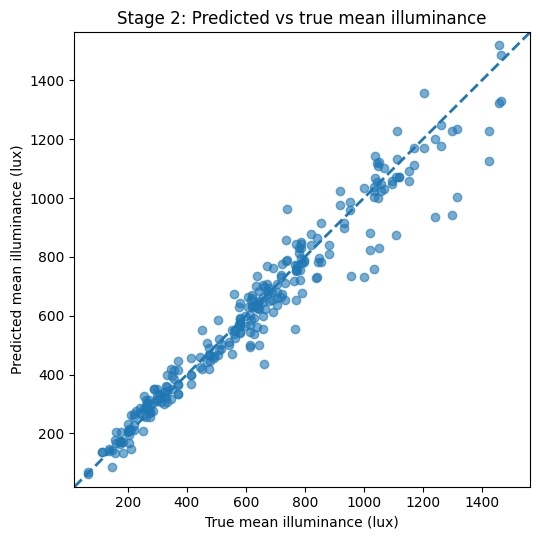

Saved plot to: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/stage2_mean_illuminance_pred_vs_true.png


In [ ]:
# =========================================================
# EVALUATE PREDICTED MEAN ILLUMINANCE FROM STAGE 2
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

PRED_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/test_predictions_multioutput.csv")

OUT_DIR = PRED_PATH.parent
OUT_CSV = OUT_DIR / "stage2_mean_illuminance_metrics.csv"
OUT_PRED = OUT_DIR / "stage2_mean_illuminance_predictions.csv"
OUT_PLOT = OUT_DIR / "stage2_mean_illuminance_pred_vs_true.png"

df = pd.read_csv(PRED_PATH)

required_cols = [
    "true_C", "true_UL", "true_UR", "true_LR", "true_LL",
    "pred_C", "pred_UL", "pred_UR", "pred_LR", "pred_LL"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in Stage 2 predictions file: {missing}")

df["true_mean_lux"] = df[["true_C", "true_UL", "true_UR", "true_LR", "true_LL"]].mean(axis=1)
df["pred_mean_lux"] = df[["pred_C", "pred_UL", "pred_UR", "pred_LR", "pred_LL"]].mean(axis=1)

y_true = df["true_mean_lux"].values
y_pred = df["pred_mean_lux"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0)

metrics_df = pd.DataFrame([{
    "model": "Stage2_mean_illuminance",
    "n": len(df),
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "MAPE": mape,
}])

metrics_df.to_csv(OUT_CSV, index=False)
df[["image_path", "filename", "true_mean_lux", "pred_mean_lux"]].to_csv(OUT_PRED, index=False)

print("STAGE 2 MEAN ILLUMINANCE METRICS")
print(metrics_df.to_string(index=False))
print("\nSaved metrics to:", OUT_CSV)
print("Saved mean predictions to:", OUT_PRED)

# Plot
lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
pad = 0.03 * (hi - lo if hi > lo else 1)
lo -= pad
hi += pad

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=2)
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.xlabel("True mean illuminance (lux)")
plt.ylabel("Predicted mean illuminance (lux)")
plt.title("Stage 2: Predicted vs true mean illuminance")
plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot to:", OUT_PLOT)

CSV files found:

/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/stage3_overall_summary.csv
/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/stage3_summary_by_target.csv
/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/test_predictions_stage3.csv
/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/training_history_stage3.csv

Using prediction file:
/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/test_predictions_stage3.csv

Columns:
['image_path', 'filename', 'true_C', 'pred_C', 'abs_err_C', 'true_UL', 'pred_UL', 'abs_err_UL', 'true_UR', 'pred_UR', 'abs_err_UR', 'true_LR', 'pred_LR', 'abs_err_LR', 'true_LL', 'pred_LL', 'abs_err_LL']

STAGE 3 MEAN ILLUMINANCE METRICS
                  model   n       MAE      RMSE       R2     MAPE
Stage3_mean_il

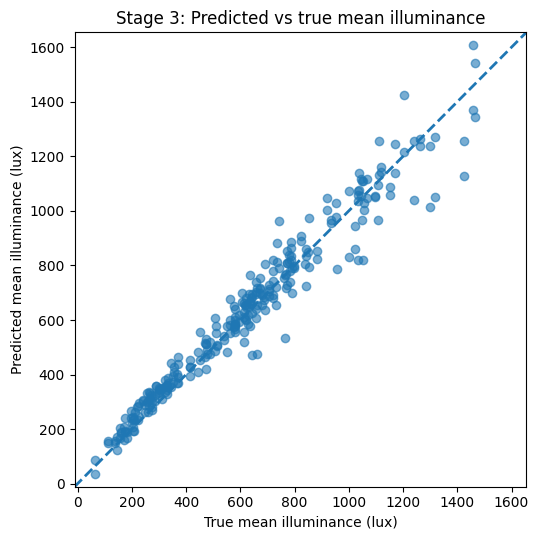

Saved plot to: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/stage3_mean_illuminance_pred_vs_true.png


In [ ]:
# =========================================================
# FIND STAGE 3 PREDICTIONS FILE AUTOMATICALLY
# AND EVALUATE MEAN ILLUMINANCE
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

STAGE3_DIR = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads")

# ---------------------------------------------------------
# FIND CANDIDATE CSV FILES
# ---------------------------------------------------------
csv_files = sorted(STAGE3_DIR.rglob("*.csv"))

print("CSV files found:\n")
for p in csv_files:
    print(p)

# Look for likely prediction file
candidate = None
for p in csv_files:
    name = p.name.lower()
    if "pred" in name:
        candidate = p
        break

if candidate is None:
    raise FileNotFoundError("Could not automatically find a Stage 3 prediction CSV.")

print("\nUsing prediction file:")
print(candidate)

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
df = pd.read_csv(candidate)
print("\nColumns:")
print(df.columns.tolist())

# ---------------------------------------------------------
# TRY TO IDENTIFY COLUMN NAMES
# ---------------------------------------------------------
# expected ideal names:
# true_C, true_UL, true_UR, true_LR, true_LL
# pred_C, pred_UL, pred_UR, pred_LR, pred_LL

true_cols = ["true_C", "true_UL", "true_UR", "true_LR", "true_LL"]
pred_cols = ["pred_C", "pred_UL", "pred_UR", "pred_LR", "pred_LL"]

missing_true = [c for c in true_cols if c not in df.columns]
missing_pred = [c for c in pred_cols if c not in df.columns]

if missing_true or missing_pred:
    raise ValueError(
        f"Prediction file found, but expected columns are missing.\n"
        f"Missing true cols: {missing_true}\n"
        f"Missing pred cols: {missing_pred}\n"
        f"Available columns: {df.columns.tolist()}"
    )

# ---------------------------------------------------------
# COMPUTE MEAN ILLUMINANCE
# ---------------------------------------------------------
df["true_mean_lux"] = df[true_cols].mean(axis=1)
df["pred_mean_lux"] = df[pred_cols].mean(axis=1)

y_true = df["true_mean_lux"].values
y_pred = df["pred_mean_lux"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0)

metrics_df = pd.DataFrame([{
    "model": "Stage3_mean_illuminance",
    "n": len(df),
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "MAPE": mape,
}])

out_csv = STAGE3_DIR / "stage3_mean_illuminance_metrics.csv"
out_pred = STAGE3_DIR / "stage3_mean_illuminance_predictions.csv"
out_plot = STAGE3_DIR / "stage3_mean_illuminance_pred_vs_true.png"

metrics_df.to_csv(out_csv, index=False)

keep_cols = [c for c in ["image_path", "filename"] if c in df.columns]
keep_cols += ["true_mean_lux", "pred_mean_lux"]
df[keep_cols].to_csv(out_pred, index=False)

print("\nSTAGE 3 MEAN ILLUMINANCE METRICS")
print(metrics_df.to_string(index=False))
print("\nSaved metrics to:", out_csv)
print("Saved mean predictions to:", out_pred)

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------
lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
pad = 0.03 * (hi - lo if hi > lo else 1)
lo -= pad
hi += pad

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=2)
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.xlabel("True mean illuminance (lux)")
plt.ylabel("Predicted mean illuminance (lux)")
plt.title("Stage 3: Predicted vs true mean illuminance")
plt.tight_layout()
plt.savefig(out_plot, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot to:", out_plot)

In [ ]:
# =========================================================
# COMPARE STAGE 2 VS STAGE 3 MEAN ILLUMINANCE
# =========================================================

from pathlib import Path
import pandas as pd

stage2_metrics = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/stage2_mean_illuminance_metrics.csv")
stage3_metrics = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/stage3_mean_illuminance_metrics.csv")

df2 = pd.read_csv(stage2_metrics)
df3 = pd.read_csv(stage3_metrics)

compare = pd.concat([df2, df3], ignore_index=True)
print(compare.to_string(index=False))

                  model   n       MAE      RMSE       R2     MAPE
Stage2_mean_illuminance 274 49.205880 75.876827 0.946116 8.282914
Stage3_mean_illuminance 274 50.602042 71.666238 0.951931 9.587526


STAGE 1 MEAN ILLUMINANCE METRICS
                  model   n       MAE     RMSE       R2     MAPE
Stage1_mean_illuminance 274 52.630264 80.85373 0.938816 9.597243

Saved metrics to: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage1_predict_all5_separate/stage1_mean_illuminance_metrics.csv
Saved mean predictions to: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage1_predict_all5_separate/stage1_mean_illuminance_predictions.csv


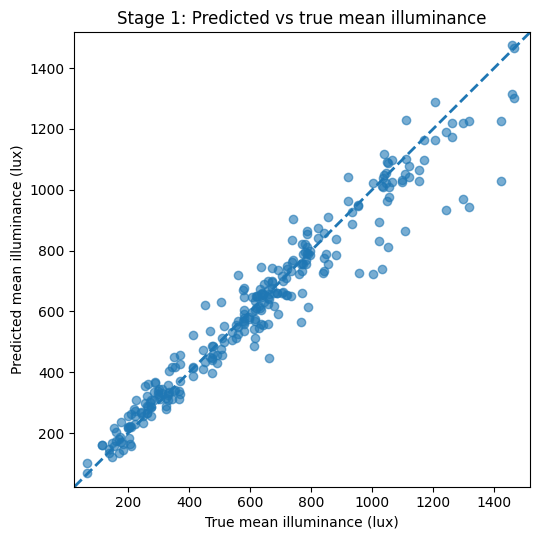

Saved plot to: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage1_predict_all5_separate/stage1_mean_illuminance_pred_vs_true.png


In [ ]:
# =========================================================
# EVALUATE PREDICTED MEAN ILLUMINANCE FROM STAGE 1
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

BASE_DIR = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage1_predict_all5_separate")

PRED_FILES = {
    "C":  BASE_DIR / "optionB_stage1_standard_split__C"  / "test_predictions.csv",
    "UL": BASE_DIR / "optionB_stage1_standard_split__UL" / "test_predictions.csv",
    "UR": BASE_DIR / "optionB_stage1_standard_split__UR" / "test_predictions.csv",
    "LR": BASE_DIR / "optionB_stage1_standard_split__LR" / "test_predictions.csv",
    "LL": BASE_DIR / "optionB_stage1_standard_split__LL" / "test_predictions.csv",
}

OUT_CSV = BASE_DIR / "stage1_mean_illuminance_metrics.csv"
OUT_PRED = BASE_DIR / "stage1_mean_illuminance_predictions.csv"
OUT_PLOT = BASE_DIR / "stage1_mean_illuminance_pred_vs_true.png"

merged = None

for roi, path in PRED_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing prediction file for {roi}: {path}")

    df = pd.read_csv(path)
    needed = ["image_path", "filename", "target_lux", "pred"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {path}: {missing}")

    df = df[needed].copy()
    df = df.rename(columns={
        "target_lux": f"true_{roi}",
        "pred": f"pred_{roi}",
    })

    if merged is None:
        merged = df
    else:
        merged = merged.merge(df, on=["image_path", "filename"], how="inner")

merged["true_mean_lux"] = merged[["true_C", "true_UL", "true_UR", "true_LR", "true_LL"]].mean(axis=1)
merged["pred_mean_lux"] = merged[["pred_C", "pred_UL", "pred_UR", "pred_LR", "pred_LL"]].mean(axis=1)

y_true = merged["true_mean_lux"].values
y_pred = merged["pred_mean_lux"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0)

metrics_df = pd.DataFrame([{
    "model": "Stage1_mean_illuminance",
    "n": len(merged),
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "MAPE": mape,
}])

metrics_df.to_csv(OUT_CSV, index=False)
merged[["image_path", "filename", "true_mean_lux", "pred_mean_lux"]].to_csv(OUT_PRED, index=False)

print("STAGE 1 MEAN ILLUMINANCE METRICS")
print(metrics_df.to_string(index=False))
print("\nSaved metrics to:", OUT_CSV)
print("Saved mean predictions to:", OUT_PRED)

lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
pad = 0.03 * (hi - lo if hi > lo else 1)
lo -= pad
hi += pad

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=2)
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.xlabel("True mean illuminance (lux)")
plt.ylabel("Predicted mean illuminance (lux)")
plt.title("Stage 1: Predicted vs true mean illuminance")
plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot to:", OUT_PLOT)

In [ ]:
# =========================================================
# SHOW 15 WORST, 5 MEDIUM, 5 BEST MEAN-ILLUMINANCE CASES
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# CHOOSE FILE
# ---------------------------------------------------------
PRED_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/stage2_mean_illuminance_predictions.csv")
# You can change this to stage1 or stage3

OUT_DIR = PRED_PATH.parent
OUT_CSV = OUT_DIR / "selected_examples_mean_illuminance.csv"

df = pd.read_csv(PRED_PATH)

# ---------------------------------------------------------
# REQUIRED COLUMNS
# ---------------------------------------------------------
required = ["image_path", "filename", "true_mean_lux", "pred_mean_lux"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df["abs_err"] = (df["pred_mean_lux"] - df["true_mean_lux"]).abs()

# sort by error
df_sorted = df.sort_values("abs_err").reset_index(drop=True)

best_df = df_sorted.head(5).copy()
worst_df = df_sorted.tail(15).copy()

# medium = around median error
mid_idx = len(df_sorted) // 2
medium_df = df_sorted.iloc[max(0, mid_idx - 2): min(len(df_sorted), mid_idx + 3)].copy()

selected = pd.concat([
    best_df.assign(group="best"),
    medium_df.assign(group="medium"),
    worst_df.assign(group="worst"),
], ignore_index=True)

selected.to_csv(OUT_CSV, index=False)
print("Saved selected rows to:", OUT_CSV)

print("\nBest examples:")
print(best_df[["filename", "true_mean_lux", "pred_mean_lux", "abs_err"]])

print("\nMedium examples:")
print(medium_df[["filename", "true_mean_lux", "pred_mean_lux", "abs_err"]])

print("\nWorst examples:")
print(worst_df[["filename", "true_mean_lux", "pred_mean_lux", "abs_err"]])

# ---------------------------------------------------------
# DISPLAY FUNCTION
# ---------------------------------------------------------
def show_examples(df_subset, title, ncols=5, figsize_scale=4):
    n = len(df_subset)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * figsize_scale, nrows * figsize_scale))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, df_subset.iterrows()):
        img = Image.open(row["image_path"])
        img = ImageOps.exif_transpose(img).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"{Path(row['filename']).name}\n"
            f"true={row['true_mean_lux']:.1f}, pred={row['pred_mean_lux']:.1f}\n"
            f"abs err={row['abs_err']:.1f}",
            fontsize=9
        )
        ax.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# SHOW
# ---------------------------------------------------------
show_examples(best_df, "5 Best mean-illuminance predictions", ncols=5)
show_examples(medium_df, "5 Medium mean-illuminance predictions", ncols=5)
show_examples(worst_df, "15 Worst mean-illuminance predictions", ncols=5)

Output hidden; open in https://colab.research.google.com to view.

COMPARISON
                       method  n_test       MAE      RMSE       R2     MAPE
  plain_mean_of_5_predictions      83 47.157409 71.128098 0.951096 9.023668
weighted_reconciliation_ridge      83 45.733550 68.024995 0.955270 9.232719

Learned weights:
pred_C: 2.8359
pred_UL: -0.5950
pred_UR: 0.5756
pred_LR: -0.7284
pred_LL: -1.2556
intercept: 24.8554

Saved metrics to: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/stage2_weighted_mean_metrics.csv
Saved predictions to: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/stage2_weighted_mean_predictions.csv


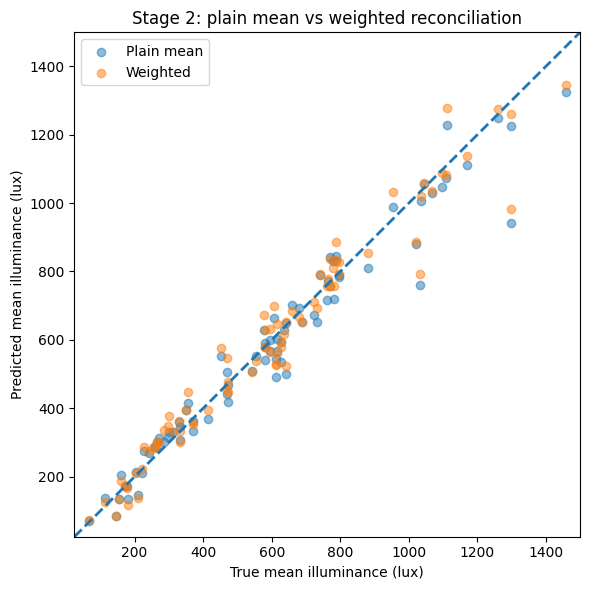

Saved plot to: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/stage2_weighted_mean_pred_vs_true.png


In [ ]:
# =========================================================
# WEIGHTED RECONCILIATION OF 5 PREDICTED ROI VALUES
# STAGE 2 VERSION
# Learns weighted mean illuminance from predicted C, UL, UR, LR, LL
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------
PRED_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/test_predictions_multioutput.csv")
OUT_DIR = PRED_PATH.parent

OUT_METRICS = OUT_DIR / "stage2_weighted_mean_metrics.csv"
OUT_PRED = OUT_DIR / "stage2_weighted_mean_predictions.csv"
OUT_PLOT = OUT_DIR / "stage2_weighted_mean_pred_vs_true.png"

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
df = pd.read_csv(PRED_PATH)

required_cols = [
    "true_C", "true_UL", "true_UR", "true_LR", "true_LL",
    "pred_C", "pred_UL", "pred_UR", "pred_LR", "pred_LL"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# ---------------------------------------------------------
# TRUE MEAN AND PLAIN MEAN
# ---------------------------------------------------------
true_cols = ["true_C", "true_UL", "true_UR", "true_LR", "true_LL"]
pred_cols = ["pred_C", "pred_UL", "pred_UR", "pred_LR", "pred_LL"]

df["true_mean_lux"] = df[true_cols].mean(axis=1)
df["plain_mean_pred_lux"] = df[pred_cols].mean(axis=1)

X = df[pred_cols].values
y = df["true_mean_lux"].values

# ---------------------------------------------------------
# CALIBRATION SPLIT
# ---------------------------------------------------------
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index.values, test_size=0.30, random_state=42
)

# Try Ridge first for stability
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred_weighted = model.predict(X_test)
y_pred_plain = X_test.mean(axis=1)

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0)
    return mae, rmse, r2, mape

plain_mae, plain_rmse, plain_r2, plain_mape = metrics(y_test, y_pred_plain)
w_mae, w_rmse, w_r2, w_mape = metrics(y_test, y_pred_weighted)

metrics_df = pd.DataFrame([
    {
        "method": "plain_mean_of_5_predictions",
        "n_test": len(y_test),
        "MAE": plain_mae,
        "RMSE": plain_rmse,
        "R2": plain_r2,
        "MAPE": plain_mape,
    },
    {
        "method": "weighted_reconciliation_ridge",
        "n_test": len(y_test),
        "MAE": w_mae,
        "RMSE": w_rmse,
        "R2": w_r2,
        "MAPE": w_mape,
    }
])

metrics_df.to_csv(OUT_METRICS, index=False)

# Save prediction rows
pred_out = df.loc[idx_test, ["image_path", "filename"]].copy() if "image_path" in df.columns else pd.DataFrame(index=idx_test)
if "filename" not in pred_out.columns and "filename" in df.columns:
    pred_out["filename"] = df.loc[idx_test, "filename"].values

pred_out["true_mean_lux"] = y_test
pred_out["plain_mean_pred_lux"] = y_pred_plain
pred_out["weighted_mean_pred_lux"] = y_pred_weighted
pred_out["plain_abs_err"] = np.abs(y_test - y_pred_plain)
pred_out["weighted_abs_err"] = np.abs(y_test - y_pred_weighted)
pred_out.to_csv(OUT_PRED, index=False)

print("COMPARISON")
print(metrics_df.to_string(index=False))

print("\nLearned weights:")
for col, coef in zip(pred_cols, model.coef_):
    print(f"{col}: {coef:.4f}")
print(f"intercept: {model.intercept_:.4f}")

print("\nSaved metrics to:", OUT_METRICS)
print("Saved predictions to:", OUT_PRED)

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------
lo = min(y_test.min(), y_pred_weighted.min(), y_pred_plain.min())
hi = max(y_test.max(), y_pred_weighted.max(), y_pred_plain.max())
pad = 0.03 * (hi - lo if hi > lo else 1)
lo -= pad
hi += pad

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_plain, alpha=0.5, label="Plain mean")
plt.scatter(y_test, y_pred_weighted, alpha=0.5, label="Weighted")
plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=2)
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.xlabel("True mean illuminance (lux)")
plt.ylabel("Predicted mean illuminance (lux)")
plt.title("Stage 2: plain mean vs weighted reconciliation")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot to:", OUT_PLOT)

In [ ]:
# =========================================================
# REUSABLE WEIGHTED RECONCILIATION FUNCTION
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_weighted_mean(pred_path, label):
    pred_path = Path(pred_path)
    out_dir = pred_path.parent

    df = pd.read_csv(pred_path)

    true_cols = ["true_C", "true_UL", "true_UR", "true_LR", "true_LL"]
    pred_cols = ["pred_C", "pred_UL", "pred_UR", "pred_LR", "pred_LL"]

    df["true_mean_lux"] = df[true_cols].mean(axis=1)
    df["plain_mean_pred_lux"] = df[pred_cols].mean(axis=1)

    X = df[pred_cols].values
    y = df["true_mean_lux"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42
    )

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)

    plain = X_test.mean(axis=1)
    weighted = model.predict(X_test)

    def metrics(y_true, y_pred):
        return {
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2": r2_score(y_true, y_pred),
            "MAPE": float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0),
        }

    plain_m = metrics(y_test, plain)
    weighted_m = metrics(y_test, weighted)

    out = pd.DataFrame([
        {"label": label, "method": "plain_mean", **plain_m},
        {"label": label, "method": "weighted_ridge", **weighted_m},
    ])

    print(f"\n=== {label} ===")
    print(out.to_string(index=False))
    print("weights:", dict(zip(pred_cols, model.coef_)))
    print("intercept:", model.intercept_)

    return out

stage2 = evaluate_weighted_mean(
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/test_predictions_multioutput.csv",
    "Stage2"
)

stage3 = evaluate_weighted_mean(
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/test_predictions_stage3.csv",
    "Stage3"
)

compare = pd.concat([stage2, stage3], ignore_index=True)
print("\nFINAL COMPARISON")
print(compare.to_string(index=False))


=== Stage2 ===
 label         method       MAE      RMSE       R2     MAPE
Stage2     plain_mean 47.157409 71.128098 0.951096 9.023668
Stage2 weighted_ridge 45.733550 68.024995 0.955270 9.232719
weights: {'pred_C': np.float64(2.8359194071390865), 'pred_UL': np.float64(-0.5949696812611063), 'pred_UR': np.float64(0.5755932862314411), 'pred_LR': np.float64(-0.7283812741618246), 'pred_LL': np.float64(-1.255628327435399)}
intercept: 24.855396483911704

=== Stage3 ===
 label         method       MAE      RMSE       R2     MAPE
Stage3     plain_mean 43.877488 63.360507 0.961194 9.251326
Stage3 weighted_ridge 43.496922 63.342553 0.961216 8.071900
weights: {'pred_C': np.float64(-11.024215083984059), 'pred_UL': np.float64(23.631150961971112), 'pred_UR': np.float64(-25.50451557734664), 'pred_LR': np.float64(26.328971175587217), 'pred_LL': np.float64(-11.0583255614214)}
intercept: -16.000295383660387

FINAL COMPARISON
 label         method       MAE      RMSE       R2     MAPE
Stage2     plain_me

In [ ]:
# =========================================================
# NONNEGATIVE NORMALIZED WEIGHTED MEAN
# Fits weights w >= 0, sum(w)=1 on a calibration split
# Compare vs plain mean for Stage 2 and Stage 3
# =========================================================

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import minimize

def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0),
    }

def fit_nonnegative_simplex(X_train, y_train):
    # weights only, no intercept
    n = X_train.shape[1]
    w0 = np.ones(n) / n

    def obj(w):
        yhat = X_train @ w
        return np.mean((y_train - yhat) ** 2)

    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * n

    res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res.success:
        raise RuntimeError(f"Optimization failed: {res.message}")
    return res.x

def evaluate_file(pred_path, label):
    pred_path = Path(pred_path)
    out_dir = pred_path.parent

    df = pd.read_csv(pred_path)

    true_cols = ["true_C", "true_UL", "true_UR", "true_LR", "true_LL"]
    pred_cols = ["pred_C", "pred_UL", "pred_UR", "pred_LR", "pred_LL"]

    missing = [c for c in true_cols + pred_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{label}: missing columns {missing}")

    df["true_mean_lux"] = df[true_cols].mean(axis=1)
    df["plain_mean_pred_lux"] = df[pred_cols].mean(axis=1)

    X = df[pred_cols].values
    y = df["true_mean_lux"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42
    )

    w = fit_nonnegative_simplex(X_train, y_train)

    plain = X_test.mean(axis=1)
    weighted = X_test @ w

    plain_m = metrics(y_test, plain)
    weighted_m = metrics(y_test, weighted)

    out = pd.DataFrame([
        {"label": label, "method": "plain_mean", **plain_m},
        {"label": label, "method": "weighted_nonnegative_sum1", **weighted_m},
    ])

    print(f"\n=== {label} ===")
    print(out.to_string(index=False))
    print("weights:", dict(zip(pred_cols, [round(v, 4) for v in w])))

    # save
    out_csv = out_dir / f"{label.lower()}_nonnegative_weighted_mean_metrics.csv"
    out.to_csv(out_csv, index=False)

    pred_out = pd.DataFrame({
        "true_mean_lux": y_test,
        "plain_mean_pred_lux": plain,
        "weighted_mean_pred_lux": weighted,
    })
    out_pred = out_dir / f"{label.lower()}_nonnegative_weighted_mean_predictions.csv"
    pred_out.to_csv(out_pred, index=False)

    print("saved:", out_csv)
    print("saved:", out_pred)

    return out

stage2 = evaluate_file(
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/test_predictions_multioutput.csv",
    "Stage2"
)

stage3 = evaluate_file(
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/test_predictions_stage3.csv",
    "Stage3"
)

compare = pd.concat([stage2, stage3], ignore_index=True)
print("\nFINAL COMPARISON")
print(compare.to_string(index=False))


=== Stage2 ===
 label                    method       MAE      RMSE       R2     MAPE
Stage2                plain_mean 47.157409 71.128098 0.951096 9.023668
Stage2 weighted_nonnegative_sum1 45.907169 67.997834 0.955306 9.152915
weights: {'pred_C': np.float64(0.6166), 'pred_UL': np.float64(0.0782), 'pred_UR': np.float64(0.3052), 'pred_LR': np.float64(0.0), 'pred_LL': np.float64(0.0)}
saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/stage2_nonnegative_weighted_mean_metrics.csv
saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/stage2_nonnegative_weighted_mean_predictions.csv

=== Stage3 ===
 label                    method       MAE      RMSE       R2     MAPE
Stage3                plain_mean 43.877488 63.360507 0.961194 9.251326
Stage3 weighted_nonnegative_sum1 43.790101 63.619881 0.960876 8.886997
weights: {'pred_C': np.float64(0.0), 'pred_UL': np.float64(0.3957), 'pred_UR': np.float64(0.0), 'pred_LR': np.float64(

In [ ]:
# =========================================================
# SUBSET BREAKDOWN FOR STAGE 2 / STAGE 3
# Reconstruct the same calibration-test subset from raw predictions
# and compare plain mean vs nonnegative weighted mean
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import minimize

MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37.csv")

FILES = {
    "Stage2": {
        "raw_pred": Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/test_predictions_multioutput.csv"),
        "out_csv": Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/stage2_subset_breakdown_reconstructed.csv"),
    },
    "Stage3": {
        "raw_pred": Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/test_predictions_stage3.csv"),
        "out_csv": Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/stage3_subset_breakdown_reconstructed.csv"),
    }
}

master = pd.read_csv(MASTER_PATH)
meta = master[["image_path", "filename", "surface_group_norm"]].drop_duplicates(subset=["image_path"]).copy()

def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0),
    }

def fit_nonnegative_simplex(X_train, y_train):
    n = X_train.shape[1]
    w0 = np.ones(n) / n

    def obj(w):
        yhat = X_train @ w
        return np.mean((y_train - yhat) ** 2)

    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * n

    res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res.success:
        raise RuntimeError(f"Optimization failed: {res.message}")
    return res.x

for label, cfg in FILES.items():
    print(f"\n--- {label} ---")
    raw = pd.read_csv(cfg["raw_pred"]).copy()

    required = [
        "image_path", "filename",
        "true_C", "true_UL", "true_UR", "true_LR", "true_LL",
        "pred_C", "pred_UL", "pred_UR", "pred_LR", "pred_LL"
    ]
    missing = [c for c in required if c not in raw.columns]
    if missing:
        raise ValueError(f"{label}: missing columns {missing}")

    true_cols = ["true_C", "true_UL", "true_UR", "true_LR", "true_LL"]
    pred_cols = ["pred_C", "pred_UL", "pred_UR", "pred_LR", "pred_LL"]

    raw["true_mean_lux"] = raw[true_cols].mean(axis=1)
    raw["plain_mean_pred_lux"] = raw[pred_cols].mean(axis=1)

    X = raw[pred_cols].values
    y = raw["true_mean_lux"].values

    # repeat the same split used in weighted calibration
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, raw.index.values, test_size=0.30, random_state=42
    )

    # fit same constrained weighted mean
    w = fit_nonnegative_simplex(X_train, y_train)

    test_df = raw.loc[idx_test].copy().reset_index(drop=True)
    test_df["weighted_mean_pred_lux"] = X_test @ w

    # attach surface metadata
    test_df = test_df.merge(meta, on="image_path", how="left", suffixes=("", "_meta"))

    print("Rows in reconstructed test subset:", len(test_df))
    print("Weights:", dict(zip(pred_cols, [round(v, 4) for v in w])))
    print(test_df["surface_group_norm"].value_counts(dropna=False))

    rows = []
    subset_defs = {
        "white_paper_only": test_df["surface_group_norm"] == "white_paper",
        "table_only": test_df["surface_group_norm"] == "table",
        "combined_white_paper_plus_table": test_df["surface_group_norm"].isin(["white_paper", "table"]),
    }

    for subset_name, mask in subset_defs.items():
        sub = test_df[mask].copy()
        if len(sub) == 0:
            continue

        plain_m = metrics(sub["true_mean_lux"].values, sub["plain_mean_pred_lux"].values)
        weighted_m = metrics(sub["true_mean_lux"].values, sub["weighted_mean_pred_lux"].values)

        rows.append({
            "stage": label,
            "subset": subset_name,
            "method": "plain_mean",
            "n": len(sub),
            **plain_m
        })
        rows.append({
            "stage": label,
            "subset": subset_name,
            "method": "weighted_nonnegative_sum1",
            "n": len(sub),
            **weighted_m
        })

    summary = pd.DataFrame(rows)
    summary.to_csv(cfg["out_csv"], index=False)

    print(f"\n=== {label} subset breakdown ===")
    print(summary.to_string(index=False))
    print("saved:", cfg["out_csv"])


--- Stage2 ---
Rows in reconstructed test subset: 83
Weights: {'pred_C': np.float64(0.6166), 'pred_UL': np.float64(0.0782), 'pred_UR': np.float64(0.3052), 'pred_LR': np.float64(0.0), 'pred_LL': np.float64(0.0)}
surface_group_norm
table          42
white_paper    41
Name: count, dtype: int64

=== Stage2 subset breakdown ===
 stage                          subset                    method  n       MAE      RMSE       R2      MAPE
Stage2                white_paper_only                plain_mean 41 34.692629 45.993704 0.980932  6.762754
Stage2                white_paper_only weighted_nonnegative_sum1 41 33.289907 42.733293 0.983540  6.811266
Stage2                      table_only                plain_mean 42 59.325409 89.066838 0.914468 11.230751
Stage2                      table_only weighted_nonnegative_sum1 42 58.224019 85.759359 0.920703 11.438812
Stage2 combined_white_paper_plus_table                plain_mean 83 47.157409 71.128098 0.951096  9.023668
Stage2 combined_white_paper_plus

In [ ]:
from pathlib import Path

# Folder on Google Drive
folder = Path("/content/drive/MyDrive/AI_Lux_Project/Database")

total_bytes = 0
file_count = 0

for p in folder.rglob("*"):
    if p.is_file():
        total_bytes += p.stat().st_size
        file_count += 1

size_kb = total_bytes / 1024
size_mb = total_bytes / (1024 ** 2)
size_gb = total_bytes / (1024 ** 3)

print("Folder:", folder)
print("Files:", file_count)
print(f"Total size: {total_bytes:,} bytes")
print(f"Total size: {size_kb:,.2f} KB")
print(f"Total size: {size_mb:,.2f} MB")
print(f"Total size: {size_gb:,.2f} GB")

Folder: /content/drive/MyDrive/AI_Lux_Project/Database
Files: 5475
Total size: 23,452,021,622 bytes
Total size: 22,902,364.87 KB
Total size: 22,365.59 MB
Total size: 21.84 GB


In [ ]:
from pathlib import Path
import pandas as pd

# =========================================================
# PATHS
# =========================================================
DB_ROOT = Path("/content/drive/MyDrive/AI_Lux_Project/Database")

CSV_CANDIDATES = [
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_3/annotations/annotation_master_current.csv",
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_3/fixed_parser_refresh/annotation_master_fixed.csv",
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_3/fixed_parser_refresh/extracted_features_refresh_5roi_fullcontext_fixed.csv",
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_clean_from_existing_5point_cache.csv",
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37.csv",
]

SESSION_TO_CHECK = "F033"

# =========================================================
# 1) CHECK DATABASE FILES
# =========================================================
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

db_hits = []
for p in DB_ROOT.rglob("*"):
    if p.is_file() and p.suffix.lower() in image_exts:
        name = p.name
        if name.startswith(SESSION_TO_CHECK + "__") or f"/{SESSION_TO_CHECK}__" in str(p):
            db_hits.append(str(p))

print("=" * 80)
print("DATABASE CHECK")
print("=" * 80)
print(f"Session checked: {SESSION_TO_CHECK}")
print(f"Files still found in database: {len(db_hits)}\n")

for x in db_hits[:200]:
    print(x)

if len(db_hits) > 200:
    print(f"\n... and {len(db_hits)-200} more")

# =========================================================
# 2) CHECK CSV FILES
# =========================================================
print("\n" + "=" * 80)
print("CSV CHECK")
print("=" * 80)

for csv_path in CSV_CANDIDATES:
    p = Path(csv_path)
    if not p.exists():
        print(f"\n[missing] {csv_path}")
        continue

    try:
        df = pd.read_csv(p)
    except Exception as e:
        print(f"\n[error reading] {csv_path}\n{e}")
        continue

    hit_mask = pd.Series(False, index=df.index)

    # look in common columns
    for col in ["session", "filename", "image_name", "image_path"]:
        if col in df.columns:
            vals = df[col].astype(str)
            if col == "session":
                hit_mask |= vals.eq(SESSION_TO_CHECK)
            else:
                hit_mask |= vals.str.contains(SESSION_TO_CHECK, na=False)

    hits = df[hit_mask].copy()

    print(f"\n{csv_path}")
    print(f"Rows with {SESSION_TO_CHECK}: {len(hits)}")

    if len(hits) > 0:
        show_cols = [c for c in ["session", "filename", "image_name", "image_path", "surface", "surface_norm"] if c in hits.columns]
        print(hits[show_cols].head(20).to_string(index=False))

# =========================================================
# 3) SIMPLE SUMMARY MESSAGE
# =========================================================
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

if len(db_hits) == 0:
    print(f"No {SESSION_TO_CHECK} image files were found in the database folder.")
else:
    print(f"There are still {len(db_hits)} {SESSION_TO_CHECK} image files in the database folder.")

print("Check the CSV counts above before uploading the corrected files.")

DATABASE CHECK
Session checked: F033
Files still found in database: 31

/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__burgundy_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__blush_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__cool_red_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__dark_indigo_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__dark_burgundy_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__deep_blue_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__forest_green_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__grass_green_paper.jpg
/content/drive/MyDrive/AI_Lux_Proje

/tmp/ipykernel_8395/1501781257.py:57: DtypeWarning: Columns (245) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(p)


In [ ]:
from pathlib import Path

DB_ROOT = Path("/content/drive/MyDrive/AI_Lux_Project/Database")
SESSION_TO_DELETE = "F033"
DRY_RUN = False  # set False only when sure

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

to_delete = []
for p in DB_ROOT.rglob("*"):
    if p.is_file() and p.suffix.lower() in image_exts:
        if p.name.startswith(SESSION_TO_DELETE + "__"):
            to_delete.append(p)

print(f"Found {len(to_delete)} files to delete:\n")
for p in to_delete:
    print(p)

if DRY_RUN:
    print("\nDRY_RUN=True, nothing deleted.")
else:
    for p in to_delete:
        p.unlink()
    print("\nDeletion complete.")

Found 21 files to delete:

/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC50__UL40__UR40__LR40__LL40__maroon_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC50__UL40__UR40__LR40__LL40__grass_green_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC50__UL40__UR40__LR40__LL40__magenta_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC50__UL40__UR40__LR40__LL40__blush_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC50__UL40__UR40__LR40__LL40__white_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LC50__UL40__UR40__LR40__LL40__dark_indigo_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LT050__burgundy_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LT050__cool_red_paper.jpg
/content/drive/MyDrive/AI_Lux_Project/Database/F033__Tlightwood__LT050__dark_burgundy_paper.jpg
/content/drive

In [ ]:
from pathlib import Path
import pandas as pd
import re

DB_ROOT = Path("/content/drive/MyDrive/AI_Lux_Project/Database")
OUT_DIR = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/F033_fix")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SESSION = "F033"

# fixed grouping helpers
def infer_surface_group(surface: str) -> str:
    s = str(surface).strip().lower()
    if s == "white_paper":
        return "white_paper"
    if s == "table":
        return "table"
    if s.endswith("_paper"):
        return "colored_paper"
    return "other"

def infer_table_family(table_name: str) -> str:
    t = str(table_name).lower()
    if "twhite" in t or t == "twhite":
        return "white_table"
    if "laminate" in t:
        return "laminate"
    if "tbrown" in t or "brown" in t:
        return "brown_wood_like"
    if "beige" in t:
        return "beige_table"
    return "other_table"

PAT_5 = re.compile(
    r'^(?P<session>F\d+)__(?P<table>T.+?)__LC(?P<LC>\d+)_UL(?P<UL>\d+)_UR(?P<UR>\d+)_LR(?P<LR>\d+)_LL(?P<LL>\d+)__(?P<surface>.+)\.(jpg|jpeg|png)$',
    re.IGNORECASE
)

image_exts = {".jpg", ".jpeg", ".png"}

rows = []
for p in sorted(DB_ROOT.iterdir()):
    if not p.is_file() or p.suffix.lower() not in image_exts:
        continue
    if not p.name.startswith(SESSION + "__"):
        continue

    m = PAT_5.match(p.name)
    if not m:
        print("Could not parse:", p.name)
        continue

    surface = m.group("surface")
    row = {
        "image_path": str(p),
        "image_name": p.name,
        "filename": p.name,
        "session": m.group("session"),
        "table": m.group("table"),
        "table_type": m.group("table"),
        "surface": surface,
        "surface_norm": surface,
        "label_kind": "5point",
        "lux_C": int(m.group("LC")),
        "lux_UL": int(m.group("UL")),
        "lux_UR": int(m.group("UR")),
        "lux_LR": int(m.group("LR")),
        "lux_LL": int(m.group("LL")),
        "central_lux": int(m.group("LC")),
        "target_lux": int(m.group("LC")),
        "surface_group": infer_surface_group(surface),
        "surface_group_norm": infer_surface_group(surface),
        "family_group": infer_table_family(m.group("table")),
    }
    rows.append(row)

f033_anno = pd.DataFrame(rows)
f033_anno.to_csv(OUT_DIR / "F033_corrected_annotation_rows.csv", index=False)

print("Corrected F033 rows:", len(f033_anno))
print(f033_anno[["filename", "surface", "surface_group_norm"]].head(40).to_string(index=False))
print("Saved:", OUT_DIR / "F033_corrected_annotation_rows.csv")

Corrected F033 rows: 31
                                                           filename             surface surface_group_norm
            F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__PRINT11.jpg             PRINT11              other
            F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__PRINT12.jpg             PRINT12              other
            F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__PRINT13.jpg             PRINT13              other
            F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__PRINT14.jpg             PRINT14              other
            F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__PRINT15.jpg             PRINT15              other
            F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__PRINT16.jpg             PRINT16              other
        F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__blush_paper.jpg         blush_paper      colored_paper
     F033__Tlightwood__LC68_UL46_UR51_LR82_LL78__burgundy_paper.jpg      burgundy_paper      colored_paper
     F033__Tl

In [ ]:
from pathlib import Path
import pandas as pd

FIX_DIR = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/F033_fix")
NEW_F033 = pd.read_csv(FIX_DIR / "F033_corrected_annotation_rows.csv")

annotation_targets = [
    Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_3/annotations/annotation_master_current.csv"),
    Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_3/fixed_parser_refresh/annotation_master_fixed.csv"),
]

for path in annotation_targets:
    df = pd.read_csv(path)
    before = len(df)

    # remove old F033 rows
    mask = pd.Series(False, index=df.index)
    for col in ["session", "image_name", "filename", "image_path"]:
        if col in df.columns:
            vals = df[col].astype(str)
            if col == "session":
                mask |= vals.eq("F033")
            else:
                mask |= vals.str.contains("F033", na=False)

    df = df.loc[~mask].copy()

    # keep only columns that exist in target file
    add_cols = [c for c in NEW_F033.columns if c in df.columns]
    add_df = NEW_F033[add_cols].copy()

    updated = pd.concat([df, add_df], ignore_index=True)
    updated.to_csv(path, index=False)

    print("\nUpdated:", path)
    print("Rows before:", before)
    print("Rows after :", len(updated))
    print("Added F033 rows:", len(add_df))


Updated: /content/drive/MyDrive/AI_Lux_Project/Experiments_3/annotations/annotation_master_current.csv
Rows before: 5460
Rows after : 5467
Added F033 rows: 31

Updated: /content/drive/MyDrive/AI_Lux_Project/Experiments_3/fixed_parser_refresh/annotation_master_fixed.csv
Rows before: 5460
Rows after : 5467
Added F033 rows: 31


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image, ImageOps, Image

FIX_DIR = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/F033_fix")
anno = pd.read_csv(FIX_DIR / "F033_corrected_annotation_rows.csv")

ROI_COORDS = {
    "C":  (1520, 2027),
    "UL": (1020, 1372),
    "UR": (2043, 1372),
    "LR": (2030, 2722),
    "LL": (1020, 2722),
}
ROI_SIZES = {
    "C": 256,
    "UL": 128,
    "UR": 128,
    "LR": 128,
    "LL": 128,
}

def crop_patch(img, x, y, crop_size):
    half = crop_size // 2
    left = int(round(x - half))
    top = int(round(y - half))
    right = left + crop_size
    bottom = top + crop_size

    pad_left = max(0, -left)
    pad_top = max(0, -top)
    pad_right = max(0, right - img.width)
    pad_bottom = max(0, bottom - img.height)

    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(arr, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), mode="edge")
        img = Image.fromarray(arr)
        left += pad_left
        right += pad_left
        top += pad_top
        bottom += pad_top

    return np.asarray(img.crop((left, top, right, bottom))).astype(np.float32)

def rgb_to_luma(arr):
    return 0.2126 * arr[..., 0] + 0.7152 * arr[..., 1] + 0.0722 * arr[..., 2]

def grad_mean_std(gray):
    gy, gx = np.gradient(gray.astype(np.float32))
    g = np.sqrt(gx**2 + gy**2)
    return float(g.mean()), float(g.std())

def sat_proxy(arr):
    mx = arr.max(axis=2)
    mn = arr.min(axis=2)
    denom = np.maximum(mx, 1e-6)
    return ((mx - mn) / denom).mean()

def square_bbox():
    lefts, rights, tops, bottoms = [], [], [], []
    for roi in ["UL", "UR", "LR", "LL"]:
        x, y = ROI_COORDS[roi]
        r = ROI_SIZES[roi] // 2
        lefts.append(x - r)
        rights.append(x + r)
        tops.append(y - r)
        bottoms.append(y + r)
    return min(lefts), min(tops), max(rights), max(bottoms)

def crop_bbox(img, left, top, right, bottom):
    pad_left = max(0, -left)
    pad_top = max(0, -top)
    pad_right = max(0, right - img.width)
    pad_bottom = max(0, bottom - img.height)
    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(arr, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), mode="edge")
        img = Image.fromarray(arr)
        left += pad_left
        right += pad_left
        top += pad_top
        bottom += pad_top
    return np.asarray(img.crop((left, top, right, bottom))).astype(np.float32)

left, top, right, bottom = square_bbox()

rows = []
for _, r in anno.iterrows():
    img = Image.open(r["image_path"])
    img = ImageOps.exif_transpose(img).convert("RGB")

    feat = dict(r)

    roi_lumas = {}
    roi_grads = {}

    for roi in ["C", "UL", "UR", "LR", "LL"]:
        patch = crop_patch(img, ROI_COORDS[roi][0], ROI_COORDS[roi][1], ROI_SIZES[roi])
        luma = rgb_to_luma(patch)
        gmean, gstd = grad_mean_std(luma)

        feat[f"{roi}_mean_luma"] = float(luma.mean())
        feat[f"{roi}_std_luma"] = float(luma.std())
        feat[f"{roi}_grad_mean"] = gmean
        feat[f"{roi}_grad_std"] = gstd

        roi_lumas[roi] = float(luma.mean())
        roi_grads[roi] = gmean

    corners = np.array([roi_lumas["UL"], roi_lumas["UR"], roi_lumas["LR"], roi_lumas["LL"]], dtype=np.float32)

    feat["corner_mean_luma"] = float(corners.mean())
    feat["corner_std_luma"] = float(corners.std())
    feat["corner_range_luma"] = float(corners.max() - corners.min())
    feat["C_minus_corner_mean_luma"] = roi_lumas["C"] - float(corners.mean())
    feat["C_over_corner_mean_luma"] = roi_lumas["C"] / max(float(corners.mean()), 1e-6)
    feat["C_minus_UL_luma"] = roi_lumas["C"] - roi_lumas["UL"]
    feat["C_minus_UR_luma"] = roi_lumas["C"] - roi_lumas["UR"]
    feat["C_minus_LR_luma"] = roi_lumas["C"] - roi_lumas["LR"]
    feat["C_minus_LL_luma"] = roi_lumas["C"] - roi_lumas["LL"]

    sq = crop_bbox(img, left, top, right, bottom)
    sq_luma = rgb_to_luma(sq)
    sq_gmean, sq_gstd = grad_mean_std(sq_luma)

    feat["square_mean_luma"] = float(sq_luma.mean())
    feat["square_std_luma"] = float(sq_luma.std())
    feat["square_grad_mean"] = sq_gmean
    feat["square_grad_std"] = sq_gstd
    feat["square_mean_sat_proxy"] = float(sat_proxy(sq))

    ys = np.linspace(0, sq_luma.shape[0], 6).astype(int)
    xs = np.linspace(0, sq_luma.shape[1], 6).astype(int)
    cell_means = []
    for i in range(5):
        row_cells = []
        for j in range(5):
            cell = sq_luma[ys[i]:ys[i+1], xs[j]:xs[j+1]]
            row_cells.append(float(cell.mean()))
        cell_means.append(row_cells)
    cell_means = np.array(cell_means)

    feat["square_top_mean_luma"] = float(cell_means[0, :].mean())
    feat["square_bottom_mean_luma"] = float(cell_means[-1, :].mean())
    feat["square_left_mean_luma"] = float(cell_means[:, 0].mean())
    feat["square_right_mean_luma"] = float(cell_means[:, -1].mean())
    feat["square_center_cell_mean_luma"] = float(cell_means[2, 2])
    corner_cells = np.array([cell_means[0,0], cell_means[0,-1], cell_means[-1,0], cell_means[-1,-1]])
    feat["square_corner_cells_mean_luma"] = float(corner_cells.mean())
    feat["square_bottom_minus_top_luma"] = feat["square_bottom_mean_luma"] - feat["square_top_mean_luma"]
    feat["square_right_minus_left_luma"] = feat["square_right_mean_luma"] - feat["square_left_mean_luma"]
    feat["square_center_minus_corners_luma"] = feat["square_center_cell_mean_luma"] - feat["square_corner_cells_mean_luma"]
    feat["square_grid_range_mean_luma"] = float(cell_means.max() - cell_means.min())
    feat["square_grid_std_mean_luma"] = float(cell_means.std())

    rows.append(feat)

f033_feat = pd.DataFrame(rows)
f033_feat.to_csv(FIX_DIR / "F033_corrected_features.csv", index=False)

print("Corrected F033 feature rows:", len(f033_feat))
print("Saved:", FIX_DIR / "F033_corrected_features.csv")

Corrected F033 feature rows: 31
Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/F033_fix/F033_corrected_features.csv


In [ ]:
from pathlib import Path
import pandas as pd

FIX_DIR = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/F033_fix")
NEW_F033 = pd.read_csv(FIX_DIR / "F033_corrected_features.csv")

feature_targets = [
    Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_3/fixed_parser_refresh/extracted_features_refresh_5roi_fullcontext_fixed.csv"),
    Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_clean_from_existing_5point_cache.csv"),
    Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37.csv"),
]

for path in feature_targets:
    df = pd.read_csv(path)
    before = len(df)

    mask = pd.Series(False, index=df.index)
    for col in ["session", "filename", "image_name", "image_path"]:
        if col in df.columns:
            vals = df[col].astype(str)
            if col == "session":
                mask |= vals.eq("F033")
            else:
                mask |= vals.str.contains("F033", na=False)

    df = df.loc[~mask].copy()

    add_cols = [c for c in NEW_F033.columns if c in df.columns]
    add_df = NEW_F033[add_cols].copy()

    updated = pd.concat([df, add_df], ignore_index=True)

    key = "image_path" if "image_path" in updated.columns else None
    if key is not None:
        updated = updated.drop_duplicates(subset=[key], keep="last")

    updated.to_csv(path, index=False)

    print("\nUpdated:", path)
    print("Rows before:", before)
    print("Rows after :", len(updated))
    print("Added corrected F033 rows:", len(add_df))


Updated: /content/drive/MyDrive/AI_Lux_Project/Experiments_3/fixed_parser_refresh/extracted_features_refresh_5roi_fullcontext_fixed.csv
Rows before: 3135
Rows after : 3157
Added corrected F033 rows: 31

Updated: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_clean_from_existing_5point_cache.csv
Rows before: 3135
Rows after : 3157
Added corrected F033 rows: 31

Updated: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37.csv
Rows before: 3135
Rows after : 3157
Added corrected F033 rows: 31


In [ ]:
# =========================================================
# TEST WHETHER PHYSICAL-POINT GROUPING CAN HELP
# ---------------------------------------------------------
# Upper-bound diagnostic:
# 1. merge predictions with metadata
# 2. build physical_point_id
# 3. compute baseline metrics
# 4. apply group-wise isotonic monotonic correction
# 5. compare errors before vs after
#
# NOTE:
# This uses true labels inside each group, so it is NOT a final
# deployable method. It is an upper-bound test of whether
# same-point grouping contains extra exploitable structure.
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# CHOOSE INPUTS
# ---------------------------------------------------------
MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37.csv")

# Pick one:
PRED_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage3_shared_backbone_separate_heads/test_predictions_stage3.csv")
# PRED_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_stage2_multioutput/test_predictions_multioutput.csv")

OUT_DIR = PRED_PATH.parent
OUT_CSV = OUT_DIR / "grouping_upper_bound_test.csv"
OUT_GROUPS = OUT_DIR / "grouping_upper_bound_group_details.csv"

# ---------------------------------------------------------
# CHOOSE TARGET MODE
# "mean"  -> use mean of C,UL,UR,LR,LL
# "C"     -> use center only
# "UL", "UR", "LR", "LL" also possible
# ---------------------------------------------------------
TARGET_MODE = "mean"

# minimum number of rows required in a physical point group
MIN_GROUP_SIZE = 3

# ---------------------------------------------------------
# METRICS
# ---------------------------------------------------------
def calc_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0),
    }

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
master = pd.read_csv(MASTER_PATH)
pred = pd.read_csv(PRED_PATH)

# ---------------------------------------------------------
# BUILD TARGET FROM PREDICTIONS
# ---------------------------------------------------------
roi_names = ["C", "UL", "UR", "LR", "LL"]

if TARGET_MODE == "mean":
    true_cols = [f"true_{r}" for r in roi_names]
    pred_cols = [f"pred_{r}" for r in roi_names]

    missing = [c for c in true_cols + pred_cols if c not in pred.columns]
    if missing:
        raise ValueError(f"Missing columns in prediction file: {missing}")

    pred["true_target"] = pred[true_cols].mean(axis=1)
    pred["pred_target"] = pred[pred_cols].mean(axis=1)

elif TARGET_MODE in roi_names:
    tcol = f"true_{TARGET_MODE}"
    pcol = f"pred_{TARGET_MODE}"
    if tcol not in pred.columns or pcol not in pred.columns:
        raise ValueError(f"Missing {tcol} or {pcol} in prediction file.")
    pred["true_target"] = pred[tcol]
    pred["pred_target"] = pred[pcol]

else:
    raise ValueError("TARGET_MODE must be 'mean', 'C', 'UL', 'UR', 'LR', or 'LL'.")

# ---------------------------------------------------------
# MERGE METADATA
# ---------------------------------------------------------
# choose the best available point identifier columns
meta_cols = [c for c in [
    "image_path", "filename",
    "session", "table_type", "table", "surface_norm", "surface",
    "surface_group_norm", "surface_group",
    "physical_point", "point", "table_point"
] if c in master.columns]

meta = master[meta_cols].drop_duplicates(subset=["image_path"]).copy()

# ensure filename exists in metadata if possible
if "filename" not in meta.columns and "image_path" in meta.columns:
    meta["filename"] = meta["image_path"].astype(str).map(lambda x: Path(x).name)

# ensure filename exists in prediction file if possible
if "filename" not in pred.columns and "image_path" in pred.columns:
    pred["filename"] = pred["image_path"].astype(str).map(lambda x: Path(x).name)

if "image_path" in pred.columns and "image_path" in meta.columns:
    df = pred.merge(meta, on="image_path", how="left", suffixes=("", "_meta"))
elif "filename" in pred.columns and "filename" in meta.columns:
    df = pred.merge(meta, on="filename", how="left", suffixes=("", "_meta"))
else:
    raise ValueError("Could not merge predictions with metadata using image_path or filename.")

# ---------------------------------------------------------
# BUILD physical_point_id
# ---------------------------------------------------------
def first_existing_value(row, cols):
    for c in cols:
        if c in row.index:
            v = row[c]
            if pd.notna(v) and str(v).strip() != "":
                return str(v)
    return None

physical_ids = []
for _, row in df.iterrows():
    # strongest choices first
    point_id = first_existing_value(row, ["physical_point", "point", "table_point"])
    table_id = first_existing_value(row, ["table_type", "table"])
    surface_id = first_existing_value(row, ["surface_norm", "surface"])

    # build a stable group key
    if point_id is not None and table_id is not None:
        pid = f"{table_id}__{point_id}"
    elif point_id is not None:
        pid = f"pointonly__{point_id}"
    elif table_id is not None and surface_id is not None:
        # fallback: weaker grouping, but still useful
        pid = f"{table_id}__{surface_id}"
    elif table_id is not None:
        pid = f"{table_id}"
    else:
        pid = "unknown"
    physical_ids.append(pid)

df["physical_point_id"] = physical_ids

print("Rows in merged dataframe:", len(df))
print("Unique physical_point_id:", df["physical_point_id"].nunique())
print(df["physical_point_id"].value_counts().head(20))

# ---------------------------------------------------------
# BASELINE METRICS
# ---------------------------------------------------------
baseline = calc_metrics(df["true_target"].values, df["pred_target"].values)

# ---------------------------------------------------------
# GROUP-WISE MONOTONIC CORRECTION (UPPER BOUND)
# ---------------------------------------------------------
corrected = []
group_rows = []

for gid, g in df.groupby("physical_point_id"):
    g = g.copy().sort_values("true_target").reset_index(drop=True)

    n = len(g)
    if n < MIN_GROUP_SIZE:
        # not enough data, leave unchanged
        g["pred_corrected"] = g["pred_target"]
        g["used_group_correction"] = False
        corrected.append(g)
        group_rows.append({
            "physical_point_id": gid,
            "n": n,
            "used_group_correction": False,
        })
        continue

    # isotonic regression learns a monotonic mapping from raw predictions to true values
    iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
    try:
        pred_corr = iso.fit_transform(g["pred_target"].values, g["true_target"].values)
        g["pred_corrected"] = pred_corr
        g["used_group_correction"] = True
    except Exception:
        g["pred_corrected"] = g["pred_target"]
        g["used_group_correction"] = False

    corrected.append(g)

    before_mae = mean_absolute_error(g["true_target"], g["pred_target"])
    after_mae = mean_absolute_error(g["true_target"], g["pred_corrected"])

    group_rows.append({
        "physical_point_id": gid,
        "n": n,
        "used_group_correction": bool(g["used_group_correction"].iloc[0]),
        "before_MAE": float(before_mae),
        "after_MAE": float(after_mae),
        "delta_MAE": float(after_mae - before_mae),
    })

df_corr = pd.concat(corrected, ignore_index=True)
group_df = pd.DataFrame(group_rows)

# ---------------------------------------------------------
# CORRECTED METRICS
# ---------------------------------------------------------
corrected_metrics = calc_metrics(df_corr["true_target"].values, df_corr["pred_corrected"].values)

summary = pd.DataFrame([
    {"method": f"baseline_{TARGET_MODE}", **baseline},
    {"method": f"group_monotonic_upper_bound_{TARGET_MODE}", **corrected_metrics},
])

summary.to_csv(OUT_CSV, index=False)
group_df.to_csv(OUT_GROUPS, index=False)

print("\nSUMMARY")
print(summary.to_string(index=False))

print("\nTop groups with biggest MAE improvement:")
if "delta_MAE" in group_df.columns:
    print(group_df.sort_values("delta_MAE").head(20).to_string(index=False))

print("\nSaved summary:", OUT_CSV)
print("Saved group details:", OUT_GROUPS)

/tmp/ipykernel_8395/1515238793.py:61: DtypeWarning: Columns (245) have mixed types. Specify dtype option on import or set low_memory=False.
  master = pd.read_csv(MASTER_PATH)


Rows in merged dataframe: 274
Unique physical_point_id: 24
physical_point_id
_Tbrown___table                     39
Twhite__P1__P1                      34
_Tbrown___white_paper               31
Tlaminate_1006_712_134__P1__P1      24
Tlaminate_1009_591_316__P7__P7      22
Tlaminate_1006_712_134__P4__P4      16
Tlaminate_1014_143_209__P10__P10    16
Tlaminate_1006_712_134__P5__P5      14
_Tnone___white_paper                12
Tlaminate_1006_712_134__P3__P3      10
Tlaminate_1014_143_209__P12__P12     8
Tlaminate_1014_143_209__P8__P8       8
Tlaminate_1006_712_134__P2__P2       6
Tlaminate_1014_143_209__P9__P9       6
_Tbeige___table                      5
_Tbeige___white_paper                5
Tlaminate_1014_143_209__P7__P7       4
Tlaminate_1009_591_316__P1__P1       4
Tlaminate_1009_591_316__P2__P2       2
Tlaminate_1009_591_316__P4__P4       2
Name: count, dtype: int64

SUMMARY
                          method       MAE      RMSE       R2     MAPE
                   baseline_mean 50.6

In [ ]:
from pathlib import Path
import pandas as pd

MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37.csv")
OUT_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37_with_pointid.csv")

df = pd.read_csv(MASTER_PATH, low_memory=False)

def pick(row, cols):
    for c in cols:
        if c in row.index:
            v = row[c]
            if pd.notna(v) and str(v).strip() != "":
                return str(v)
    return None

physical_ids = []
for _, row in df.iterrows():
    table_id = pick(row, ["table_type", "table"])
    point_id = pick(row, ["physical_point", "point", "table_point"])

    if point_id is not None and table_id is not None:
        pid = f"{table_id}__{point_id}"
    elif point_id is not None:
        pid = f"pointonly__{point_id}"
    elif table_id is not None:
        pid = f"{table_id}__surfacefallback"
    else:
        pid = "unknown"

    physical_ids.append(pid)

df["physical_point_id"] = physical_ids
df.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print(df["physical_point_id"].value_counts().head(30))

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37_with_pointid.csv
physical_point_id
_Tbrown___surfacefallback           1192
_Tbeige___surfacefallback            767
Twhite__P1__P1                       162
_Tlightwood___surfacefallback        150
Tlaminate_1009_591_316__P7__P7       128
Tlaminate_1006_712_134__P1__P1       106
Tlaminate_1014_143_209__P10__P10      95
_Tnone___surfacefallback              82
Tlaminate_1006_712_134__P4__P4        56
Tlaminate_1006_712_134__P3__P3        54
Tlaminate_1014_143_209__P12__P12      40
Tlaminate_1009_591_316__P1__P1        38
Tlaminate_1006_712_134__P5__P5        36
Tlaminate_1009_591_316__P2__P2        32
Tlaminate_1006_712_134__P2__P2        32
Tlightwood__surfacefallback           31
Tlaminate_1014_143_209__P9__P9        26
Tlaminate_1009_591_316__P4__P4        26
Tlaminate_1014_143_209__P8__P8        24
Tlaminate_1014_143_209__P7__P7        20
Tlaminate_1009_591_316__P5__P5        20
Tlaminate_1009_591_

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37_with_pointid.csv")
df = pd.read_csv(MASTER_PATH, low_memory=False)

# use white_paper + table only
df = df[df["surface_group_norm"].isin(["white_paper", "table"])].copy()

feature_cols = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std",
    "UL_mean_luma", "UR_mean_luma", "LR_mean_luma", "LL_mean_luma",
    "UL_grad_mean", "UR_grad_mean", "LR_grad_mean", "LL_grad_mean",
    "corner_mean_luma", "corner_std_luma", "corner_range_luma",
    "C_minus_corner_mean_luma", "C_over_corner_mean_luma",
    "C_minus_UL_luma", "C_minus_UR_luma", "C_minus_LR_luma", "C_minus_LL_luma",
    "square_mean_luma", "square_std_luma", "square_grad_mean", "square_grad_std",
    "square_mean_sat_proxy",
    "square_top_mean_luma", "square_bottom_mean_luma",
    "square_left_mean_luma", "square_right_mean_luma",
    "square_center_cell_mean_luma", "square_corner_cells_mean_luma",
    "square_bottom_minus_top_luma", "square_right_minus_left_luma",
    "square_center_minus_corners_luma",
    "square_grid_range_mean_luma", "square_grid_std_mean_luma",
]
feature_cols = [c for c in feature_cols if c in df.columns]

# target = mean illuminance
target_cols = ["lux_C", "lux_UL", "lux_UR", "lux_LR", "lux_LL"]
df = df.dropna(subset=target_cols + feature_cols).copy()
df["mean_lux"] = df[target_cols].mean(axis=1)

def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

results = []

for group_col in ["session", "physical_point_id", "table_type"]:
    if group_col not in df.columns:
        continue

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    X = df[feature_cols].values
    y = df["mean_lux"].values
    groups = df[group_col].astype(str).values

    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    m = metrics(y_test, pred)
    results.append({
        "group_split": group_col,
        "train_n": len(train_idx),
        "test_n": len(test_idx),
        **m
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

      group_split  train_n  test_n       MAE      RMSE       R2
          session     1083     274 32.473698 58.710582 0.967739
physical_point_id     1069     288 63.272092 97.889589 0.930495
       table_type     1069     288 63.272092 97.889589 0.930495


In [ ]:
# =========================================================
# CNN TEST: center lux + ranking loss on same physical point
# =========================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37_with_pointid.csv")
OUT_DIR = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/ranking_loss_test_center")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
BATCH_SIZE = 8
NUM_EPOCHS = 12
LR = 1e-3
WEIGHT_DECAY = 1e-4
LAMBDA_RANK = 0.2
MARGIN = 5.0

ROI_IMG_SIZE = 96
SQUARE_IMG_SIZE = 160
ROI_ORDER = ["C", "UL", "UR", "LR", "LL"]
ROI_SIZES = {"C":256, "UL":128, "UR":128, "LR":128, "LL":128}
ROI_COORDS = {"C":(1520,2027), "UL":(1020,1372), "UR":(2043,1372), "LR":(2030,2722), "LL":(1020,2722)}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

df = pd.read_csv(MASTER_PATH, low_memory=False)
df = df[df["surface_group_norm"].isin(["white_paper", "table"])].copy()
df = df.dropna(subset=["lux_C"]).copy()

for roi, (x, y) in ROI_COORDS.items():
    if f"x_{roi}" not in df.columns:
        df[f"x_{roi}"] = x
    if f"y_{roi}" not in df.columns:
        df[f"y_{roi}"] = y

tab_cols = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std",
    "UL_mean_luma", "UR_mean_luma", "LR_mean_luma", "LL_mean_luma",
    "UL_grad_mean", "UR_grad_mean", "LR_grad_mean", "LL_grad_mean",
    "corner_mean_luma", "corner_std_luma", "corner_range_luma",
    "C_minus_corner_mean_luma", "C_over_corner_mean_luma",
    "C_minus_UL_luma", "C_minus_UR_luma", "C_minus_LR_luma", "C_minus_LL_luma",
    "square_mean_luma", "square_std_luma", "square_grad_mean", "square_grad_std",
    "square_mean_sat_proxy",
    "square_top_mean_luma", "square_bottom_mean_luma",
    "square_left_mean_luma", "square_right_mean_luma",
    "square_center_cell_mean_luma", "square_corner_cells_mean_luma",
    "square_bottom_minus_top_luma", "square_right_minus_left_luma",
    "square_center_minus_corners_luma",
    "square_grid_range_mean_luma", "square_grid_std_mean_luma",
]
tab_cols = [c for c in tab_cols if c in df.columns]
df = df.dropna(subset=tab_cols + ["physical_point_id"]).copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, df["lux_C"], groups=df["physical_point_id"]))
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

scaler = StandardScaler()
train_df.loc[:, tab_cols] = scaler.fit_transform(train_df[tab_cols].values)
test_df.loc[:, tab_cols] = scaler.transform(test_df[tab_cols].values)

def crop_patch(img, x, y, crop_size):
    half = crop_size // 2
    left, top = int(round(x-half)), int(round(y-half))
    right, bottom = left + crop_size, top + crop_size
    pad_left, pad_top = max(0, -left), max(0, -top)
    pad_right, pad_bottom = max(0, right-img.width), max(0, bottom-img.height)
    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(arr, ((pad_top,pad_bottom),(pad_left,pad_right),(0,0)), mode="edge")
        img = Image.fromarray(arr)
        left += pad_left; right += pad_left; top += pad_top; bottom += pad_top
    return img.crop((left, top, right, bottom))

def crop_bbox(img, left, top, right, bottom):
    pad_left, pad_top = max(0, -left), max(0, -top)
    pad_right, pad_bottom = max(0, right-img.width), max(0, bottom-img.height)
    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(arr, ((pad_top,pad_bottom),(pad_left,pad_right),(0,0)), mode="edge")
        img = Image.fromarray(arr)
        left += pad_left; right += pad_left; top += pad_top; bottom += pad_top
    return img.crop((left, top, right, bottom))

def get_square_bbox_from_row(row):
    lefts, rights, tops, bottoms = [], [], [], []
    for roi in ["UL", "UR", "LR", "LL"]:
        x, y = int(row[f"x_{roi}"]), int(row[f"y_{roi}"])
        r = ROI_SIZES[roi] // 2
        lefts.append(x-r); rights.append(x+r); tops.append(y-r); bottoms.append(y+r)
    return min(lefts), min(tops), max(rights), max(bottoms)

def pil_to_tensor(img):
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.transpose(arr, (2, 0, 1))
    return torch.tensor(arr, dtype=torch.float32)

class LuxDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"])
        img = ImageOps.exif_transpose(img).convert("RGB")

        roi_tensors = []
        for roi in ROI_ORDER:
            patch = crop_patch(img, int(row[f"x_{roi}"]), int(row[f"y_{roi}"]), ROI_SIZES[roi]).resize((ROI_IMG_SIZE, ROI_IMG_SIZE))
            roi_tensors.append(pil_to_tensor(patch))
        roi_stack = torch.stack(roi_tensors, dim=0)

        left, top, right, bottom = get_square_bbox_from_row(row)
        sq = crop_bbox(img, left, top, right, bottom).resize((SQUARE_IMG_SIZE, SQUARE_IMG_SIZE))
        sq_tensor = pil_to_tensor(sq)

        return {
            "roi_imgs": roi_stack,
            "square_img": sq_tensor,
            "tabular": torch.tensor(row[tab_cols].values.astype(np.float32)),
            "target": torch.tensor(float(row["lux_C"]), dtype=torch.float32),
            "physical_point_id": str(row["physical_point_id"]),
        }

class ROIEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1)),
        )
        self.fc = nn.Linear(128, out_dim)
    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.fc(x)

class SquareEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,128,3,padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1)),
        )
        self.fc = nn.Linear(128, out_dim)
    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.fc(x)

class Model(nn.Module):
    def __init__(self, n_tab):
        super().__init__()
        self.roi_encoder = ROIEncoder(128)
        self.square_encoder = SquareEncoder(128)
        self.tab = nn.Sequential(
            nn.Linear(n_tab, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Linear(5*128 + 128 + 64, 256), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, roi_imgs, square_img, tabular):
        B, N, C, H, W = roi_imgs.shape
        roi_emb = self.roi_encoder(roi_imgs.view(B*N, C, H, W)).view(B, N, -1).flatten(1)
        sq_emb = self.square_encoder(square_img)
        tab_emb = self.tab(tabular)
        fused = torch.cat([roi_emb, sq_emb, tab_emb], dim=1)
        return self.head(fused).squeeze(1)

def pairwise_ranking_loss(pred, target, point_ids, margin=5.0):
    losses = []
    n = len(pred)
    for i in range(n):
        for j in range(i+1, n):
            if point_ids[i] != point_ids[j]:
                continue
            dt = target[j] - target[i]
            if abs(float(dt)) < 1e-6:
                continue
            sign = 1.0 if dt > 0 else -1.0
            losses.append(torch.relu(margin - sign * (pred[j] - pred[i])))
    if len(losses) == 0:
        return torch.tensor(0.0, device=pred.device)
    return torch.stack(losses).mean()

train_loader = DataLoader(LuxDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(DEVICE=="cuda"))
test_loader = DataLoader(LuxDataset(test_df), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE=="cuda"))

model = Model(len(tab_cols)).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
mse = nn.MSELoss()

best_mae = float("inf")
best_state = None

for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    losses = []
    for batch in train_loader:
        roi_imgs = batch["roi_imgs"].to(DEVICE)
        square_img = batch["square_img"].to(DEVICE)
        tabular = batch["tabular"].to(DEVICE)
        target = batch["target"].to(DEVICE)
        point_ids = batch["physical_point_id"]

        opt.zero_grad()
        pred = model(roi_imgs, square_img, tabular)

        loss_reg = mse(pred, target)
        loss_rank = pairwise_ranking_loss(pred, target, point_ids, margin=MARGIN)
        loss = loss_reg + LAMBDA_RANK * loss_rank

        loss.backward()
        opt.step()
        losses.append(loss.item())

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in test_loader:
            pred = model(
                batch["roi_imgs"].to(DEVICE),
                batch["square_img"].to(DEVICE),
                batch["tabular"].to(DEVICE),
            ).cpu().numpy()
            y_pred.extend(pred.tolist())
            y_true.extend(batch["target"].numpy().tolist())

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"epoch {epoch:02d} | loss={np.mean(losses):.4f} | MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.4f}")

    if mae < best_mae:
        best_mae = mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

print("\nBest test MAE:", best_mae)

ValueError: Caught ValueError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_8395/395106650.py", line 127, in __getitem__
    patch = crop_patch(img, int(row[f"x_{roi}"]), int(row[f"y_{roi}"]), ROI_SIZES[roi]).resize((ROI_IMG_SIZE, ROI_IMG_SIZE))
                            ^^^^^^^^^^^^^^^^^^^^
ValueError: cannot convert float NaN to integer


In [ ]:
for roi, (x, y) in ROI_COORDS.items():
    df[f"x_{roi}"] = df.get(f"x_{roi}", x)
    df[f"y_{roi}"] = df.get(f"y_{roi}", y)
    df[f"x_{roi}"] = df[f"x_{roi}"].fillna(x)
    df[f"y_{roi}"] = df[f"y_{roi}"].fillna(y)

In [ ]:
# =========================================================
# CLASSICAL MODELS ON GROUPED SPLITS
# mean illuminance target
# models: Linear, Polynomial(2), RandomForest, ExtraTrees
# splits: session, physical_point_id, table_type
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37_with_pointid.csv")
OUT_CSV = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/classical_models_group_split_comparison.csv")

df = pd.read_csv(MASTER_PATH, low_memory=False)

# ---------------------------------------------------------
# use only white paper + table for now
# ---------------------------------------------------------
df = df[df["surface_group_norm"].isin(["white_paper", "table"])].copy()

# target = mean of 5 ROI lux values
target_cols = ["lux_C", "lux_UL", "lux_UR", "lux_LR", "lux_LL"]

feature_cols = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std",
    "UL_mean_luma", "UR_mean_luma", "LR_mean_luma", "LL_mean_luma",
    "UL_grad_mean", "UR_grad_mean", "LR_grad_mean", "LL_grad_mean",
    "corner_mean_luma", "corner_std_luma", "corner_range_luma",
    "C_minus_corner_mean_luma", "C_over_corner_mean_luma",
    "C_minus_UL_luma", "C_minus_UR_luma", "C_minus_LR_luma", "C_minus_LL_luma",
    "square_mean_luma", "square_std_luma", "square_grad_mean", "square_grad_std",
    "square_mean_sat_proxy",
    "square_top_mean_luma", "square_bottom_mean_luma",
    "square_left_mean_luma", "square_right_mean_luma",
    "square_center_cell_mean_luma", "square_corner_cells_mean_luma",
    "square_bottom_minus_top_luma", "square_right_minus_left_luma",
    "square_center_minus_corners_luma",
    "square_grid_range_mean_luma", "square_grid_std_mean_luma",
]
feature_cols = [c for c in feature_cols if c in df.columns]

required_cols = feature_cols + target_cols
df = df.dropna(subset=required_cols).copy()

df["mean_lux"] = df[target_cols].mean(axis=1)

print("Rows:", len(df))
print(df["surface_group_norm"].value_counts())

# ---------------------------------------------------------
# models
# ---------------------------------------------------------
models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Polynomial2": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", LinearRegression())
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
}

def calc_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0),
    }

results = []

for group_col in ["session", "physical_point_id", "table_type"]:
    if group_col not in df.columns:
        continue

    groups = df[group_col].astype(str).values
    X = df[feature_cols].values
    y = df["mean_lux"].values

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"\n=== Group split: {group_col} ===")
    print("Train:", len(train_idx), "Test:", len(test_idx))

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        m = calc_metrics(y_test, pred)
        row = {
            "group_split": group_col,
            "model": model_name,
            "train_n": len(train_idx),
            "test_n": len(test_idx),
            **m
        }
        results.append(row)
        print(
            f"{model_name:12s} | "
            f"MAE={m['MAE']:.3f} | RMSE={m['RMSE']:.3f} | "
            f"R2={m['R2']:.4f} | MAPE={m['MAPE']:.3f}"
        )

results_df = pd.DataFrame(results)
results_df.to_csv(OUT_CSV, index=False)

print("\nSaved:", OUT_CSV)
display(results_df.sort_values(["group_split", "MAE"]))

Rows: 1357
surface_group_norm
white_paper    708
table          649
Name: count, dtype: int64

=== Group split: session ===
Train: 1083 Test: 274
Linear       | MAE=81.883 | RMSE=107.888 | R2=0.8911 | MAPE=15.085
Polynomial2  | MAE=37.388 | RMSE=63.061 | R2=0.9628 | MAPE=7.035
RandomForest | MAE=39.617 | RMSE=64.511 | R2=0.9610 | MAPE=6.920
ExtraTrees   | MAE=32.474 | RMSE=58.711 | R2=0.9677 | MAPE=5.464

=== Group split: physical_point_id ===
Train: 1069 Test: 288
Linear       | MAE=108.462 | RMSE=141.051 | R2=0.8557 | MAPE=21.083
Polynomial2  | MAE=91.924 | RMSE=174.639 | R2=0.7788 | MAPE=16.420
RandomForest | MAE=63.693 | RMSE=92.979 | R2=0.9373 | MAPE=12.406
ExtraTrees   | MAE=63.272 | RMSE=97.890 | R2=0.9305 | MAPE=11.661

=== Group split: table_type ===
Train: 1069 Test: 288
Linear       | MAE=108.462 | RMSE=141.051 | R2=0.8557 | MAPE=21.083
Polynomial2  | MAE=91.924 | RMSE=174.639 | R2=0.7788 | MAPE=16.420
RandomForest | MAE=63.693 | RMSE=92.979 | R2=0.9373 | MAPE=12.406
ExtraTr

,group_split,model,train_n,test_n,MAE,RMSE,R2,MAPE
7,physical_point_id,ExtraTrees,1069,288,63.272092,97.889589,0.930495,11.660937
6,physical_point_id,RandomForest,1069,288,63.692948,92.978940,0.937294,12.406422
5,physical_point_id,Polynomial2,1069,288,91.923547,174.638867,0.778780,16.419859
4,physical_point_id,Linear,1069,288,108.462460,141.051051,0.855691,21.082861
3,session,ExtraTrees,1083,274,32.473698,58.710582,0.967739,5.464406
1,session,Polynomial2,1083,274,37.388452,63.061368,0.962781,7.034870
2,session,RandomForest,1083,274,39.617294,64.511115,0.961050,6.919891
0,session,Linear,1083,274,81.882832,107.887812,0.891061,15.084610
11,table_type,ExtraTrees,1069,288,63.272092,97.889589,0.930495,11.660937
10,table_type,RandomForest,1069,288,63.692948,92.978940,0.937294,12.406422


          group_split         model  train_n  test_n         MAE        RMSE  \
0             session        Linear     1083     274   81.882832  107.887812   
1             session   Polynomial2     1083     274   37.388452   63.061368   
2             session  RandomForest     1083     274   39.617294   64.511115   
3             session    ExtraTrees     1083     274   32.473698   58.710582   
4   physical_point_id        Linear     1069     288  108.462460  141.051051   
5   physical_point_id   Polynomial2     1069     288   91.923547  174.638867   
6   physical_point_id  RandomForest     1069     288   63.692948   92.978940   
7   physical_point_id    ExtraTrees     1069     288   63.272092   97.889589   
8          table_type        Linear     1069     288  108.462460  141.051051   
9          table_type   Polynomial2     1069     288   91.923547  174.638867   
10         table_type  RandomForest     1069     288   63.692948   92.978940   
11         table_type    ExtraTrees     

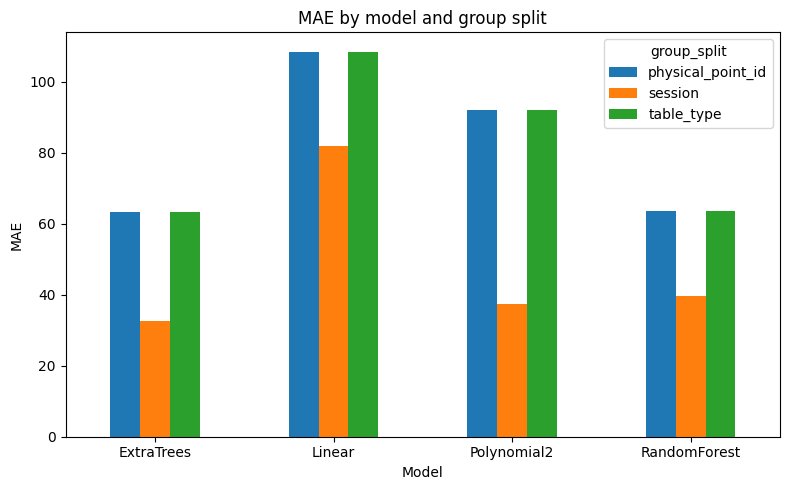

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/plot_mae_by_model_and_group_split.png


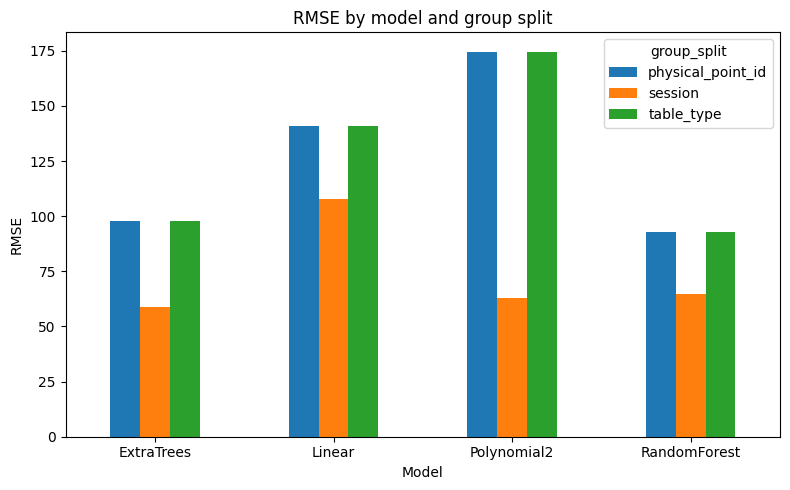

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/plot_rmse_by_model_and_group_split.png


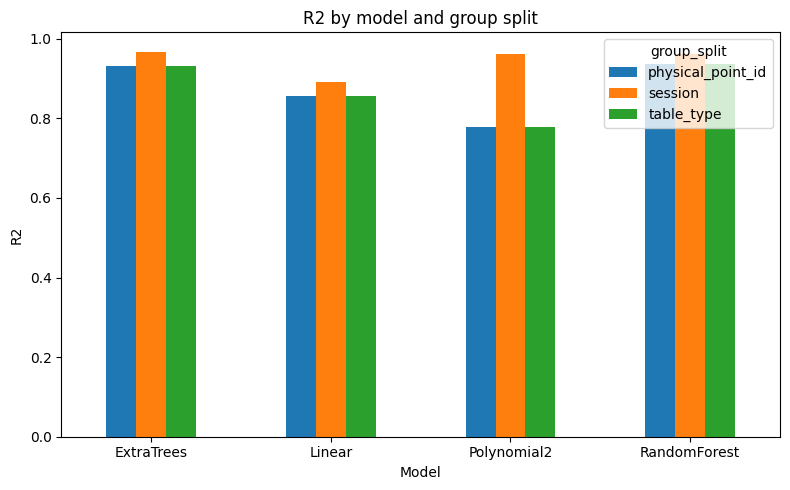

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/plot_r2_by_model_and_group_split.png


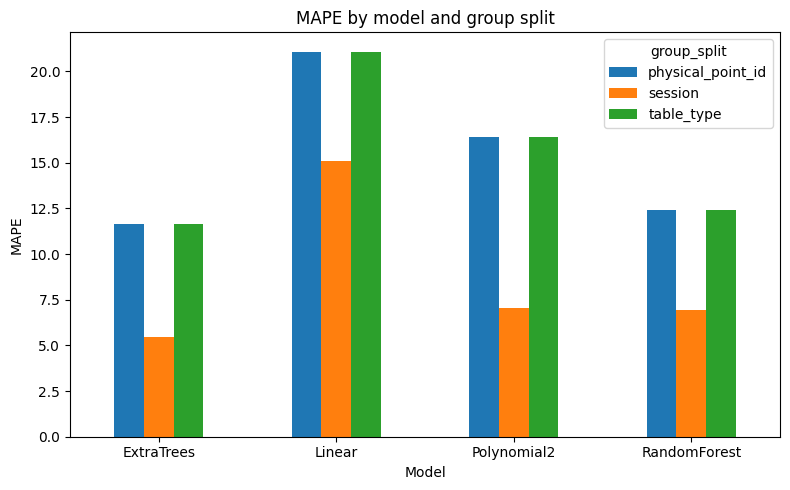

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/plot_mape_by_model_and_group_split.png


In [ ]:
# =========================================================
# VISUALIZE CURRENT GROUP-SPLIT RESULTS
# =========================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/classical_models_group_split_comparison.csv")
OUT_DIR = CSV_PATH.parent

df = pd.read_csv(CSV_PATH)

print(df)

metrics = ["MAE", "RMSE", "R2", "MAPE"]

for metric in metrics:
    pivot = df.pivot(index="model", columns="group_split", values=metric)

    ax = pivot.plot(kind="bar", figsize=(8, 5))
    ax.set_title(f"{metric} by model and group split")
    ax.set_ylabel(metric)
    ax.set_xlabel("Model")
    plt.xticks(rotation=0)
    plt.tight_layout()

    out_path = OUT_DIR / f"plot_{metric.lower()}_by_model_and_group_split.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [ ]:
# =========================================================
# CLASSICAL MODELS ON GROUPED SPLITS
# WHITE PAPER ONLY + TABLE ONLY
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37_with_pointid.csv")
OUT_CSV = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/classical_models_group_split_by_subset.csv")

df = pd.read_csv(MASTER_PATH, low_memory=False)

feature_cols = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std",
    "UL_mean_luma", "UR_mean_luma", "LR_mean_luma", "LL_mean_luma",
    "UL_grad_mean", "UR_grad_mean", "LR_grad_mean", "LL_grad_mean",
    "corner_mean_luma", "corner_std_luma", "corner_range_luma",
    "C_minus_corner_mean_luma", "C_over_corner_mean_luma",
    "C_minus_UL_luma", "C_minus_UR_luma", "C_minus_LR_luma", "C_minus_LL_luma",
    "square_mean_luma", "square_std_luma", "square_grad_mean", "square_grad_std",
    "square_mean_sat_proxy",
    "square_top_mean_luma", "square_bottom_mean_luma",
    "square_left_mean_luma", "square_right_mean_luma",
    "square_center_cell_mean_luma", "square_corner_cells_mean_luma",
    "square_bottom_minus_top_luma", "square_right_minus_left_luma",
    "square_center_minus_corners_luma",
    "square_grid_range_mean_luma", "square_grid_std_mean_luma",
]
feature_cols = [c for c in feature_cols if c in df.columns]

target_cols = ["lux_C", "lux_UL", "lux_UR", "lux_LR", "lux_LL"]

models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Polynomial2": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", LinearRegression())
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
}

def calc_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0),
    }

results = []

subset_defs = {
    "white_paper_only": "white_paper",
    "table_only": "table",
}

for subset_name, subset_value in subset_defs.items():
    sub = df[df["surface_group_norm"] == subset_value].copy()

    required_cols = feature_cols + target_cols
    sub = sub.dropna(subset=required_cols).copy()
    sub["mean_lux"] = sub[target_cols].mean(axis=1)

    print("\n" + "=" * 80)
    print("SUBSET:", subset_name)
    print("Rows:", len(sub))

    if len(sub) < 20:
        print("Too few rows, skipping.")
        continue

    X = sub[feature_cols].values
    y = sub["mean_lux"].values

    for group_col in ["session", "physical_point_id", "table_type"]:
        if group_col not in sub.columns:
            continue

        groups = sub[group_col].astype(str).values
        if len(pd.Series(groups).unique()) < 2:
            print(f"Skipping {subset_name} / {group_col}: not enough unique groups")
            continue

        splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(splitter.split(X, y, groups=groups))

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        print(f"\nSubset={subset_name} | Group split={group_col}")
        print("Train:", len(train_idx), "Test:", len(test_idx))

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            m = calc_metrics(y_test, pred)
            row = {
                "subset": subset_name,
                "group_split": group_col,
                "model": model_name,
                "train_n": len(train_idx),
                "test_n": len(test_idx),
                **m
            }
            results.append(row)

            print(
                f"{model_name:12s} | "
                f"MAE={m['MAE']:.3f} | RMSE={m['RMSE']:.3f} | "
                f"R2={m['R2']:.4f} | MAPE={m['MAPE']:.3f}"
            )

results_df = pd.DataFrame(results)
results_df.to_csv(OUT_CSV, index=False)

print("\nSaved:", OUT_CSV)
display(results_df.sort_values(["subset", "group_split", "MAE"]))


SUBSET: white_paper_only
Rows: 708

Subset=white_paper_only | Group split=session
Train: 566 Test: 142
Linear       | MAE=62.793 | RMSE=80.031 | R2=0.9351 | MAPE=16.449
Polynomial2  | MAE=89.293 | RMSE=207.891 | R2=0.5623 | MAPE=18.432
RandomForest | MAE=20.006 | RMSE=28.286 | R2=0.9919 | MAPE=3.481
ExtraTrees   | MAE=17.187 | RMSE=23.774 | R2=0.9943 | MAPE=2.894

Subset=white_paper_only | Group split=physical_point_id
Train: 564 Test: 144
Linear       | MAE=71.464 | RMSE=105.543 | R2=0.9192 | MAPE=17.692
Polynomial2  | MAE=67.534 | RMSE=115.091 | R2=0.9039 | MAPE=16.414
RandomForest | MAE=26.516 | RMSE=46.348 | R2=0.9844 | MAPE=3.724
ExtraTrees   | MAE=26.040 | RMSE=47.312 | R2=0.9838 | MAPE=3.487

Subset=white_paper_only | Group split=table_type
Train: 564 Test: 144
Linear       | MAE=71.464 | RMSE=105.543 | R2=0.9192 | MAPE=17.692
Polynomial2  | MAE=67.534 | RMSE=115.091 | R2=0.9039 | MAPE=16.414
RandomForest | MAE=26.516 | RMSE=46.348 | R2=0.9844 | MAPE=3.724
ExtraTrees   | MAE=26

,subset,group_split,model,train_n,test_n,MAE,RMSE,R2,MAPE
16,table_only,physical_point_id,Linear,496,153,83.057652,99.486481,0.927127,18.059707
19,table_only,physical_point_id,ExtraTrees,496,153,99.232669,130.278112,0.875038,17.407911
18,table_only,physical_point_id,RandomForest,496,153,101.933869,128.347095,0.878715,19.009291
17,table_only,physical_point_id,Polynomial2,496,153,278.551538,401.653199,-0.187787,43.177581
15,table_only,session,ExtraTrees,519,130,36.082265,53.941821,0.968613,7.137400
12,table_only,session,Linear,519,130,48.252915,62.223460,0.958235,12.001296
14,table_only,session,RandomForest,519,130,49.368373,68.585081,0.949259,9.518441
13,table_only,session,Polynomial2,519,130,53.881806,96.467896,0.899615,10.368078
20,table_only,table_type,Linear,496,153,83.057652,99.486481,0.927127,18.059707
23,table_only,table_type,ExtraTrees,496,153,99.232669,130.278112,0.875038,17.407911


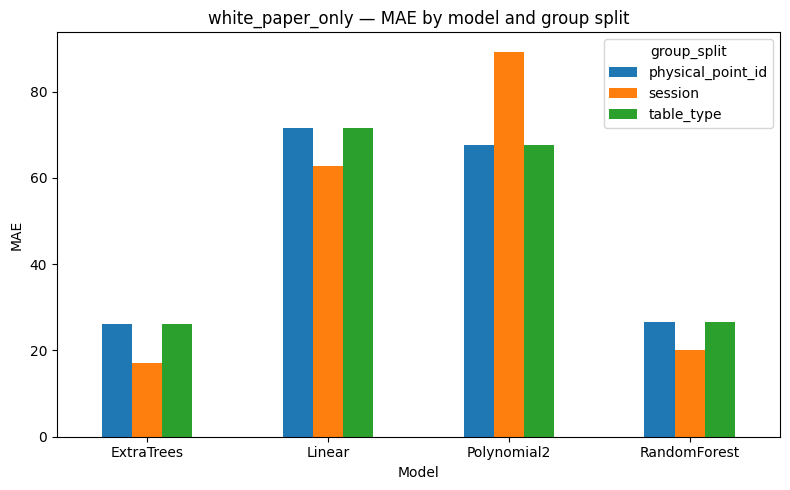

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/white_paper_only_mae_by_model_and_group_split.png


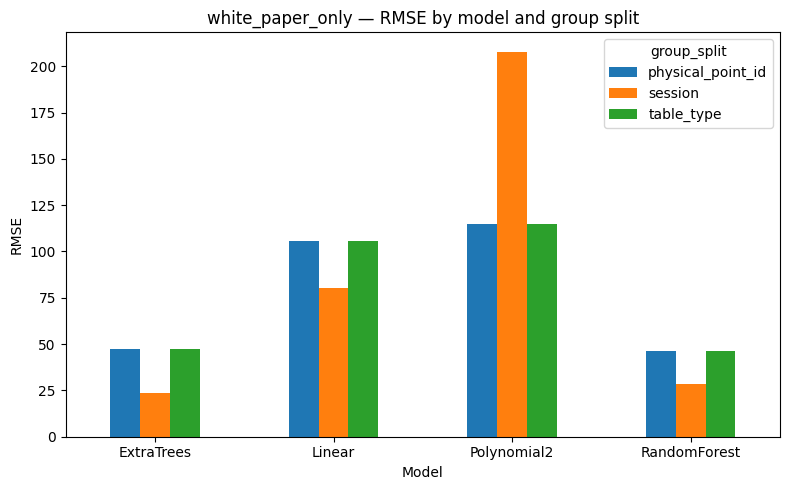

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/white_paper_only_rmse_by_model_and_group_split.png


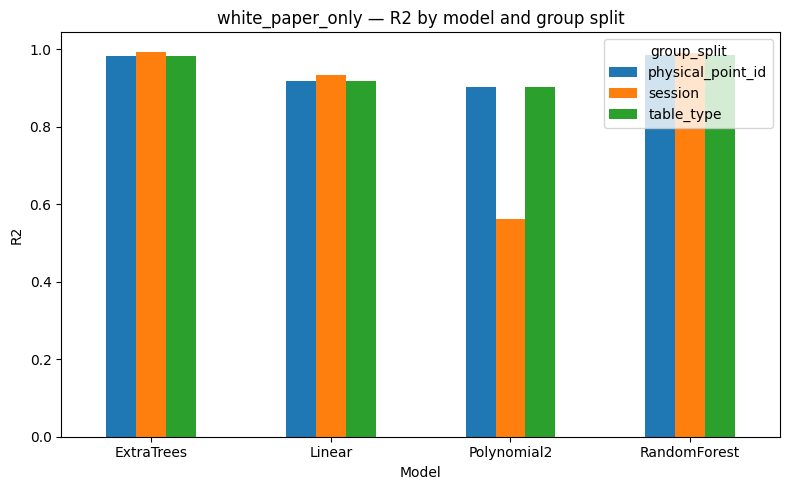

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/white_paper_only_r2_by_model_and_group_split.png


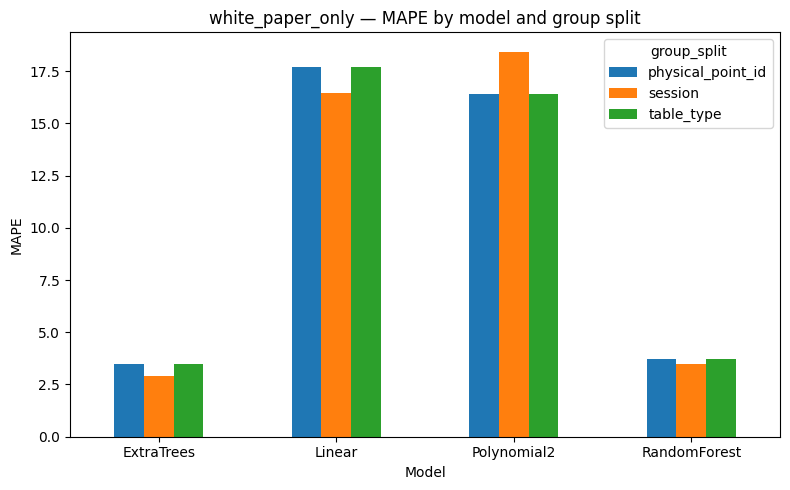

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/white_paper_only_mape_by_model_and_group_split.png


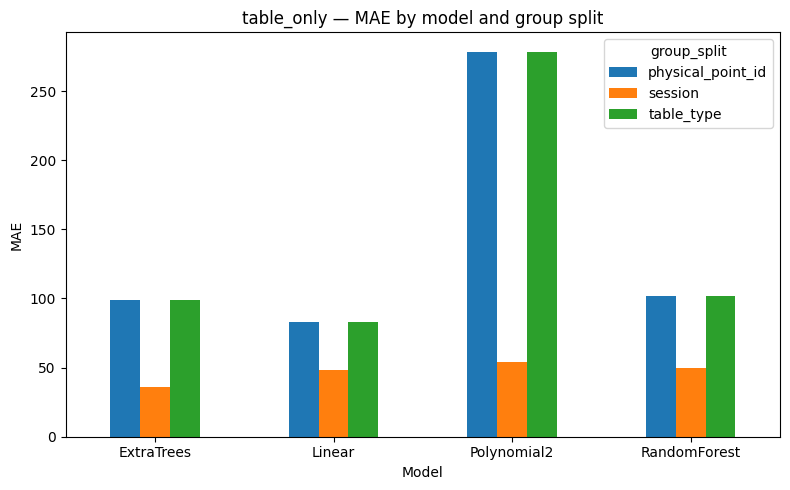

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/table_only_mae_by_model_and_group_split.png


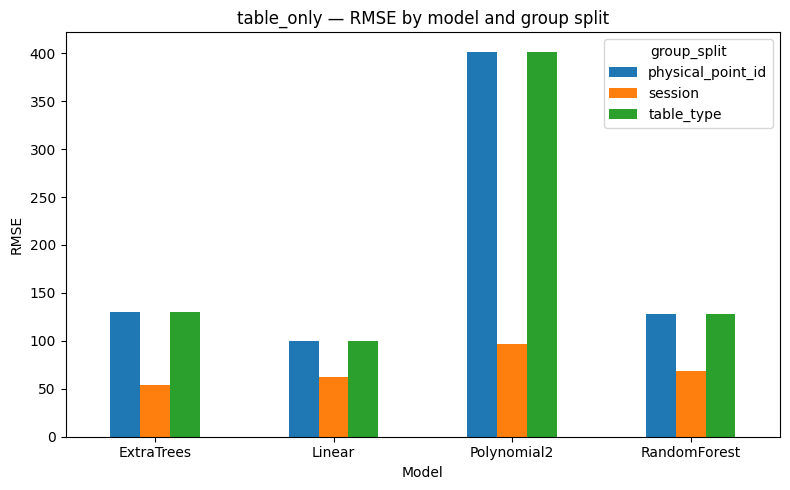

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/table_only_rmse_by_model_and_group_split.png


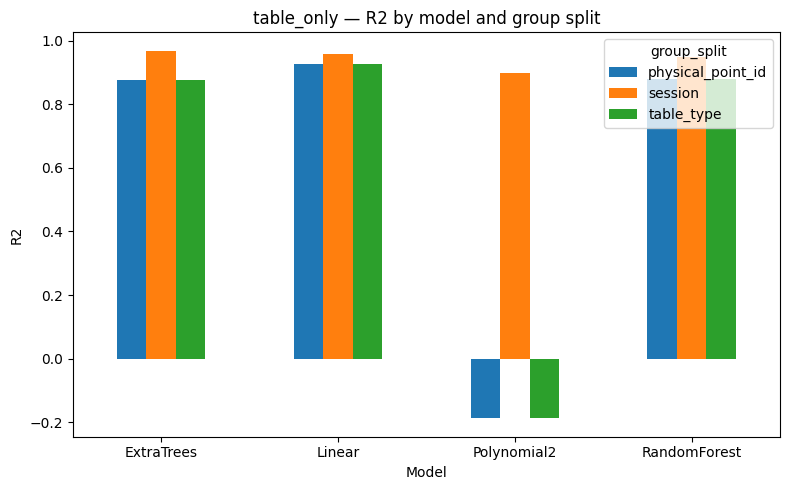

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/table_only_r2_by_model_and_group_split.png


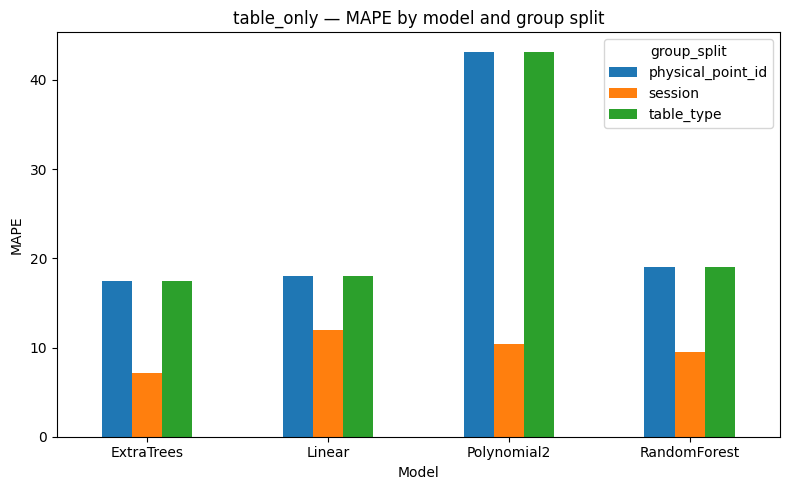

Saved: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/table_only_mape_by_model_and_group_split.png


In [ ]:
# =========================================================
# VISUALIZE WHITE PAPER ONLY / TABLE ONLY RESULTS
# =========================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/classical_models_group_split_by_subset.csv")
OUT_DIR = CSV_PATH.parent

df = pd.read_csv(CSV_PATH)

metrics = ["MAE", "RMSE", "R2", "MAPE"]

for subset_name in df["subset"].unique():
    sub = df[df["subset"] == subset_name].copy()

    for metric in metrics:
        pivot = sub.pivot(index="model", columns="group_split", values=metric)

        ax = pivot.plot(kind="bar", figsize=(8, 5))
        ax.set_title(f"{subset_name} — {metric} by model and group split")
        ax.set_ylabel(metric)
        ax.set_xlabel("Model")
        plt.xticks(rotation=0)
        plt.tight_layout()

        out_path = OUT_DIR / f"{subset_name}_{metric.lower()}_by_model_and_group_split.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved:", out_path)

In [ ]:
# =========================================================
# PAIRED TABLE + WHITE PAPER EXPERIMENT
# ---------------------------------------------------------
# Predict table mean lux using:
#   1) table-only features
#   2) table + matched white-paper features + diff/ratio features
#
# Pairing rule:
#   same session + same physical_point_id
#
# Models:
#   ExtraTrees, RandomForest
#
# Splits:
#   session
#   physical_point_id
#   table_type
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37_with_pointid.csv")
OUT_DIR = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PAIRED_CSV = OUT_DIR / "paired_table_whitepaper_dataset.csv"
OUT_RESULTS_CSV = OUT_DIR / "paired_table_whitepaper_results.csv"

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
df = pd.read_csv(MASTER_PATH, low_memory=False)

print("Loaded rows:", len(df))

# ---------------------------------------------------------
# REQUIRED COLUMNS
# ---------------------------------------------------------
needed_id_cols = ["session", "physical_point_id", "surface_group_norm"]
for c in needed_id_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

# target = mean lux
target_cols = ["lux_C", "lux_UL", "lux_UR", "lux_LR", "lux_LL"]
missing_target_cols = [c for c in target_cols if c not in df.columns]
if missing_target_cols:
    raise ValueError(f"Missing target columns: {missing_target_cols}")

df = df.dropna(subset=target_cols).copy()
df["mean_lux"] = df[target_cols].mean(axis=1)

# ---------------------------------------------------------
# FEATURE COLUMNS
# ---------------------------------------------------------
base_feature_cols = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std",
    "UL_mean_luma", "UR_mean_luma", "LR_mean_luma", "LL_mean_luma",
    "UL_grad_mean", "UR_grad_mean", "LR_grad_mean", "LL_grad_mean",
    "corner_mean_luma", "corner_std_luma", "corner_range_luma",
    "C_minus_corner_mean_luma", "C_over_corner_mean_luma",
    "C_minus_UL_luma", "C_minus_UR_luma", "C_minus_LR_luma", "C_minus_LL_luma",
    "square_mean_luma", "square_std_luma", "square_grad_mean", "square_grad_std",
    "square_mean_sat_proxy",
    "square_top_mean_luma", "square_bottom_mean_luma",
    "square_left_mean_luma", "square_right_mean_luma",
    "square_center_cell_mean_luma", "square_corner_cells_mean_luma",
    "square_bottom_minus_top_luma", "square_right_minus_left_luma",
    "square_center_minus_corners_luma",
    "square_grid_range_mean_luma", "square_grid_std_mean_luma",
]
base_feature_cols = [c for c in base_feature_cols if c in df.columns]

print("Base feature count:", len(base_feature_cols))

# ---------------------------------------------------------
# KEEP ONLY TABLE + WHITE PAPER ROWS
# ---------------------------------------------------------
df2 = df[df["surface_group_norm"].isin(["table", "white_paper"])].copy()

# drop rows with missing features
df2 = df2.dropna(subset=base_feature_cols).copy()

print("Rows after filter:", len(df2))
print(df2["surface_group_norm"].value_counts())

# ---------------------------------------------------------
# SPLIT INTO TABLE / WHITE PAPER
# ---------------------------------------------------------
table_df = df2[df2["surface_group_norm"] == "table"].copy()
wp_df = df2[df2["surface_group_norm"] == "white_paper"].copy()

# columns to carry through
id_cols = [c for c in ["session", "physical_point_id", "table_type", "table", "filename", "image_path"] if c in df2.columns]

table_keep = id_cols + ["mean_lux"] + base_feature_cols
wp_keep = id_cols + ["mean_lux"] + base_feature_cols

table_df = table_df[table_keep].copy()
wp_df = wp_df[wp_keep].copy()

# rename
table_df = table_df.rename(columns={c: f"tbl_{c}" for c in ["mean_lux"] + base_feature_cols})
wp_df = wp_df.rename(columns={c: f"wp_{c}" for c in ["mean_lux"] + base_feature_cols})

# keep join keys unprefixed
# ensure keys exist in both
join_keys = ["session", "physical_point_id"]
for k in join_keys:
    if k not in table_df.columns or k not in wp_df.columns:
        raise ValueError(f"Missing join key: {k}")

# ---------------------------------------------------------
# PAIR TABLE WITH WHITE PAPER
# same session + same physical_point_id
# ---------------------------------------------------------
paired = table_df.merge(
    wp_df,
    on=join_keys,
    how="inner",
    suffixes=("", "_wpdup")
)

print("\nPaired rows:", len(paired))

# remove duplicate metadata columns from wp side if they appeared
dup_cols = [c for c in paired.columns if c.endswith("_wpdup")]
if dup_cols:
    paired = paired.drop(columns=dup_cols)

# ---------------------------------------------------------
# CREATE DIFF / RATIO FEATURES
# table vs white paper
# ---------------------------------------------------------
paired_feature_cols = []

# baseline table-only features
table_feature_cols = [f"tbl_{c}" for c in base_feature_cols]
paired_feature_cols.extend(table_feature_cols)

# add white-paper features
wp_feature_cols = [f"wp_{c}" for c in base_feature_cols]
paired_feature_cols.extend(wp_feature_cols)

# add diff/ratio features
for c in base_feature_cols:
    tc = f"tbl_{c}"
    wc = f"wp_{c}"
    diff_col = f"diff_{c}"
    ratio_col = f"ratio_{c}"

    paired[diff_col] = paired[tc] - paired[wc]
    paired[ratio_col] = paired[tc] / np.maximum(np.abs(paired[wc]), 1e-6)

    paired_feature_cols.append(diff_col)
    paired_feature_cols.append(ratio_col)

# target = table mean lux
paired["target_mean_lux"] = paired["tbl_mean_lux"]

# carry a grouping table_type if available
if "table_type" not in paired.columns:
    if "table" in paired.columns:
        paired["table_type"] = paired["table"]
    elif "tbl_table_type" in paired.columns:
        paired["table_type"] = paired["tbl_table_type"]

paired.to_csv(OUT_PAIRED_CSV, index=False)
print("Saved paired dataset to:", OUT_PAIRED_CSV)

# ---------------------------------------------------------
# MODELS
# ---------------------------------------------------------
models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
}

def calc_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0),
    }

# ---------------------------------------------------------
# EVALUATE
# compare:
#   A) table-only features
#   B) paired features
# ---------------------------------------------------------
results = []

feature_sets = {
    "table_only_baseline": table_feature_cols,
    "paired_table_plus_whitepaper": paired_feature_cols,
}

for group_col in ["session", "physical_point_id", "table_type"]:
    if group_col not in paired.columns:
        print(f"Skipping missing group column: {group_col}")
        continue

    groups = paired[group_col].astype(str).values
    X_dict = {
        name: paired[cols].values
        for name, cols in feature_sets.items()
    }
    y = paired["target_mean_lux"].values

    # need at least 2 groups
    if len(pd.Series(groups).unique()) < 2:
        print(f"Skipping {group_col}: not enough unique groups")
        continue

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(np.zeros((len(y), 1)), y, groups=groups))

    print("\n" + "=" * 90)
    print(f"GROUP SPLIT: {group_col}")
    print("Train:", len(train_idx), "Test:", len(test_idx))

    for feat_name, X in X_dict.items():
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            m = calc_metrics(y_test, pred)
            row = {
                "group_split": group_col,
                "feature_set": feat_name,
                "model": model_name,
                "train_n": len(train_idx),
                "test_n": len(test_idx),
                **m
            }
            results.append(row)

            print(
                f"{feat_name:28s} | {model_name:12s} | "
                f"MAE={m['MAE']:.3f} | RMSE={m['RMSE']:.3f} | "
                f"R2={m['R2']:.4f} | MAPE={m['MAPE']:.3f}"
            )

results_df = pd.DataFrame(results)
results_df.to_csv(OUT_RESULTS_CSV, index=False)

print("\nSaved results to:", OUT_RESULTS_CSV)
display(results_df.sort_values(["group_split", "model", "MAE"]))

Loaded rows: 3157
Base feature count: 37
Rows after filter: 1357
surface_group_norm
white_paper    708
table          649
Name: count, dtype: int64

Paired rows: 625
Saved paired dataset to: /content/drive/MyDrive/AI_Lux_Project/Experiments_4/paired_table_whitepaper_dataset.csv

GROUP SPLIT: session
Train: 500 Test: 125
table_only_baseline          | RandomForest | MAE=50.222 | RMSE=75.036 | R2=0.9454 | MAPE=8.524
table_only_baseline          | ExtraTrees   | MAE=39.809 | RMSE=62.217 | R2=0.9625 | MAPE=6.904
paired_table_plus_whitepaper | RandomForest | MAE=19.281 | RMSE=28.216 | R2=0.9923 | MAPE=3.017
paired_table_plus_whitepaper | ExtraTrees   | MAE=15.803 | RMSE=24.200 | R2=0.9943 | MAPE=2.454

GROUP SPLIT: physical_point_id
Train: 472 Test: 153
table_only_baseline          | RandomForest | MAE=97.248 | RMSE=125.757 | R2=0.8836 | MAPE=17.765
table_only_baseline          | ExtraTrees   | MAE=97.578 | RMSE=128.786 | R2=0.8779 | MAPE=17.045
paired_table_plus_whitepaper | RandomForest |

,group_split,feature_set,model,train_n,test_n,MAE,RMSE,R2,MAPE
7,physical_point_id,paired_table_plus_whitepaper,ExtraTrees,472,153,25.052018,48.694493,0.982542,3.311267
5,physical_point_id,table_only_baseline,ExtraTrees,472,153,97.578476,128.785723,0.877884,17.044765
6,physical_point_id,paired_table_plus_whitepaper,RandomForest,472,153,27.208739,47.126491,0.983648,4.092328
4,physical_point_id,table_only_baseline,RandomForest,472,153,97.248085,125.757249,0.883560,17.764875
3,session,paired_table_plus_whitepaper,ExtraTrees,500,125,15.803350,24.199674,0.994325,2.454189
1,session,table_only_baseline,ExtraTrees,500,125,39.808739,62.217299,0.962489,6.903905
2,session,paired_table_plus_whitepaper,RandomForest,500,125,19.280512,28.216121,0.992285,3.016504
0,session,table_only_baseline,RandomForest,500,125,50.221872,75.036053,0.945440,8.523686
11,table_type,paired_table_plus_whitepaper,ExtraTrees,472,153,25.052018,48.694493,0.982542,3.311267
9,table_type,table_only_baseline,ExtraTrees,472,153,97.578476,128.785723,0.877884,17.044765


In [ ]:
# =========================================================
# COMPARE:
# 1) table-only
# 2) white-paper-only
# 3) paired table + white-paper
# on the same paired dataset
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PAIRED_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/paired_table_whitepaper_dataset.csv")
OUT_CSV = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/table_vs_whitepaper_vs_paired_results.csv")

paired = pd.read_csv(PAIRED_PATH, low_memory=False)

print("Paired rows:", len(paired))

# ---------------------------------------------------------
# identify feature sets
# ---------------------------------------------------------
tbl_feature_cols = [c for c in paired.columns if c.startswith("tbl_") and c not in ["tbl_mean_lux"]]
wp_feature_cols = [c for c in paired.columns if c.startswith("wp_") and c not in ["wp_mean_lux"]]

diff_ratio_cols = [c for c in paired.columns if c.startswith("diff_") or c.startswith("ratio_")]

feature_sets = {
    "table_only": tbl_feature_cols,
    "whitepaper_only": wp_feature_cols,
    "paired_table_plus_whitepaper": tbl_feature_cols + wp_feature_cols + diff_ratio_cols,
}

print("table_only features:", len(feature_sets["table_only"]))
print("whitepaper_only features:", len(feature_sets["whitepaper_only"]))
print("paired features:", len(feature_sets["paired_table_plus_whitepaper"]))

# ---------------------------------------------------------
# target = table mean lux
# ---------------------------------------------------------
if "target_mean_lux" not in paired.columns:
    if "tbl_mean_lux" in paired.columns:
        paired["target_mean_lux"] = paired["tbl_mean_lux"]
    else:
        raise ValueError("Missing target_mean_lux / tbl_mean_lux")

y = paired["target_mean_lux"].values

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
}

def calc_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0),
    }

results = []

for group_col in ["session", "physical_point_id", "table_type"]:
    if group_col not in paired.columns:
        print(f"Skipping missing group column: {group_col}")
        continue

    groups = paired[group_col].astype(str).values

    if len(pd.Series(groups).unique()) < 2:
        print(f"Skipping {group_col}: not enough unique groups")
        continue

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(np.zeros((len(y), 1)), y, groups=groups))

    print("\n" + "=" * 90)
    print(f"GROUP SPLIT: {group_col}")
    print("Train:", len(train_idx), "Test:", len(test_idx))

    y_train, y_test = y[train_idx], y[test_idx]

    for feat_name, cols in feature_sets.items():
        X = paired[cols].values
        X_train, X_test = X[train_idx], X[test_idx]

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            m = calc_metrics(y_test, pred)
            row = {
                "group_split": group_col,
                "feature_set": feat_name,
                "model": model_name,
                "train_n": len(train_idx),
                "test_n": len(test_idx),
                **m
            }
            results.append(row)

            print(
                f"{feat_name:28s} | {model_name:12s} | "
                f"MAE={m['MAE']:.3f} | RMSE={m['RMSE']:.3f} | "
                f"R2={m['R2']:.4f} | MAPE={m['MAPE']:.3f}"
            )

results_df = pd.DataFrame(results)
results_df.to_csv(OUT_CSV, index=False)

print("\nSaved results to:", OUT_CSV)
display(results_df.sort_values(["group_split", "model", "MAE"]))

Paired rows: 625
table_only features: 37
whitepaper_only features: 37
paired features: 148

GROUP SPLIT: session
Train: 500 Test: 125
table_only                   | RandomForest | MAE=50.222 | RMSE=75.036 | R2=0.9454 | MAPE=8.524
table_only                   | ExtraTrees   | MAE=39.809 | RMSE=62.217 | R2=0.9625 | MAPE=6.904
whitepaper_only              | RandomForest | MAE=19.902 | RMSE=28.519 | R2=0.9921 | MAPE=3.129
whitepaper_only              | ExtraTrees   | MAE=17.327 | RMSE=26.306 | R2=0.9933 | MAPE=2.704
paired_table_plus_whitepaper | RandomForest | MAE=19.281 | RMSE=28.216 | R2=0.9923 | MAPE=3.017
paired_table_plus_whitepaper | ExtraTrees   | MAE=15.803 | RMSE=24.200 | R2=0.9943 | MAPE=2.454

GROUP SPLIT: physical_point_id
Train: 472 Test: 153
table_only                   | RandomForest | MAE=97.248 | RMSE=125.757 | R2=0.8836 | MAPE=17.765
table_only                   | ExtraTrees   | MAE=97.578 | RMSE=128.786 | R2=0.8779 | MAPE=17.045
whitepaper_only              | RandomFore

,group_split,feature_set,model,train_n,test_n,MAE,RMSE,R2,MAPE
11,physical_point_id,paired_table_plus_whitepaper,ExtraTrees,472,153,25.052018,48.694493,0.982542,3.311267
9,physical_point_id,whitepaper_only,ExtraTrees,472,153,25.574254,47.204454,0.983594,3.385610
7,physical_point_id,table_only,ExtraTrees,472,153,97.578476,128.785723,0.877884,17.044765
8,physical_point_id,whitepaper_only,RandomForest,472,153,26.898317,45.510449,0.984750,4.025370
10,physical_point_id,paired_table_plus_whitepaper,RandomForest,472,153,27.208739,47.126491,0.983648,4.092328
6,physical_point_id,table_only,RandomForest,472,153,97.248085,125.757249,0.883560,17.764875
5,session,paired_table_plus_whitepaper,ExtraTrees,500,125,15.803350,24.199674,0.994325,2.454189
3,session,whitepaper_only,ExtraTrees,500,125,17.327360,26.306382,0.993294,2.703827
1,session,table_only,ExtraTrees,500,125,39.808739,62.217299,0.962489,6.903905
4,session,paired_table_plus_whitepaper,RandomForest,500,125,19.280512,28.216121,0.992285,3.016504


In [ ]:
from pathlib import Path
import os
import time

paths = [
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_3/annotations/annotation_master_current.csv",
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_3/fixed_parser_refresh/annotation_master_fixed.csv",
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_3/fixed_parser_refresh/extracted_features_refresh_5roi_fullcontext_fixed.csv",
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_clean_from_existing_5point_cache.csv",
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37.csv",
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_4/F033_fix/F033_corrected_annotation_rows.csv",
    "/content/drive/MyDrive/AI_Lux_Project/Experiments_4/F033_fix/F033_corrected_features.csv",
]

for p in paths:
    if os.path.exists(p):
        mtime = os.path.getmtime(p)
        print(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(mtime)), " | ", p)
    else:
        print("MISSING |", p)

2026-04-20 08:10:42  |  /content/drive/MyDrive/AI_Lux_Project/Experiments_3/annotations/annotation_master_current.csv
2026-04-20 08:10:42  |  /content/drive/MyDrive/AI_Lux_Project/Experiments_3/fixed_parser_refresh/annotation_master_fixed.csv
2026-04-20 08:13:00  |  /content/drive/MyDrive/AI_Lux_Project/Experiments_3/fixed_parser_refresh/extracted_features_refresh_5roi_fullcontext_fixed.csv
2026-04-20 08:13:03  |  /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_clean_from_existing_5point_cache.csv
2026-04-20 08:13:02  |  /content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37.csv
2026-04-20 08:02:02  |  /content/drive/MyDrive/AI_Lux_Project/Experiments_4/F033_fix/F033_corrected_annotation_rows.csv
2026-04-20 08:11:58  |  /content/drive/MyDrive/AI_Lux_Project/Experiments_4/F033_fix/F033_corrected_features.csv


In [ ]:
from pathlib import Path

root = Path("/content/drive/MyDrive/AI_Lux_Project")

for p in sorted(root.rglob("*.csv")):
    name = p.name.lower()
    if "annotation" in name or "feature" in name or "enriched" in name:
        print(p)

/content/drive/MyDrive/AI_Lux_Project/Database/annotations_long.csv
/content/drive/MyDrive/AI_Lux_Project/Database/annotations_long_TRAIN.csv
/content/drive/MyDrive/AI_Lux_Project/Database/annotations_long_updated.csv
/content/drive/MyDrive/AI_Lux_Project/Database/annotations_wide.csv
/content/drive/MyDrive/AI_Lux_Project/Database/annotations_wide_TRAIN.csv
/content/drive/MyDrive/AI_Lux_Project/Experiments_1/cache/features_all.csv
/content/drive/MyDrive/AI_Lux_Project/Experiments_1/material_feature_plots/roi_material_features.csv
/content/drive/MyDrive/AI_Lux_Project/Experiments_2/results/rf_feature_importance.csv
/content/drive/MyDrive/AI_Lux_Project/Experiments_2/tables/feature_table_center_only.csv
/content/drive/MyDrive/AI_Lux_Project/Experiments_2/tables/feature_table_exp2_d64_d128.csv
/content/drive/MyDrive/AI_Lux_Project/Experiments_3/annotations/annotation_master_current.csv
/content/drive/MyDrive/AI_Lux_Project/Experiments_3/annotations/annotation_roi_128_current.csv
/content/

In [ ]:
# =========================================================
# CLASSICAL BENCHMARK ACROSS INPUT VARIANTS
# ---------------------------------------------------------
# Variants:
# 1) center_only
# 2) roi5_only
# 3) roi5_plus_square
# 4) roi5_plus_square_plus_features (same as full set here)
#
# Models:
# - ExtraTrees
# - RandomForest
#
# Splits:
# - session
# - physical_point_id
# - table_type
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37_with_pointid.csv")
OUT_CSV = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/benchmark_input_variants_classical.csv")

df = pd.read_csv(MASTER_PATH, low_memory=False)

# use white paper + table for now
df = df[df["surface_group_norm"].isin(["white_paper", "table"])].copy()

target_cols = ["lux_C", "lux_UL", "lux_UR", "lux_LR", "lux_LL"]
df = df.dropna(subset=target_cols).copy()
df["mean_lux"] = df[target_cols].mean(axis=1)

# ---------------------------------------------------------
# define feature groups
# ---------------------------------------------------------
center_only = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std"
]

roi5_only = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std",
    "UL_mean_luma", "UR_mean_luma", "LR_mean_luma", "LL_mean_luma",
    "UL_grad_mean", "UR_grad_mean", "LR_grad_mean", "LL_grad_mean",
    "corner_mean_luma", "corner_std_luma", "corner_range_luma",
    "C_minus_corner_mean_luma", "C_over_corner_mean_luma",
    "C_minus_UL_luma", "C_minus_UR_luma", "C_minus_LR_luma", "C_minus_LL_luma",
]

roi5_plus_square = roi5_only + [
    "square_mean_luma", "square_std_luma", "square_grad_mean", "square_grad_std",
    "square_mean_sat_proxy",
    "square_top_mean_luma", "square_bottom_mean_luma",
    "square_left_mean_luma", "square_right_mean_luma",
    "square_center_cell_mean_luma", "square_corner_cells_mean_luma",
    "square_bottom_minus_top_luma", "square_right_minus_left_luma",
    "square_center_minus_corners_luma",
    "square_grid_range_mean_luma", "square_grid_std_mean_luma",
]

full37 = roi5_plus_square

feature_sets = {
    "center_only": [c for c in center_only if c in df.columns],
    "roi5_only": [c for c in roi5_only if c in df.columns],
    "roi5_plus_square": [c for c in roi5_plus_square if c in df.columns],
    "roi5_plus_square_plus_features": [c for c in full37 if c in df.columns],
}

models = {
    "RandomForest": RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=500, random_state=42, n_jobs=-1),
}

def calc_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100.0),
    }

results = []

for split_col in ["session", "physical_point_id", "table_type"]:
    if split_col not in df.columns:
        continue

    groups = df[split_col].astype(str).values
    y = df["mean_lux"].values

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

    for feat_name, feat_cols in feature_sets.items():
        sub = df.dropna(subset=feat_cols).copy()
        X = sub[feat_cols].values
        y_sub = sub["mean_lux"].values
        groups_sub = sub[split_col].astype(str).values

        if len(pd.Series(groups_sub).unique()) < 2:
            continue

        train_idx, test_idx = next(splitter.split(X, y_sub, groups=groups_sub))
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        print(f"\nSPLIT={split_col} | FEATURES={feat_name} | train={len(train_idx)} test={len(test_idx)}")

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            m = calc_metrics(y_test, pred)

            row = {
                "split": split_col,
                "feature_set": feat_name,
                "model": model_name,
                "train_n": len(train_idx),
                "test_n": len(test_idx),
                **m
            }
            results.append(row)

            print(
                f"{model_name:12s} | MAE={m['MAE']:.3f} | RMSE={m['RMSE']:.3f} | "
                f"R2={m['R2']:.4f} | MAPE={m['MAPE']:.3f}"
            )

results_df = pd.DataFrame(results)
results_df.to_csv(OUT_CSV, index=False)

print("\nSaved:", OUT_CSV)
display(results_df.sort_values(["split", "MAE"]))


SPLIT=session | FEATURES=center_only | train=1083 test=274
RandomForest | MAE=47.530 | RMSE=75.909 | R2=0.9461 | MAPE=8.434
ExtraTrees   | MAE=43.620 | RMSE=66.691 | R2=0.9584 | MAPE=7.631

SPLIT=session | FEATURES=roi5_only | train=1083 test=274
RandomForest | MAE=41.524 | RMSE=68.492 | R2=0.9561 | MAPE=7.357
ExtraTrees   | MAE=35.808 | RMSE=62.806 | R2=0.9631 | MAPE=6.093

SPLIT=session | FEATURES=roi5_plus_square | train=1083 test=274
RandomForest | MAE=39.617 | RMSE=64.511 | R2=0.9610 | MAPE=6.920
ExtraTrees   | MAE=32.474 | RMSE=58.711 | R2=0.9677 | MAPE=5.464

SPLIT=session | FEATURES=roi5_plus_square_plus_features | train=1083 test=274
RandomForest | MAE=39.617 | RMSE=64.511 | R2=0.9610 | MAPE=6.920
ExtraTrees   | MAE=32.474 | RMSE=58.711 | R2=0.9677 | MAPE=5.464

SPLIT=physical_point_id | FEATURES=center_only | train=1069 test=288
RandomForest | MAE=51.203 | RMSE=77.014 | R2=0.9570 | MAPE=9.869
ExtraTrees   | MAE=49.864 | RMSE=77.107 | R2=0.9569 | MAPE=9.445

SPLIT=physical_po

,split,feature_set,model,train_n,test_n,MAE,RMSE,R2,MAPE
9,physical_point_id,center_only,ExtraTrees,1069,288,49.863683,77.107235,0.956875,9.444958
8,physical_point_id,center_only,RandomForest,1069,288,51.203149,77.013900,0.956979,9.868914
13,physical_point_id,roi5_plus_square,ExtraTrees,1069,288,63.272092,97.889589,0.930495,11.660937
15,physical_point_id,roi5_plus_square_plus_features,ExtraTrees,1069,288,63.272092,97.889589,0.930495,11.660937
14,physical_point_id,roi5_plus_square_plus_features,RandomForest,1069,288,63.692948,92.978940,0.937294,12.406422
12,physical_point_id,roi5_plus_square,RandomForest,1069,288,63.692948,92.978940,0.937294,12.406422
10,physical_point_id,roi5_only,RandomForest,1069,288,66.680405,102.394941,0.923950,12.622958
11,physical_point_id,roi5_only,ExtraTrees,1069,288,71.011711,112.557243,0.908106,13.086692
7,session,roi5_plus_square_plus_features,ExtraTrees,1083,274,32.473698,58.710582,0.967739,5.464406
5,session,roi5_plus_square,ExtraTrees,1083,274,32.473698,58.710582,0.967739,5.464406


In [ ]:
# =========================================================
# CNN BENCHMARK - CONFIGURABLE INPUT VARIANT
# ---------------------------------------------------------
# VARIANT choices:
# - "center_only"
# - "roi5_only"
# - "roi5_plus_square"
# - "roi5_plus_square_plus_features"
#
# Target:
# - mean illuminance
#
# Split:
# - choose one of: session / physical_point_id / table_type
# =========================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37_with_pointid.csv")
OUT_ROOT = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/cnn_variant_benchmarks")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

VARIANT = "roi5_plus_square_plus_features"   # change this
GROUP_SPLIT = "physical_point_id"            # change this

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
BATCH_SIZE = 8
NUM_EPOCHS = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4
ROI_IMG_SIZE = 96
SQUARE_IMG_SIZE = 160

ROI_ORDER = ["C", "UL", "UR", "LR", "LL"]
ROI_SIZES = {"C":256, "UL":128, "UR":128, "LR":128, "LL":128}
ROI_COORDS = {"C":(1520,2027), "UL":(1020,1372), "UR":(2043,1372), "LR":(2030,2722), "LL":(1020,2722)}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
df = pd.read_csv(MASTER_PATH, low_memory=False)
df = df[df["surface_group_norm"].isin(["white_paper", "table"])].copy()

for roi, (x, y) in ROI_COORDS.items():
    if f"x_{roi}" not in df.columns:
        df[f"x_{roi}"] = x
    if f"y_{roi}" not in df.columns:
        df[f"y_{roi}"] = y
    df[f"x_{roi}"] = df[f"x_{roi}"].fillna(x)
    df[f"y_{roi}"] = df[f"y_{roi}"].fillna(y)

target_cols = ["lux_C", "lux_UL", "lux_UR", "lux_LR", "lux_LL"]
df = df.dropna(subset=target_cols).copy()
df["mean_lux"] = df[target_cols].mean(axis=1)

tab_cols = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std",
    "UL_mean_luma", "UR_mean_luma", "LR_mean_luma", "LL_mean_luma",
    "UL_grad_mean", "UR_grad_mean", "LR_grad_mean", "LL_grad_mean",
    "corner_mean_luma", "corner_std_luma", "corner_range_luma",
    "C_minus_corner_mean_luma", "C_over_corner_mean_luma",
    "C_minus_UL_luma", "C_minus_UR_luma", "C_minus_LR_luma", "C_minus_LL_luma",
    "square_mean_luma", "square_std_luma", "square_grad_mean", "square_grad_std",
    "square_mean_sat_proxy",
    "square_top_mean_luma", "square_bottom_mean_luma",
    "square_left_mean_luma", "square_right_mean_luma",
    "square_center_cell_mean_luma", "square_corner_cells_mean_luma",
    "square_bottom_minus_top_luma", "square_right_minus_left_luma",
    "square_center_minus_corners_luma",
    "square_grid_range_mean_luma", "square_grid_std_mean_luma",
]
tab_cols = [c for c in tab_cols if c in df.columns]
df = df.dropna(subset=tab_cols + ["mean_lux"]).copy()

# split
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, df["mean_lux"], groups=df[GROUP_SPLIT].astype(str)))
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# scale features only if used
if VARIANT == "roi5_plus_square_plus_features":
    scaler = StandardScaler()
    train_df.loc[:, tab_cols] = scaler.fit_transform(train_df[tab_cols].values)
    test_df.loc[:, tab_cols] = scaler.transform(test_df[tab_cols].values)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def crop_patch(img, x, y, crop_size):
    half = crop_size // 2
    left = int(round(x - half)); top = int(round(y - half))
    right = left + crop_size; bottom = top + crop_size
    pad_left = max(0, -left); pad_top = max(0, -top)
    pad_right = max(0, right - img.width); pad_bottom = max(0, bottom - img.height)
    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(arr, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), mode="edge")
        img = Image.fromarray(arr)
        left += pad_left; right += pad_left; top += pad_top; bottom += pad_top
    return img.crop((left, top, right, bottom))

def get_square_bbox_from_row(row):
    lefts, rights, tops, bottoms = [], [], [], []
    for roi in ["UL", "UR", "LR", "LL"]:
        x = int(row[f"x_{roi}"]); y = int(row[f"y_{roi}"])
        r = ROI_SIZES[roi] // 2
        lefts.append(x-r); rights.append(x+r); tops.append(y-r); bottoms.append(y+r)
    return min(lefts), min(tops), max(rights), max(bottoms)

def crop_bbox(img, left, top, right, bottom):
    pad_left = max(0, -left); pad_top = max(0, -top)
    pad_right = max(0, right - img.width); pad_bottom = max(0, bottom - img.height)
    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(arr, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), mode="edge")
        img = Image.fromarray(arr)
        left += pad_left; right += pad_left; top += pad_top; bottom += pad_top
    return img.crop((left, top, right, bottom))

def pil_to_tensor(img):
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.transpose(arr, (2, 0, 1))
    return torch.tensor(arr, dtype=torch.float32)

# ---------------------------------------------------------
# DATASET
# ---------------------------------------------------------
class LuxDataset(Dataset):
    def __init__(self, df, variant, tab_cols):
        self.df = df.reset_index(drop=True)
        self.variant = variant
        self.tab_cols = tab_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"])
        img = ImageOps.exif_transpose(img).convert("RGB")

        out = {"target": torch.tensor(float(row["mean_lux"]), dtype=torch.float32)}

        if self.variant == "center_only":
            patch = crop_patch(img, int(row["x_C"]), int(row["y_C"]), ROI_SIZES["C"]).resize((ROI_IMG_SIZE, ROI_IMG_SIZE))
            out["center_img"] = pil_to_tensor(patch)

        elif self.variant in ["roi5_only", "roi5_plus_square", "roi5_plus_square_plus_features"]:
            roi_tensors = []
            for roi in ROI_ORDER:
                patch = crop_patch(img, int(row[f"x_{roi}"]), int(row[f"y_{roi}"]), ROI_SIZES[roi]).resize((ROI_IMG_SIZE, ROI_IMG_SIZE))
                roi_tensors.append(pil_to_tensor(patch))
            out["roi_imgs"] = torch.stack(roi_tensors, dim=0)

        if self.variant in ["roi5_plus_square", "roi5_plus_square_plus_features"]:
            left, top, right, bottom = get_square_bbox_from_row(row)
            sq = crop_bbox(img, left, top, right, bottom).resize((SQUARE_IMG_SIZE, SQUARE_IMG_SIZE))
            out["square_img"] = pil_to_tensor(sq)

        if self.variant == "roi5_plus_square_plus_features":
            out["tabular"] = torch.tensor(row[self.tab_cols].values.astype(np.float32), dtype=torch.float32)

        return out

# ---------------------------------------------------------
# MODELS
# ---------------------------------------------------------
class SmallCNN(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, out_dim)
    def forward(self, x):
        return self.fc(self.features(x).flatten(1))

class CenterOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = SmallCNN(128)
        self.head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, center_img):
        z = self.enc(center_img)
        return self.head(z).squeeze(1)

class ROI5Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = SmallCNN(128)
        self.head = nn.Sequential(nn.Linear(5*128, 128), nn.ReLU(), nn.Linear(128, 1))
    def forward(self, roi_imgs):
        B, N, C, H, W = roi_imgs.shape
        z = self.enc(roi_imgs.view(B*N, C, H, W)).view(B, N, -1).flatten(1)
        return self.head(z).squeeze(1)

class ROI5SquareModel(nn.Module):
    def __init__(self, use_tab=False, n_tab=0):
        super().__init__()
        self.roi_enc = SmallCNN(128)
        self.square_enc = SmallCNN(128)
        self.use_tab = use_tab
        if use_tab:
            self.tab = nn.Sequential(nn.Linear(n_tab, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU())
            in_dim = 5*128 + 128 + 64
        else:
            in_dim = 5*128 + 128
        self.head = nn.Sequential(nn.Linear(in_dim, 256), nn.ReLU(), nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, roi_imgs, square_img, tabular=None):
        B, N, C, H, W = roi_imgs.shape
        z_roi = self.roi_enc(roi_imgs.view(B*N, C, H, W)).view(B, N, -1).flatten(1)
        z_sq = self.square_enc(square_img)
        if self.use_tab:
            z_tab = self.tab(tabular)
            z = torch.cat([z_roi, z_sq, z_tab], dim=1)
        else:
            z = torch.cat([z_roi, z_sq], dim=1)
        return self.head(z).squeeze(1)

# ---------------------------------------------------------
# TRAIN
# ---------------------------------------------------------
train_loader = DataLoader(LuxDataset(train_df, VARIANT, tab_cols), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(DEVICE=="cuda"))
test_loader = DataLoader(LuxDataset(test_df, VARIANT, tab_cols), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE=="cuda"))

if VARIANT == "center_only":
    model = CenterOnlyModel().to(DEVICE)
elif VARIANT == "roi5_only":
    model = ROI5Model().to(DEVICE)
elif VARIANT == "roi5_plus_square":
    model = ROI5SquareModel(use_tab=False).to(DEVICE)
elif VARIANT == "roi5_plus_square_plus_features":
    model = ROI5SquareModel(use_tab=True, n_tab=len(tab_cols)).to(DEVICE)
else:
    raise ValueError("Bad VARIANT")

opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

best_mae = float("inf")
best_state = None

for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    train_losses = []

    for batch in train_loader:
        opt.zero_grad()

        if VARIANT == "center_only":
            pred = model(batch["center_img"].to(DEVICE))
        elif VARIANT == "roi5_only":
            pred = model(batch["roi_imgs"].to(DEVICE))
        elif VARIANT == "roi5_plus_square":
            pred = model(batch["roi_imgs"].to(DEVICE), batch["square_img"].to(DEVICE))
        else:
            pred = model(batch["roi_imgs"].to(DEVICE), batch["square_img"].to(DEVICE), batch["tabular"].to(DEVICE))

        target = batch["target"].to(DEVICE)
        loss = criterion(pred, target)
        loss.backward()
        opt.step()
        train_losses.append(loss.item())

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in test_loader:
            if VARIANT == "center_only":
                pred = model(batch["center_img"].to(DEVICE))
            elif VARIANT == "roi5_only":
                pred = model(batch["roi_imgs"].to(DEVICE))
            elif VARIANT == "roi5_plus_square":
                pred = model(batch["roi_imgs"].to(DEVICE), batch["square_img"].to(DEVICE))
            else:
                pred = model(batch["roi_imgs"].to(DEVICE), batch["square_img"].to(DEVICE), batch["tabular"].to(DEVICE))

            y_pred.extend(pred.cpu().numpy().tolist())
            y_true.extend(batch["target"].numpy().tolist())

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((np.array(y_true)-np.array(y_pred))/np.maximum(np.abs(np.array(y_true)), 1e-8))) * 100.0)

    print(f"epoch {epoch:02d} | loss={np.mean(train_losses):.4f} | MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.4f} | MAPE={mape:.3f}")

    if mae < best_mae:
        best_mae = mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

out_dir = OUT_ROOT / f"{VARIANT}__split_{GROUP_SPLIT}"
out_dir.mkdir(parents=True, exist_ok=True)

summary = pd.DataFrame([{
    "variant": VARIANT,
    "group_split": GROUP_SPLIT,
    "train_n": len(train_df),
    "test_n": len(test_df),
    "best_MAE": best_mae,
}])
summary.to_csv(out_dir / "summary.csv", index=False)

print("Saved:", out_dir / "summary.csv")

epoch 01 | loss=108711.5299 | MAE=161.027 | RMSE=205.413 | R2=0.6939 | MAPE=35.186
epoch 02 | loss=18407.6082 | MAE=116.552 | RMSE=151.966 | R2=0.8325 | MAPE=26.567
epoch 03 | loss=13985.5902 | MAE=101.126 | RMSE=138.647 | R2=0.8606 | MAPE=23.500
epoch 04 | loss=12196.6515 | MAE=151.117 | RMSE=204.142 | R2=0.6977 | MAPE=35.926
epoch 05 | loss=11734.2668 | MAE=122.658 | RMSE=168.315 | R2=0.7945 | MAPE=26.881
epoch 06 | loss=9590.9865 | MAE=100.506 | RMSE=134.849 | R2=0.8681 | MAPE=22.336
epoch 07 | loss=8712.6307 | MAE=88.063 | RMSE=117.531 | R2=0.8998 | MAPE=17.086
epoch 08 | loss=8890.9391 | MAE=85.398 | RMSE=114.326 | R2=0.9052 | MAPE=16.796
epoch 09 | loss=6930.8270 | MAE=89.454 | RMSE=114.456 | R2=0.9050 | MAPE=19.781
epoch 10 | loss=5536.9338 | MAE=107.512 | RMSE=143.522 | R2=0.8506 | MAPE=22.485
epoch 11 | loss=5980.9903 | MAE=93.287 | RMSE=118.977 | R2=0.8973 | MAPE=17.624
epoch 12 | loss=4837.5537 | MAE=72.718 | RMSE=96.201 | R2=0.9329 | MAPE=14.141
epoch 13 | loss=4499.5928 | 

In [ ]:
# =========================================================
# CNN BENCHMARK - CONFIGURABLE INPUT VARIANT
# ---------------------------------------------------------
# VARIANT choices:
# - "center_only"
# - "roi5_only"
# - "roi5_plus_square"
# - "roi5_plus_square_plus_features"
#
# Target:
# - mean illuminance
#
# Split:
# - choose one of: session / physical_point_id / table_type
# =========================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
MASTER_PATH = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/optionB_master_enriched37_with_pointid.csv")
OUT_ROOT = Path("/content/drive/MyDrive/AI_Lux_Project/Experiments_4/cnn_variant_benchmarks")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

VARIANT = "roi5_plus_square"   # change this
GROUP_SPLIT = "physical_point_id"            # change this

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
BATCH_SIZE = 8
NUM_EPOCHS = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4
ROI_IMG_SIZE = 96
SQUARE_IMG_SIZE = 160

ROI_ORDER = ["C", "UL", "UR", "LR", "LL"]
ROI_SIZES = {"C":256, "UL":128, "UR":128, "LR":128, "LL":128}
ROI_COORDS = {"C":(1520,2027), "UL":(1020,1372), "UR":(2043,1372), "LR":(2030,2722), "LL":(1020,2722)}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
df = pd.read_csv(MASTER_PATH, low_memory=False)
df = df[df["surface_group_norm"].isin(["white_paper", "table"])].copy()

for roi, (x, y) in ROI_COORDS.items():
    if f"x_{roi}" not in df.columns:
        df[f"x_{roi}"] = x
    if f"y_{roi}" not in df.columns:
        df[f"y_{roi}"] = y
    df[f"x_{roi}"] = df[f"x_{roi}"].fillna(x)
    df[f"y_{roi}"] = df[f"y_{roi}"].fillna(y)

target_cols = ["lux_C", "lux_UL", "lux_UR", "lux_LR", "lux_LL"]
df = df.dropna(subset=target_cols).copy()
df["mean_lux"] = df[target_cols].mean(axis=1)

tab_cols = [
    "C_mean_luma", "C_std_luma", "C_grad_mean", "C_grad_std",
    "UL_mean_luma", "UR_mean_luma", "LR_mean_luma", "LL_mean_luma",
    "UL_grad_mean", "UR_grad_mean", "LR_grad_mean", "LL_grad_mean",
    "corner_mean_luma", "corner_std_luma", "corner_range_luma",
    "C_minus_corner_mean_luma", "C_over_corner_mean_luma",
    "C_minus_UL_luma", "C_minus_UR_luma", "C_minus_LR_luma", "C_minus_LL_luma",
    "square_mean_luma", "square_std_luma", "square_grad_mean", "square_grad_std",
    "square_mean_sat_proxy",
    "square_top_mean_luma", "square_bottom_mean_luma",
    "square_left_mean_luma", "square_right_mean_luma",
    "square_center_cell_mean_luma", "square_corner_cells_mean_luma",
    "square_bottom_minus_top_luma", "square_right_minus_left_luma",
    "square_center_minus_corners_luma",
    "square_grid_range_mean_luma", "square_grid_std_mean_luma",
]
tab_cols = [c for c in tab_cols if c in df.columns]
df = df.dropna(subset=tab_cols + ["mean_lux"]).copy()

# split
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, df["mean_lux"], groups=df[GROUP_SPLIT].astype(str)))
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# scale features only if used
if VARIANT == "roi5_plus_square_plus_features":
    scaler = StandardScaler()
    train_df.loc[:, tab_cols] = scaler.fit_transform(train_df[tab_cols].values)
    test_df.loc[:, tab_cols] = scaler.transform(test_df[tab_cols].values)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def crop_patch(img, x, y, crop_size):
    half = crop_size // 2
    left = int(round(x - half)); top = int(round(y - half))
    right = left + crop_size; bottom = top + crop_size
    pad_left = max(0, -left); pad_top = max(0, -top)
    pad_right = max(0, right - img.width); pad_bottom = max(0, bottom - img.height)
    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(arr, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), mode="edge")
        img = Image.fromarray(arr)
        left += pad_left; right += pad_left; top += pad_top; bottom += pad_top
    return img.crop((left, top, right, bottom))

def get_square_bbox_from_row(row):
    lefts, rights, tops, bottoms = [], [], [], []
    for roi in ["UL", "UR", "LR", "LL"]:
        x = int(row[f"x_{roi}"]); y = int(row[f"y_{roi}"])
        r = ROI_SIZES[roi] // 2
        lefts.append(x-r); rights.append(x+r); tops.append(y-r); bottoms.append(y+r)
    return min(lefts), min(tops), max(rights), max(bottoms)

def crop_bbox(img, left, top, right, bottom):
    pad_left = max(0, -left); pad_top = max(0, -top)
    pad_right = max(0, right - img.width); pad_bottom = max(0, bottom - img.height)
    if pad_left or pad_top or pad_right or pad_bottom:
        arr = np.array(img)
        arr = np.pad(arr, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), mode="edge")
        img = Image.fromarray(arr)
        left += pad_left; right += pad_left; top += pad_top; bottom += pad_top
    return img.crop((left, top, right, bottom))

def pil_to_tensor(img):
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.transpose(arr, (2, 0, 1))
    return torch.tensor(arr, dtype=torch.float32)

# ---------------------------------------------------------
# DATASET
# ---------------------------------------------------------
class LuxDataset(Dataset):
    def __init__(self, df, variant, tab_cols):
        self.df = df.reset_index(drop=True)
        self.variant = variant
        self.tab_cols = tab_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"])
        img = ImageOps.exif_transpose(img).convert("RGB")

        out = {"target": torch.tensor(float(row["mean_lux"]), dtype=torch.float32)}

        if self.variant == "center_only":
            patch = crop_patch(img, int(row["x_C"]), int(row["y_C"]), ROI_SIZES["C"]).resize((ROI_IMG_SIZE, ROI_IMG_SIZE))
            out["center_img"] = pil_to_tensor(patch)

        elif self.variant in ["roi5_only", "roi5_plus_square", "roi5_plus_square_plus_features"]:
            roi_tensors = []
            for roi in ROI_ORDER:
                patch = crop_patch(img, int(row[f"x_{roi}"]), int(row[f"y_{roi}"]), ROI_SIZES[roi]).resize((ROI_IMG_SIZE, ROI_IMG_SIZE))
                roi_tensors.append(pil_to_tensor(patch))
            out["roi_imgs"] = torch.stack(roi_tensors, dim=0)

        if self.variant in ["roi5_plus_square", "roi5_plus_square_plus_features"]:
            left, top, right, bottom = get_square_bbox_from_row(row)
            sq = crop_bbox(img, left, top, right, bottom).resize((SQUARE_IMG_SIZE, SQUARE_IMG_SIZE))
            out["square_img"] = pil_to_tensor(sq)

        if self.variant == "roi5_plus_square_plus_features":
            out["tabular"] = torch.tensor(row[self.tab_cols].values.astype(np.float32), dtype=torch.float32)

        return out

# ---------------------------------------------------------
# MODELS
# ---------------------------------------------------------
class SmallCNN(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, out_dim)
    def forward(self, x):
        return self.fc(self.features(x).flatten(1))

class CenterOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = SmallCNN(128)
        self.head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, center_img):
        z = self.enc(center_img)
        return self.head(z).squeeze(1)

class ROI5Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = SmallCNN(128)
        self.head = nn.Sequential(nn.Linear(5*128, 128), nn.ReLU(), nn.Linear(128, 1))
    def forward(self, roi_imgs):
        B, N, C, H, W = roi_imgs.shape
        z = self.enc(roi_imgs.view(B*N, C, H, W)).view(B, N, -1).flatten(1)
        return self.head(z).squeeze(1)

class ROI5SquareModel(nn.Module):
    def __init__(self, use_tab=False, n_tab=0):
        super().__init__()
        self.roi_enc = SmallCNN(128)
        self.square_enc = SmallCNN(128)
        self.use_tab = use_tab
        if use_tab:
            self.tab = nn.Sequential(nn.Linear(n_tab, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU())
            in_dim = 5*128 + 128 + 64
        else:
            in_dim = 5*128 + 128
        self.head = nn.Sequential(nn.Linear(in_dim, 256), nn.ReLU(), nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, roi_imgs, square_img, tabular=None):
        B, N, C, H, W = roi_imgs.shape
        z_roi = self.roi_enc(roi_imgs.view(B*N, C, H, W)).view(B, N, -1).flatten(1)
        z_sq = self.square_enc(square_img)
        if self.use_tab:
            z_tab = self.tab(tabular)
            z = torch.cat([z_roi, z_sq, z_tab], dim=1)
        else:
            z = torch.cat([z_roi, z_sq], dim=1)
        return self.head(z).squeeze(1)

# ---------------------------------------------------------
# TRAIN
# ---------------------------------------------------------
train_loader = DataLoader(LuxDataset(train_df, VARIANT, tab_cols), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(DEVICE=="cuda"))
test_loader = DataLoader(LuxDataset(test_df, VARIANT, tab_cols), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE=="cuda"))

if VARIANT == "center_only":
    model = CenterOnlyModel().to(DEVICE)
elif VARIANT == "roi5_only":
    model = ROI5Model().to(DEVICE)
elif VARIANT == "roi5_plus_square":
    model = ROI5SquareModel(use_tab=False).to(DEVICE)
elif VARIANT == "roi5_plus_square_plus_features":
    model = ROI5SquareModel(use_tab=True, n_tab=len(tab_cols)).to(DEVICE)
else:
    raise ValueError("Bad VARIANT")

opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

best_mae = float("inf")
best_state = None

for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    train_losses = []

    for batch in train_loader:
        opt.zero_grad()

        if VARIANT == "center_only":
            pred = model(batch["center_img"].to(DEVICE))
        elif VARIANT == "roi5_only":
            pred = model(batch["roi_imgs"].to(DEVICE))
        elif VARIANT == "roi5_plus_square":
            pred = model(batch["roi_imgs"].to(DEVICE), batch["square_img"].to(DEVICE))
        else:
            pred = model(batch["roi_imgs"].to(DEVICE), batch["square_img"].to(DEVICE), batch["tabular"].to(DEVICE))

        target = batch["target"].to(DEVICE)
        loss = criterion(pred, target)
        loss.backward()
        opt.step()
        train_losses.append(loss.item())

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in test_loader:
            if VARIANT == "center_only":
                pred = model(batch["center_img"].to(DEVICE))
            elif VARIANT == "roi5_only":
                pred = model(batch["roi_imgs"].to(DEVICE))
            elif VARIANT == "roi5_plus_square":
                pred = model(batch["roi_imgs"].to(DEVICE), batch["square_img"].to(DEVICE))
            else:
                pred = model(batch["roi_imgs"].to(DEVICE), batch["square_img"].to(DEVICE), batch["tabular"].to(DEVICE))

            y_pred.extend(pred.cpu().numpy().tolist())
            y_true.extend(batch["target"].numpy().tolist())

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((np.array(y_true)-np.array(y_pred))/np.maximum(np.abs(np.array(y_true)), 1e-8))) * 100.0)

    print(f"epoch {epoch:02d} | loss={np.mean(train_losses):.4f} | MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.4f} | MAPE={mape:.3f}")

    if mae < best_mae:
        best_mae = mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

out_dir = OUT_ROOT / f"{VARIANT}__split_{GROUP_SPLIT}"
out_dir.mkdir(parents=True, exist_ok=True)

summary = pd.DataFrame([{
    "variant": VARIANT,
    "group_split": GROUP_SPLIT,
    "train_n": len(train_df),
    "test_n": len(test_df),
    "best_MAE": best_mae,
}])
summary.to_csv(out_dir / "summary.csv", index=False)

print("Saved:", out_dir / "summary.csv")

epoch 01 | loss=109917.3426 | MAE=197.289 | RMSE=243.217 | R2=0.5709 | MAPE=50.625
epoch 02 | loss=43272.2226 | MAE=182.793 | RMSE=252.541 | R2=0.5374 | MAPE=36.189
epoch 03 | loss=40484.8126 | MAE=185.415 | RMSE=242.510 | R2=0.5734 | MAPE=46.989
epoch 04 | loss=38216.0624 | MAE=180.644 | RMSE=243.011 | R2=0.5717 | MAPE=41.165
epoch 05 | loss=33281.5091 | MAE=158.089 | RMSE=222.125 | R2=0.6421 | MAPE=34.794
epoch 06 | loss=29119.8854 | MAE=145.748 | RMSE=210.997 | R2=0.6771 | MAPE=29.388
epoch 07 | loss=25918.4736 | MAE=137.754 | RMSE=200.009 | R2=0.7098 | MAPE=27.133
epoch 08 | loss=20012.0189 | MAE=118.150 | RMSE=179.270 | R2=0.7669 | MAPE=21.053
epoch 09 | loss=17652.1069 | MAE=127.308 | RMSE=151.980 | R2=0.8325 | MAPE=26.230
epoch 10 | loss=15820.6153 | MAE=104.276 | RMSE=150.405 | R2=0.8359 | MAPE=21.642
epoch 11 | loss=16524.6229 | MAE=137.803 | RMSE=172.572 | R2=0.7840 | MAPE=32.649
epoch 12 | loss=12210.3895 | MAE=102.399 | RMSE=152.824 | R2=0.8306 | MAPE=17.968
epoch 13 | loss

Loaded: 3157 rows x 325 columns
Lux range: 48-1833 (mean=608, SD=295)
Surface counts:
surface_group
colored_paper    1465
white_paper       674
other             549
table             469
All features: 294 | Compact (regression baselines): 20

SECTION 1 — Baseline Regression (Linear, Polynomial deg=2, Ridge)
  Linear                        | white_paper          | split=session              | MAPE= 14.51%  MAE=  71.0  R2=0.9314  [train=538, test=135]
  Polynomial deg=2              | white_paper          | split=session              | MAPE=  6.19%  MAE=  30.2  R2=0.9846  [train=538, test=135]
  Polynomial deg=2        (log) | white_paper          | split=session              | MAPE=  4.96%  MAE=  34.6  R2=0.9716  [train=538, test=135]
  Polynomial deg=2        (log) | white_paper          | split=physical_point_id    | MAPE=  5.95%  MAE=  42.6  R2=0.9651  [train=520, test=153]
  Ridge                   (log) | white_paper          | split=session              | MAPE=  7.21%  MAE=  43.3

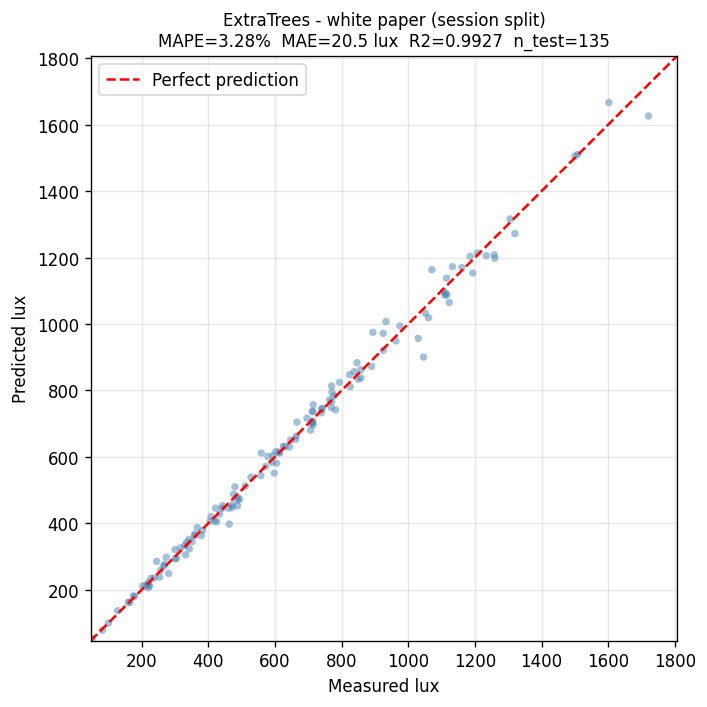


SECTION 3 — XGBoost (294 features, log-space regression)
  XGBoost                       | white_paper          | split=session              | MAPE=  3.45%  MAE=  21.8  R2=0.9915  [train=538, test=135]
  XGBoost                 (log) | white_paper          | split=session              | MAPE=  3.42%  MAE=  21.1  R2=0.9929  [train=538, test=135]
  XGBoost                       | white_paper          | split=physical_point_id    | MAPE=  4.84%  MAE=  35.5  R2=0.9838  [train=520, test=153]
  XGBoost                 (log) | white_paper          | split=physical_point_id    | MAPE=  4.59%  MAE=  31.9  R2=0.9862  [train=520, test=153]
  XGBoost                       | table                | split=session              | MAPE=  8.19%  MAE=  48.4  R2=0.9662  [train=374, test=94]
  XGBoost                 (log) | table                | split=session              | MAPE=  7.01%  MAE=  41.9  R2=0.9778  [train=374, test=94]
  XGBoost                       | table                | split=physical_po

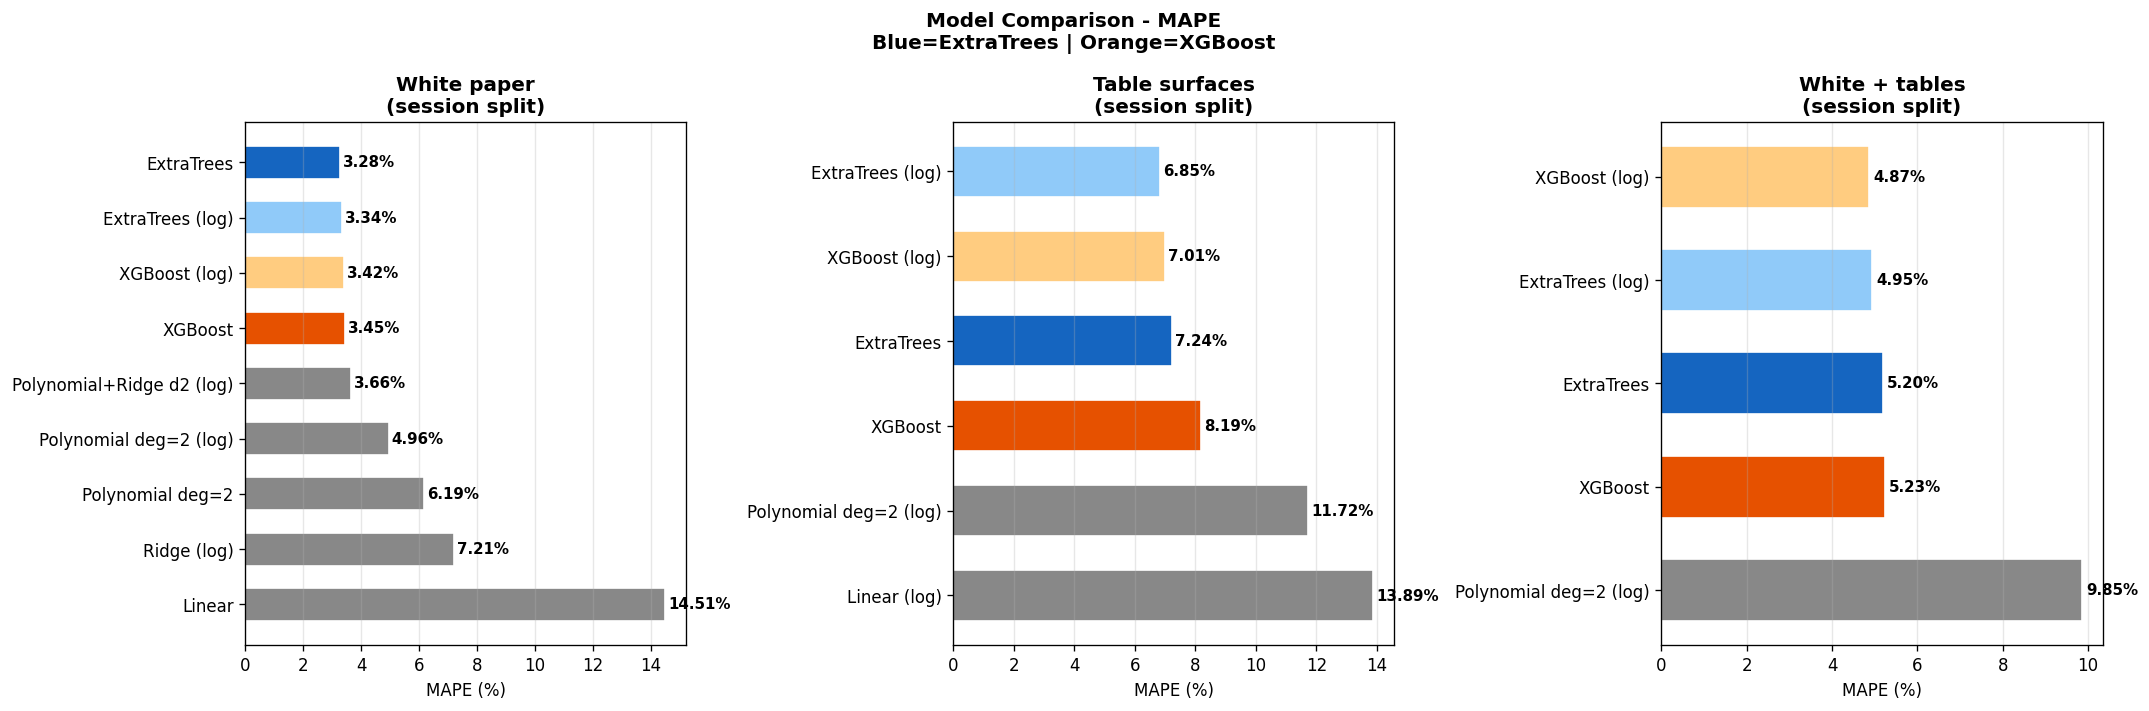


SECTION 5 - Threshold Classification (compliance screening)
  threshold= 200 lux | white_plus_tables    | split=physical_point_id    | AUC=0.9972  acc=0.9837  bal_acc=0.9107  [train=835, test=306]
  threshold= 200 lux | white_plus_tables    | split=session              | AUC=0.9996  acc=0.9956  bal_acc=0.9977  [train=912, test=229]
  threshold= 300 lux | white_plus_tables    | split=session              | AUC=0.9944  acc=0.9258  bal_acc=0.8433  [train=912, test=229]
  threshold= 500 lux | white_paper          | split=session              | AUC=1.0000  acc=0.9926  bal_acc=0.9911  [train=538, test=135]
  threshold= 500 lux | white_paper          | split=physical_point_id    | AUC=0.9996  acc=0.9804  bal_acc=0.9808  [train=520, test=153]

TABLE 4 - Classification results:
 threshold            subset             split    AUC  accuracy  balanced_accuracy  train_n  test_n
       200 white_plus_tables physical_point_id 0.9972    0.9837             0.9107      835     306
       200 white_pl

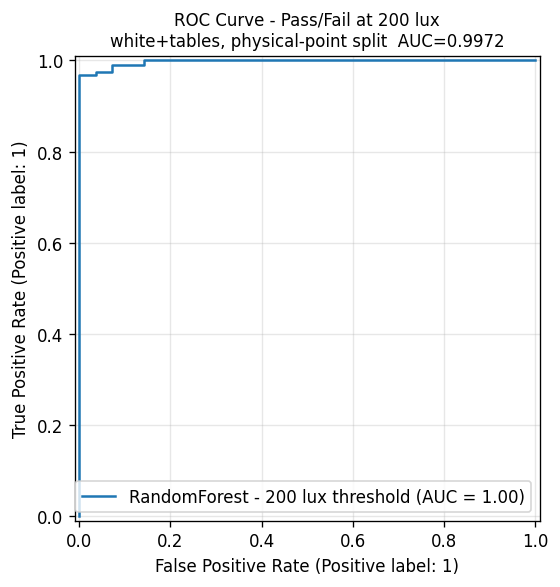


SECTION 6 - Feature importance + error by lux bin


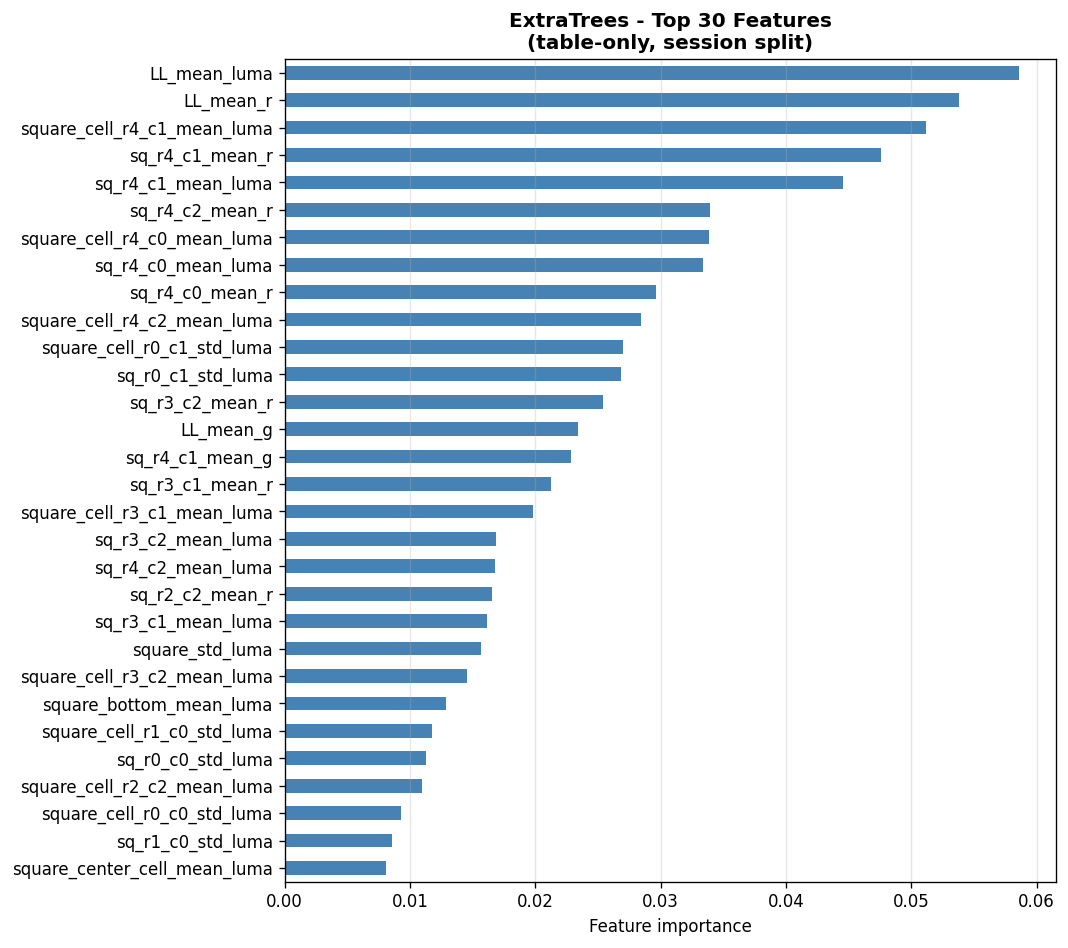

Top 10 features:
LL_mean_luma                   0.058610
LL_mean_r                      0.053783
square_cell_r4_c1_mean_luma    0.051191
sq_r4_c1_mean_r                0.047557
sq_r4_c1_mean_luma             0.044534
sq_r4_c2_mean_r                0.033955
square_cell_r4_c0_mean_luma    0.033855
sq_r4_c0_mean_luma             0.033391
sq_r4_c0_mean_r                0.029594
square_cell_r4_c2_mean_luma    0.028405

Error by lux bin:
           n   MAPE  median_APE
bin                            
<100       1  12.43       12.43
100-200    8   9.52        9.28
200-300   10   9.43        7.07
300-500   13  11.29        8.98
500-750   21   5.63        2.69
750-1000  18   5.72        4.81
>1000     23   4.02        3.46


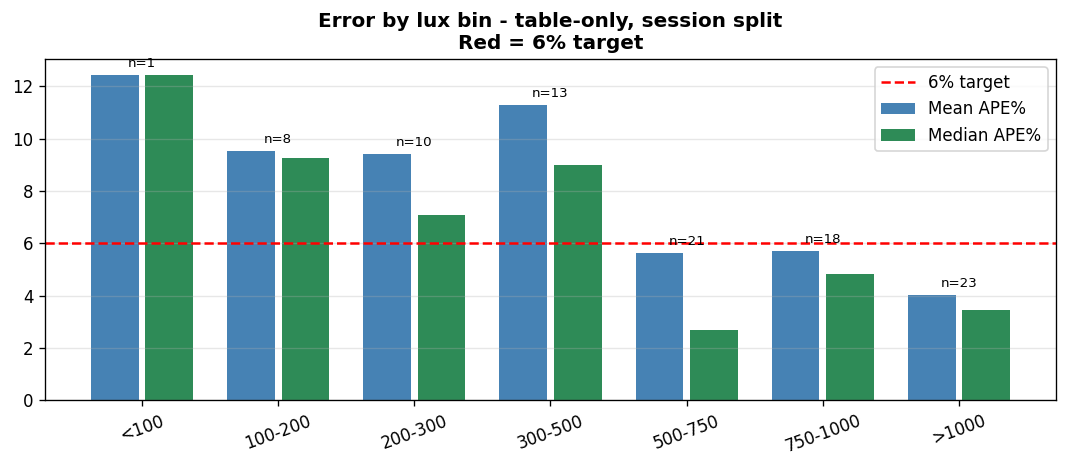


All results saved to: /content/drive/MyDrive/AI_Lux_Project/final_paper_results
  all_regression_results.csv  (2,588 bytes)
  classification_results.csv  (369 bytes)
  error_by_lux_bin.png  (53,385 bytes)
  feature_importance.png  (139,341 bytes)
  mape_comparison.png  (151,216 bytes)
  roc_200lux.png  (51,421 bytes)
  scatter_extratrees_white_paper.png  (81,026 bytes)


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  AI Lux Estimation — All Models Benchmark (single cell)                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','xgboost','--quiet'], capture_output=True)

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

from sklearn.ensemble       import ExtraTreesRegressor, RandomForestClassifier
from sklearn.linear_model   import LinearRegression, Ridge
from sklearn.preprocessing  import PolynomialFeatures, StandardScaler
from sklearn.pipeline       import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              roc_auc_score, accuracy_score, balanced_accuracy_score,
                              RocCurveDisplay)
import xgboost as xgb

# ── CONFIG ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = '/content/drive/MyDrive/AI_Lux_Project'
CSV_PATH = f'{PROJECT_ROOT}/Experiments_4/optionB_master_enriched37_with_pointid_grid5.csv'
SAVE_DIR = f'{PROJECT_ROOT}/final_paper_results'
os.makedirs(SAVE_DIR, exist_ok=True)

TARGET_COL  = 'target_lux'
SURFACE_COL = 'surface_group'
SESSION_COL = 'session'
POINT_COL   = 'physical_point_id'

# ── LOAD ───────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
print(f'Lux range: {df_raw[TARGET_COL].min():.0f}-{df_raw[TARGET_COL].max():.0f} '
      f'(mean={df_raw[TARGET_COL].mean():.0f}, SD={df_raw[TARGET_COL].std():.0f})')
print(f'Surface counts:\n{df_raw[SURFACE_COL].value_counts().to_string()}')

# ── FEATURE COLUMNS ────────────────────────────────────────────────────────────
EXCLUDE = {
    TARGET_COL, SURFACE_COL, SESSION_COL, POINT_COL,
    'image_path','filename','table_type','table_base','point',
    'surface','label_kind','surface_raw','surface_norm',
    'surface_group_norm','family_group','is_main_transfer_surface',
    'lux_C','lux_UL','lux_UR','lux_LR','lux_LL',
    'x_C','y_C','x_UL','y_UL','x_UR','y_UR','x_LR','y_LR','x_LL','y_LL',
}
ALL_FEATURES = [c for c in df_raw.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE]

COMPACT_LIST = [
    'square_mean_luma','square_mean_r','square_mean_g','square_mean_b',
    'square_right_minus_left_luma','square_bottom_minus_top_luma',
    'square_center_minus_corners_luma','square_std_luma','square_grad_mean',
    'C_mean_luma','C_mean_r','C_mean_g','C_mean_b',
    'C_minus_UL_luma','C_minus_UR_luma','C_minus_LR_luma','C_minus_LL_luma',
    'C_over_corner_mean_luma','corner_mean_luma','corner_std_luma',
]
COMPACT = [c for c in COMPACT_LIST if c in df_raw.columns]

print(f'All features: {len(ALL_FEATURES)} | Compact (regression baselines): {len(COMPACT)}')

# ── HELPERS ────────────────────────────────────────────────────────────────────
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    mask = y_true > 0
    return float(np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100)

def get_metrics(y_true, y_pred):
    return {'MAPE': round(mape(y_true, y_pred), 3),
            'MAE':  round(mean_absolute_error(y_true, y_pred), 2),
            'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
            'R2':   round(r2_score(y_true, y_pred), 4)}

def grouped_split(df, group_col, test_size=0.2, seed=42):
    spl = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    tr, te = next(spl.split(df, groups=df[group_col].values))
    return df.iloc[tr].copy(), df.iloc[te].copy()

def get_subset(df, subset):
    if subset == 'white_paper':        return df[df[SURFACE_COL]=='white_paper'].copy()
    if subset == 'table':              return df[df[SURFACE_COL]=='table'].copy()
    if subset == 'white_plus_tables':  return df[df[SURFACE_COL].isin(['white_paper','table'])].copy()
    return df.copy()

def prepare(df_sub, features, split_col, log=False):
    needed = [c for c in features+[TARGET_COL, split_col] if c in df_sub.columns]
    df_c = df_sub[needed].dropna()
    tr, te = grouped_split(df_c, split_col)
    X_tr, X_te = tr[features].values, te[features].values
    y_tr, y_te = tr[TARGET_COL].values, te[TARGET_COL].values
    y_fit = np.log1p(np.clip(y_tr, 1e-3, None)) if log else y_tr
    return X_tr, X_te, y_tr, y_te, y_fit, tr, te

def pprint(name, subset, split, m, tr, te, log=False):
    tag = '(log)' if log else '     '
    print(f'  {name:<24}{tag} | {subset:<20} | split={split:<20} | '
          f'MAPE={m["MAPE"]:6.2f}%  MAE={m["MAE"]:6.1f}  '
          f'R2={m["R2"]:.4f}  [train={len(tr)}, test={len(te)}]')

all_results = []

ET_CONFIGS = [
    ('white_paper','session',False),        ('white_paper','session',True),
    ('white_paper','physical_point_id',False), ('white_paper','physical_point_id',True),
    ('table','session',False),              ('table','session',True),
    ('table','physical_point_id',False),    ('table','physical_point_id',True),
    ('white_plus_tables','session',False),  ('white_plus_tables','session',True),
    ('white_plus_tables','physical_point_id',False), ('white_plus_tables','physical_point_id',True),
]

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — BASELINE REGRESSION
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*90)
print('SECTION 1 — Baseline Regression (Linear, Polynomial deg=2, Ridge)')
print('='*90)

BASELINE_CONFIGS = [
    ('Linear',             1, False, 'white_paper',       'session'),
    ('Polynomial deg=2',   2, False, 'white_paper',       'session'),
    ('Polynomial deg=2',   2, True,  'white_paper',       'session'),
    ('Polynomial deg=2',   2, True,  'white_paper',       'physical_point_id'),
    ('Ridge',              1, True,  'white_paper',       'session'),
    ('Polynomial+Ridge d2',2, True,  'white_paper',       'session'),
    ('Linear',             1, True,  'table',             'session'),
    ('Polynomial deg=2',   2, True,  'table',             'session'),
    ('Polynomial deg=2',   2, True,  'white_plus_tables', 'session'),
]

for name, degree, log, subset, split in BASELINE_CONFIGS:
    df_sub = get_subset(df_raw, subset)
    sc = SESSION_COL if split=='session' else POINT_COL
    X_tr,X_te,y_tr,y_te,y_fit,tr,te = prepare(df_sub, COMPACT, sc, log)
    steps = [('scaler', StandardScaler())]
    if degree > 1:
        steps.append(('poly', PolynomialFeatures(degree=degree, include_bias=False)))
    steps.append(('reg', Ridge(alpha=1.0) if 'Ridge' in name else LinearRegression()))
    model = Pipeline(steps)
    model.fit(X_tr, y_fit)
    y_pred = np.clip(np.expm1(model.predict(X_te)) if log else model.predict(X_te), 0, None)
    m = get_metrics(y_te, y_pred)
    pprint(name, subset, split, m, tr, te, log)
    all_results.append({'model':name,'subset':subset,'split':split,'log_space':log,
                        'n_features':len(COMPACT),'train_n':len(tr),'test_n':len(te),**m})

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — EXTRATREES
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*90)
print('SECTION 2 — ExtraTrees (294 features, log-space regression)')
print('='*90)

for subset, split, log in ET_CONFIGS:
    df_sub = get_subset(df_raw, subset)
    sc = SESSION_COL if split=='session' else POINT_COL
    if df_sub[sc].nunique() < 4: continue
    X_tr,X_te,y_tr,y_te,y_fit,tr,te = prepare(df_sub, ALL_FEATURES, sc, log)
    model = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(X_tr, y_fit)
    y_pred = np.expm1(model.predict(X_te)) if log else model.predict(X_te)
    m = get_metrics(y_te, y_pred)
    pprint('ExtraTrees', subset, split, m, tr, te, log)
    all_results.append({'model':'ExtraTrees','subset':subset,'split':split,'log_space':log,
                        'n_features':len(ALL_FEATURES),'train_n':len(tr),'test_n':len(te),**m})

# Scatter plot — best result
df_sub = get_subset(df_raw, 'white_paper')
X_tr,X_te,y_tr,y_te,y_fit,tr,te = prepare(df_sub, ALL_FEATURES, SESSION_COL, log=False)
et_plot = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)
et_plot.fit(X_tr, y_fit)
y_pred_plot = et_plot.predict(X_te)
m_plot = get_metrics(y_te, y_pred_plot)
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(y_te, y_pred_plot, alpha=0.5, s=20, color='steelblue', edgecolors='none')
lims = [min(y_te.min(),y_pred_plot.min())*0.9, max(y_te.max(),y_pred_plot.max())*1.05]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Measured lux'); ax.set_ylabel('Predicted lux')
ax.set_title(f'ExtraTrees - white paper (session split)\n'
             f'MAPE={m_plot["MAPE"]:.2f}%  MAE={m_plot["MAE"]:.1f} lux  '
             f'R2={m_plot["R2"]:.4f}  n_test={len(y_te)}', fontsize=10)
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/scatter_extratrees_white_paper.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — XGBOOST
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*90)
print('SECTION 3 — XGBoost (294 features, log-space regression)')
print('='*90)

XGB_PARAMS = dict(n_estimators=500, learning_rate=0.05, max_depth=6,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                  reg_lambda=0.1, random_state=42, n_jobs=-1, verbosity=0)

for subset, split, log in ET_CONFIGS:
    df_sub = get_subset(df_raw, subset)
    sc = SESSION_COL if split=='session' else POINT_COL
    if df_sub[sc].nunique() < 4: continue
    X_tr,X_te,y_tr,y_te,y_fit,tr,te = prepare(df_sub, ALL_FEATURES, sc, log)
    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_tr, y_fit)
    y_pred = np.expm1(model.predict(X_te)) if log else model.predict(X_te)
    m = get_metrics(y_te, y_pred)
    pprint('XGBoost', subset, split, m, tr, te, log)
    all_results.append({'model':'XGBoost','subset':subset,'split':split,'log_space':log,
                        'n_features':len(ALL_FEATURES),'train_n':len(tr),'test_n':len(te),**m})

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — SUMMARY TABLES
# ══════════════════════════════════════════════════════════════════════════════
results_df = pd.DataFrame(all_results)
COLS = ['subset','split','model','log_space','MAPE','MAE','R2','train_n','test_n']

for sname, title in [
    ('white_paper',        'TABLE 1 - White paper surfaces'),
    ('table',              'TABLE 2 - Table surfaces'),
    ('white_plus_tables',  'TABLE 3 - White + table surfaces'),
]:
    print(f'\n{"="*90}\n{title}\n{"="*90}')
    print(results_df[results_df['subset']==sname].sort_values(['split','MAPE'])[COLS].to_string(index=False))

print(f'\n{"="*90}\nBEST MODEL PER SUBSET + SPLIT\n{"="*90}')
best = results_df.loc[results_df.groupby(['subset','split'])['MAPE'].idxmin()]
print(best[COLS].sort_values(['subset','split']).to_string(index=False))

# Bar chart
focus = results_df[results_df['split']=='session'].copy()
focus['label'] = focus['model'] + focus['log_space'].map({True:' (log)', False:''})
COLORS = {'ExtraTrees':'#1565C0','ExtraTrees (log)':'#90CAF9',
          'XGBoost':'#E65100','XGBoost (log)':'#FFCC80'}
fig, axes = plt.subplots(1, 3, figsize=(18,6))
for ax, (sname, stitle) in zip(axes, [('white_paper','White paper'),
                                       ('table','Table surfaces'),
                                       ('white_plus_tables','White + tables')]):
    sub = focus[focus['subset']==sname].sort_values('MAPE')
    bars = ax.barh(sub['label'], sub['MAPE'],
                   color=[COLORS.get(l,'#888') for l in sub['label']],
                   edgecolor='white', height=0.6)
    for bar, val in zip(bars, sub['MAPE']):
        ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('MAPE (%)'); ax.set_title(f'{stitle}\n(session split)', fontweight='bold')
    ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
plt.suptitle('Model Comparison - MAPE\nBlue=ExtraTrees | Orange=XGBoost',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/mape_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — THRESHOLD CLASSIFICATION
# ══════════════════════════════════════════════════════════════════════════════
print(f'\n{"="*90}')
print('SECTION 5 - Threshold Classification (compliance screening)')
print(f'{"="*90}')

clf_results = []
for threshold, subset, split in [
    (200, 'white_plus_tables', 'physical_point_id'),
    (200, 'white_plus_tables', 'session'),
    (300, 'white_plus_tables', 'session'),
    (500, 'white_paper',       'session'),
    (500, 'white_paper',       'physical_point_id'),
]:
    df_sub = get_subset(df_raw, subset).copy()
    sc = SESSION_COL if split=='session' else POINT_COL
    df_sub['label'] = (df_sub[TARGET_COL] >= threshold).astype(int)
    needed = [c for c in ALL_FEATURES+['label', sc] if c in df_sub.columns]
    df_c = df_sub[needed].dropna()
    tr, te = grouped_split(df_c, sc)
    feat = [c for c in ALL_FEATURES if c in tr.columns]
    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
    clf.fit(tr[feat].values, tr['label'].values)
    y_proba = clf.predict_proba(te[feat].values)[:,1]
    y_te_c  = te['label'].values
    auc  = roc_auc_score(y_te_c, y_proba)
    acc  = accuracy_score(y_te_c, (y_proba>=0.5).astype(int))
    bacc = balanced_accuracy_score(y_te_c, (y_proba>=0.5).astype(int))
    print(f'  threshold={threshold:4d} lux | {subset:<20} | split={split:<20} | '
          f'AUC={auc:.4f}  acc={acc:.4f}  bal_acc={bacc:.4f}  '
          f'[train={len(tr)}, test={len(te)}]')
    clf_results.append({'threshold':threshold,'subset':subset,'split':split,
                        'AUC':round(auc,4),'accuracy':round(acc,4),
                        'balanced_accuracy':round(bacc,4),'train_n':len(tr),'test_n':len(te)})

clf_df = pd.DataFrame(clf_results)
print('\nTABLE 4 - Classification results:')
print(clf_df.to_string(index=False))

# ROC curve for main result
df_sub = get_subset(df_raw, 'white_plus_tables').copy()
df_sub['label'] = (df_sub[TARGET_COL] >= 200).astype(int)
needed = [c for c in ALL_FEATURES+['label', POINT_COL] if c in df_sub.columns]
df_c = df_sub[needed].dropna()
tr, te = grouped_split(df_c, POINT_COL)
feat = [c for c in ALL_FEATURES if c in tr.columns]
clf_roc = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
clf_roc.fit(tr[feat].values, tr['label'].values)
y_proba_roc = clf_roc.predict_proba(te[feat].values)[:,1]
fig, ax = plt.subplots(figsize=(5,5))
RocCurveDisplay.from_predictions(te['label'].values, y_proba_roc,
    name='RandomForest - 200 lux threshold', ax=ax)
auc_val = roc_auc_score(te['label'].values, y_proba_roc)
ax.set_title(f'ROC Curve - Pass/Fail at 200 lux\nwhite+tables, physical-point split  '
             f'AUC={auc_val:.4f}', fontsize=10)
ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_200lux.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — FEATURE IMPORTANCE + ERROR BY LUX BIN
# ══════════════════════════════════════════════════════════════════════════════
print(f'\n{"="*90}')
print('SECTION 6 - Feature importance + error by lux bin')
print(f'{"="*90}')

df_sub = get_subset(df_raw, 'table')
X_tr,X_te,y_tr,y_te,y_fit,tr,te = prepare(df_sub, ALL_FEATURES, SESSION_COL, log=True)
et_fi = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)
et_fi.fit(X_tr, y_fit)
y_pred_fi = np.expm1(et_fi.predict(X_te))

imp = pd.Series(et_fi.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,8))
imp.head(30).plot.barh(ax=ax, color='steelblue')
ax.invert_yaxis(); ax.set_xlabel('Feature importance')
ax.set_title('ExtraTrees - Top 30 Features\n(table-only, session split)', fontweight='bold')
ax.grid(axis='x', alpha=0.3); plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 10 features:')
print(imp.head(10).to_string())

# Error by lux bin
bins   = [0,100,200,300,500,750,1000,9999]
labels = ['<100','100-200','200-300','300-500','500-750','750-1000','>1000']
bin_idx = np.clip(np.digitize(y_te, bins)-1, 0, len(labels)-1)
ape = np.abs((y_te - y_pred_fi) / np.clip(y_te, 1e-6, None)) * 100
bin_df = pd.DataFrame({'bin':[labels[i] for i in bin_idx], 'ape':ape})
bin_stats = bin_df.groupby('bin', sort=False).agg(
    n=('ape','count'), MAPE=('ape','mean'), median_APE=('ape','median')
).reindex(labels).dropna().round(2)
print('\nError by lux bin:')
print(bin_stats.to_string())
x = np.arange(len(bin_stats))
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(x-0.2, bin_stats['MAPE'],      0.35, label='Mean APE%',   color='steelblue')
ax.bar(x+0.2, bin_stats['median_APE'],0.35, label='Median APE%', color='seagreen')
ax.axhline(6, color='red', ls='--', lw=1.5, label='6% target')
ax.set_xticks(x); ax.set_xticklabels(bin_stats.index, rotation=20)
ax.set_title('Error by lux bin - table-only, session split\nRed = 6% target', fontweight='bold')
for xi, (_, row) in zip(x, bin_stats.iterrows()):
    ax.text(xi, max(row.MAPE, row.median_APE)+0.3, f'n={int(row.n)}', ha='center', fontsize=8)
ax.legend(); ax.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/error_by_lux_bin.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SAVE ALL RESULTS ──────────────────────────────────────────────────────────
results_df.to_csv(f'{SAVE_DIR}/all_regression_results.csv', index=False)
clf_df.to_csv(f'{SAVE_DIR}/classification_results.csv', index=False)

print(f'\nAll results saved to: {SAVE_DIR}')
for f in sorted(os.listdir(SAVE_DIR)):
    print(f'  {f}  ({os.path.getsize(f"{SAVE_DIR}/{f}"):,} bytes)')

Error by lux bin — WHITE PAPER (ExtraTrees, session split):
           n  MAPE  median_APE
bin                           
<100       2  4.02        4.02
100-200    6  2.50        1.65
200-300   15  4.64        2.95
300-500   33  3.77        3.08
500-750   32  2.33        1.60
750-1000  22  3.02        2.31
>1000     25  3.40        2.54


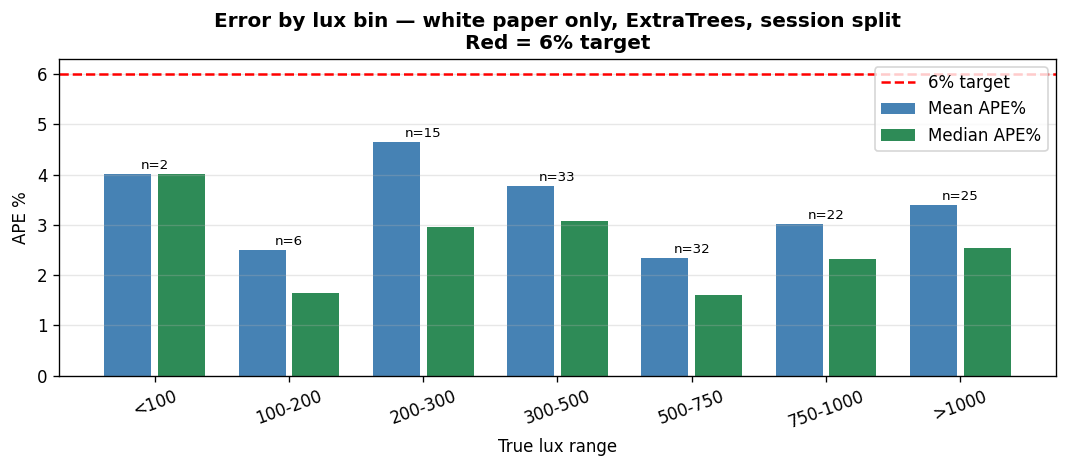

In [4]:
# Error by lux bin — white paper (ExtraTrees, session split, no log)
df_sub = get_subset(df_raw, 'white_paper')
X_tr, X_te, y_tr, y_te, y_fit, tr, te = prepare(df_sub, ALL_FEATURES, SESSION_COL, log=False)
et_wp = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)
et_wp.fit(X_tr, y_fit)
y_pred_wp = et_wp.predict(X_te)

bins   = [0, 100, 200, 300, 500, 750, 1000, 9999]
labels = ['<100', '100-200', '200-300', '300-500', '500-750', '750-1000', '>1000']
bin_idx = np.clip(np.digitize(y_te, bins) - 1, 0, len(labels) - 1)
ape = np.abs((y_te - y_pred_wp) / np.clip(y_te, 1e-6, None)) * 100

bin_df_wp = pd.DataFrame({'bin': [labels[i] for i in bin_idx], 'ape': ape})
bin_stats_wp = bin_df_wp.groupby('bin', sort=False).agg(
    n=('ape','count'), MAPE=('ape','mean'), median_APE=('ape','median')
).reindex(labels).dropna().round(2)

print('Error by lux bin — WHITE PAPER (ExtraTrees, session split):')
print(bin_stats_wp.to_string())

x = np.arange(len(bin_stats_wp))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, bin_stats_wp['MAPE'],       0.35, label='Mean APE%',   color='steelblue')
ax.bar(x + 0.2, bin_stats_wp['median_APE'], 0.35, label='Median APE%', color='seagreen')
ax.axhline(6, color='red', ls='--', lw=1.5, label='6% target')
ax.set_xticks(x); ax.set_xticklabels(bin_stats_wp.index, rotation=20)
ax.set_xlabel('True lux range'); ax.set_ylabel('APE %')
ax.set_title('Error by lux bin — white paper only, ExtraTrees, session split\n'
             'Red = 6% target', fontweight='bold')
for xi, (_, row) in zip(x, bin_stats_wp.iterrows()):
    ax.text(xi, max(row.MAPE, row.median_APE) + 0.1,
            f'n={int(row.n)}', ha='center', fontsize=8)
ax.legend(); ax.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/error_by_lux_bin_white_paper.png', dpi=150, bbox_inches='tight')
plt.show()

Per surface group — MAPE by bin:

  white_paper (n=130):
           n   MAPE  median_APE
bin                            
<100       3  18.83       18.87
100-200    5   8.46        7.20
200-300   19   6.10        4.07
300-500   26   8.36        5.48
500-750   30   3.44        2.35
750-1000  19   3.63        2.47
>1000     28   3.37        2.65

  colored_paper (n=318):
              n   MAPE  median_APE
bin                               
300-500   111.0  13.06        9.47
500-750   117.0  11.68        6.47
750-1000   45.0   7.26        6.86
>1000      45.0  22.97       18.83

  table (n=94):
           n   MAPE  median_APE
bin                            
<100       3  25.93       25.14
100-200    3  16.52       21.19
200-300   15  10.18        7.53
300-500   18   9.65        6.21
500-750   20   6.56        5.03
750-1000  10  12.95        7.93
>1000     25   7.77        4.19

  other (n=138):
             n   MAPE  median_APE
bin                              
200-300    1.0  25.79       

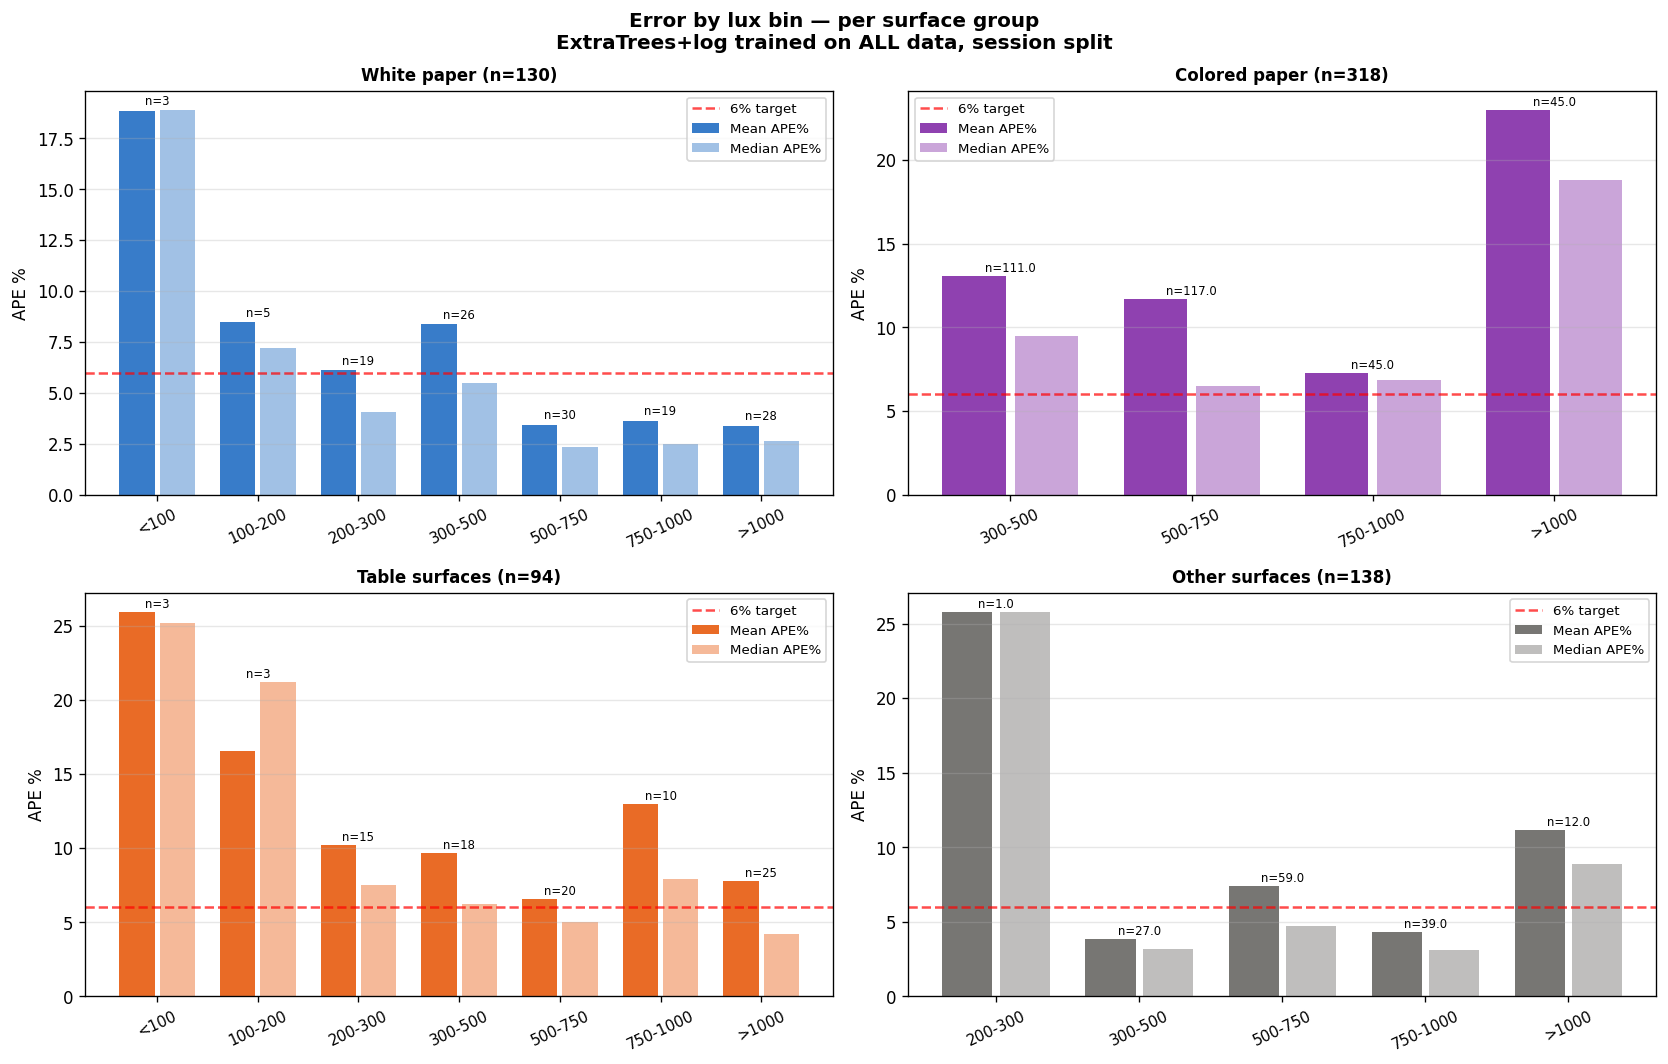

Saved → /content/drive/MyDrive/AI_Lux_Project/final_paper_results/error_by_lux_bin_all_surfaces.png


In [7]:
# Per surface group — FIXED: keep surface_group in the split
needed_with_surf = [c for c in ALL_FEATURES + [TARGET_COL, SESSION_COL, SURFACE_COL]
                    if c in df_raw.columns]
df_c2 = df_raw[needed_with_surf].dropna()
tr2, te2 = grouped_split(df_c2, SESSION_COL)

# Train same model
et_all2 = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)
et_all2.fit(tr2[ALL_FEATURES].values, np.log1p(tr2[TARGET_COL].values))

te2 = te2.reset_index(drop=True)
te2['y_pred'] = np.expm1(et_all2.predict(te2[ALL_FEATURES].values))

print('Per surface group — MAPE by bin:')
for surf in ['white_paper', 'colored_paper', 'table', 'other']:
    sub = te2[te2[SURFACE_COL] == surf]
    if len(sub) < 5:
        print(f'\n  {surf}: too few samples (n={len(sub)})')
        continue
    s = bin_stats(sub[TARGET_COL].values, sub['y_pred'].values)
    print(f'\n  {surf} (n={len(sub)}):')
    print(s[['n','MAPE','median_APE']].to_string())

# 2×2 plot
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

surface_groups = ['white_paper', 'colored_paper', 'table', 'other']
titles  = ['White paper', 'Colored paper', 'Table surfaces', 'Other surfaces']
colors  = ['#1565C0', '#7B1FA2', '#E65100', '#5F5E5A']

for ax, surf, title, color in zip(axes, surface_groups, titles, colors):
    sub = te2[te2[SURFACE_COL] == surf]
    if len(sub) < 5:
        ax.text(0.5, 0.5, f'n={len(sub)}\n(too few)',
                ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.set_title(title, fontweight='bold', fontsize=10)
        continue
    s = bin_stats(sub[TARGET_COL].values, sub['y_pred'].values)
    x = np.arange(len(s))
    ax.bar(x - 0.2, s['MAPE'],       0.35, label='Mean APE%',   color=color, alpha=0.85)
    ax.bar(x + 0.2, s['median_APE'], 0.35, label='Median APE%', color=color, alpha=0.4)
    ax.axhline(6, color='red', ls='--', lw=1.5, alpha=0.7, label='6% target')
    ax.set_xticks(x)
    ax.set_xticklabels(s.index, rotation=25, fontsize=9)
    ax.set_ylabel('APE %')
    ax.set_title(f'{title} (n={len(sub)})', fontweight='bold', fontsize=10)
    for xi, row in zip(x, s.itertuples()):
        ax.text(xi, max(row.MAPE, row.median_APE) + 0.3,
                f'n={row.n}', ha='center', fontsize=7)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Error by lux bin — per surface group\n'
             'ExtraTrees+log trained on ALL data, session split',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/error_by_lux_bin_all_surfaces.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {SAVE_DIR}/error_by_lux_bin_all_surfaces.png')